<a href="https://colab.research.google.com/github/NatP-dev/Complete-Python-3-Bootcamp/blob/master/Welcome_to_Colaboratory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Can Machine Learning Improve Portfolio Optimization for Cryptocurrencies?**

## **Author**: Nathalia Pouroullis
## **Student Number**: 18050
## **Date**: 30 March 2025

Cryptocurrency markets are known for their high volatility, non-stationary behavior, and complex correlation structures. Traditional portfolio optimization techniques, such as Modern Portfolio Theory (MPT), fail to capture the non-linear dependencies and extreme price fluctuations characteristic of digital assets.

Machine learning (ML) offers an opportunity to enhance portfolio allocation strategies by leveraging historical patterns, advanced risk modeling, and adaptive decision-making frameworks. This study evaluates whether ML-driven portfolio optimization techniques can outperform traditional methods in the cryptocurrency domain, potentially offering better risk-adjusted returns and more robust portfolio management.

# **Table of Contents**


*   Chapter 1: Introduction
*   Chapter 2: Data



---
---
# **Chapter 1: Introduction**  
Cryptocurrencies have emerged as a highly volatile and complex class of assets, marked by their non-stationary behavior and intricate correlations between different assets. Traditional portfolio optimization methods, such as Modern Portfolio Theory (MPT), rely on the assumption of normal distribution of returns and fail to account for the non-linear dependencies and extreme price fluctuations seen in cryptocurrency markets. This makes it difficult to apply conventional financial models effectively for cryptocurrency portfolio management.

This study aims to explore the use of machine learning (ML) techniques to optimize portfolio allocation in the cryptocurrency market, focusing on risk-adjusted returns. Specifically, the objective is to evaluate whether ML models can outperform traditional portfolio optimization methods, particularly in terms of Sharpe ratio, Sortino ratio, and maximum drawdown. By comparing ML-based portfolio allocation with the conventional Markowitz model, this analysis provides insights into the potential benefits of integrating machine learning into cryptocurrency portfolio management.

## **0 - Imports**



In [82]:
################################ LIBRARIES ########################
# Necessary libraries
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import yfinance as yf
import re
import time
import math

# Statistical and Optimization Libraries
from scipy.stats import norm, zscore, skew, kurtosis, median_abs_deviation
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, leaves_list

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import confusion_matrix, classification_report

# Deep Learning Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Date Handling
import matplotlib.dates as mdates

# Additional Machine Learning Libraries
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Plotly Library
import plotly.express as px

---
---
# **Chapter 2: Data**
This study utilizes data from Yahoo Finance, a widely recognized and reliable provider of financial market data. Yahoo Finance aggregates pricing information from multiple exchanges which maintains accuracy, consistency and historical depth. The dataset includes adjusted closing prices and trading volumes, which are essential for financial modeling, volatility analysis and portfolio optimization.
<br>
### **Time Frame and Coverage**
The dataset spans five years (March 1, 2020 – March 1, 2025), with daily observations. This period ensures coverage of both bull and bear market phases, allowing for a comprehensive evaluation of portfolio risk, asset correlations, and return performance under varying market conditions.
<br>
### **Cryptocurrency Selection Criteria**
The selected cryptocurrencies were chosen based on market capitalization, liquidity, and portfolio diversification potential. These assets represent different sectors within the cryptocurrency space, ensuring a broad risk-return profile:

- **Bitcoin (BTC)**: Store of value, benchmark asset.
- **Ethereum (ETH)**: Smart contract leader, high utility.
- **Binance Coin (BNB)**: Exchange token with strong adoption.
- **Cardano (ADA), Polygon (MATIC), Chainlink (LINK)**: Blockchain scalability and DeFi applications.
- **XRP (Ripple), Dogecoin (DOGE), Litecoin (LTC)**: Alternative payment networks with market relevance.

<br>
### **Summary of Cryptocurrencies**
| Cryptocurrency | Category               | Market Cap | Volatility |
|----------------|------------------------|------------|------------|
| Bitcoin (BTC)  | Store of Value         | High       | Medium     |
| Ethereum (ETH) | Smart Contracts        | High       | Medium     |
| Binance Coin (BNB) | Exchange Token      | Medium     | Low        |
| Cardano (ADA)  | Proof-of-Stake         | Medium     | Medium     |
| XRP (Ripple)   | Payments Network       | High       | Low        |
| Dogecoin (DOGE)| Meme Coin              | Medium     | High       |
| Chainlink (LINK)| Decentralized Oracles | Medium     | High       |
| Polygon (MATIC)| Layer-2 Scaling        | Medium     | High       |

<br>

### **Data Fields and Integrity**
Each cryptocurrency record contains:
- **Closing Price (Close)**: The final traded price each day, essential for return calculations.
- **Trading Volume (Volume)**: Total units traded, serving as a liquidity and market sentiment indicator.

In [84]:
################################ DATA IMPORT ########################
# Define the list of cryptocurrencies
crypto_list = [
    'BTC-USD', 'ETH-USD', 'BNB-USD', 'ADA-USD', 'XRP-USD',
    'DOGE-USD', 'LINK-USD', 'MATIC-USD', 'LTC-USD'
]

# Set a fixed end date for reproducibility
end_date = "2025-03-01"

historical_data = {}

for crypto in crypto_list:
    print(f"- Fetching data for {crypto} up to {end_date}...")
    df = yf.download(crypto, start="2020-03-01", end=end_date, interval="1d")  # 5 years of daily data
    df = df[['Close', 'Volume']]  # Keep only relevant columns
    df.columns = [f"{crypto}_Close", f"{crypto}_Volume"]
    historical_data[crypto] = df

# Merge all data
final_df = pd.concat(historical_data.values(), axis=1)

# Save to CSV
final_df.to_csv("crypto_fixed_data.csv", index=True)
print(" Data saved as 'crypto_fixed_data.csv'")

# Check the number of days in the dataset
num_days = len(final_df)
print(f"- Number of days in dataset: {num_days}")


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

- Fetching data for BTC-USD up to 2025-03-01...
- Fetching data for ETH-USD up to 2025-03-01...
- Fetching data for BNB-USD up to 2025-03-01...
- Fetching data for ADA-USD up to 2025-03-01...
- Fetching data for XRP-USD up to 2025-03-01...
- Fetching data for DOGE-USD up to 2025-03-01...



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


- Fetching data for LINK-USD up to 2025-03-01...
- Fetching data for MATIC-USD up to 2025-03-01...
- Fetching data for LTC-USD up to 2025-03-01...
 Data saved as 'crypto_fixed_data.csv'
- Number of days in dataset: 1826


## **2.1 - Data Pre-processing**
The data cleaning process involved several key steps to ensure the accuracy and integrity of the cryptocurrency dataset. Initially, basic checks were performed to assess the dataset’s structure, confirming that all columns contain the expected data types and non-null values. For cryptocurrencies with missing data, forward-filling was applied starting from their first valid data point, ensuring no artificial distortions.
<br><br>
To handle missing values, the first available date for each cryptocurrency was identified. Missing values from that point onward were forward-filled. This process was essential to maintain consistency across the dataset while ensuring that newer cryptocurrencies, which might have incomplete data at the start of the period, were treated correctly.
<br><br>
An outlier analysis was also conducted using both the Interquartile Range (IQR) and Z-Score methods. These techniques helped identify extreme values, including price spikes or abnormal market behavior, which could distort the analysis. The findings were summarized in an outlier table and visualized through dynamic plots.
<br><br>
The final cleaned dataset has no missing values after the forward-fill operation, ensuring the reliability of the model inputs.

### ***2.1.1 - Data Cleaning***

In [3]:
############################### DATA CLEANING ###############################
################################ BASIC CHECKS ########################
# Display basic info
print("\n - Dataset Info:")
print(final_df.info())

################################ MIN DATE PER CRYPTO (Without NaN) ########################
# Get the first available date where each crypto has actual data (not NaN)
min_dates = final_df.apply(lambda col: col.first_valid_index())

print("\n- Minimum Start Date for Each Crypto (Excluding NaN values):")
print(min_dates)

############################### MISSING DATA COUNT FROM EARLIEST START DATE #############################
# Count missing values FROM each crypto's earliest start date (not before)
missing_counts = {}

for col in final_df.columns:
    start_date = min_dates[col]  # Get the first valid date for the crypto
    if pd.notna(start_date):  # Ensure we have a valid start date
        missing_counts[col] = final_df.loc[start_date:][col].isnull().sum()  # Count NaNs from min date onward

# Convert to DataFrame for better readability
missing_df = pd.DataFrame.from_dict(missing_counts, orient='index', columns=['Missing Values'])

print("\n⚠ Missing Values Count from Each Crypto's Start Date (Excluding NaN at Start):")
print(missing_df)

############################## FORWARD FILL (ONLY AFTER START DATE) ##############################
# Apply forward fill only after the crypto's start date
for col in final_df.columns:
    start_date = min_dates[col]
    if pd.notna(start_date):  # Ensure we have a valid start date (only where data exists is recognized as the first date)
        final_df.loc[start_date:, col] = final_df.loc[start_date:, col].ffill()

print("\n Missing values have been forward-filled only after each crypto's start date.")

# Verify missing values again
print("\n⚠ Missing Values Count After Forward Fill:")
print(final_df.isnull().sum())


 - Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1826 entries, 2020-03-01 to 2025-02-28
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   BTC-USD_Close     1826 non-null   float64
 1   BTC-USD_Volume    1826 non-null   int64  
 2   ETH-USD_Close     1826 non-null   float64
 3   ETH-USD_Volume    1826 non-null   int64  
 4   BNB-USD_Close     1826 non-null   float64
 5   BNB-USD_Volume    1826 non-null   int64  
 6   ADA-USD_Close     1826 non-null   float64
 7   ADA-USD_Volume    1826 non-null   int64  
 8   XRP-USD_Close     1826 non-null   float64
 9   XRP-USD_Volume    1826 non-null   int64  
 10  DOGE-USD_Close    1826 non-null   float64
 11  DOGE-USD_Volume   1826 non-null   int64  
 12  LINK-USD_Close    1826 non-null   float64
 13  LINK-USD_Volume   1826 non-null   int64  
 14  MATIC-USD_Close   1826 non-null   float64
 15  MATIC-USD_Volume  1826 non-null   int64  
 16  LTC-US

### ***2.1.2 - Outlier Analysis***

- Automatically detected feature groups: ['Close', 'Volume']


<ipython-input-4-587ba1e46b2a>:80: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




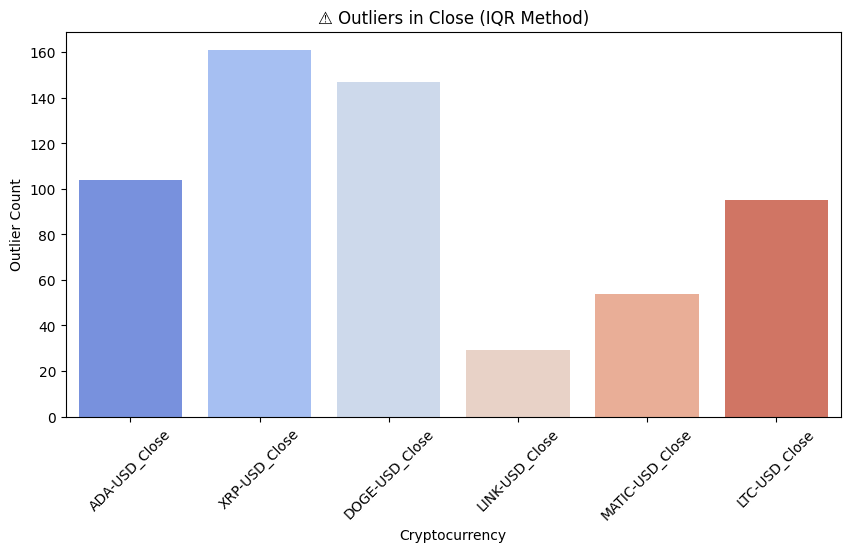

<ipython-input-4-587ba1e46b2a>:80: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




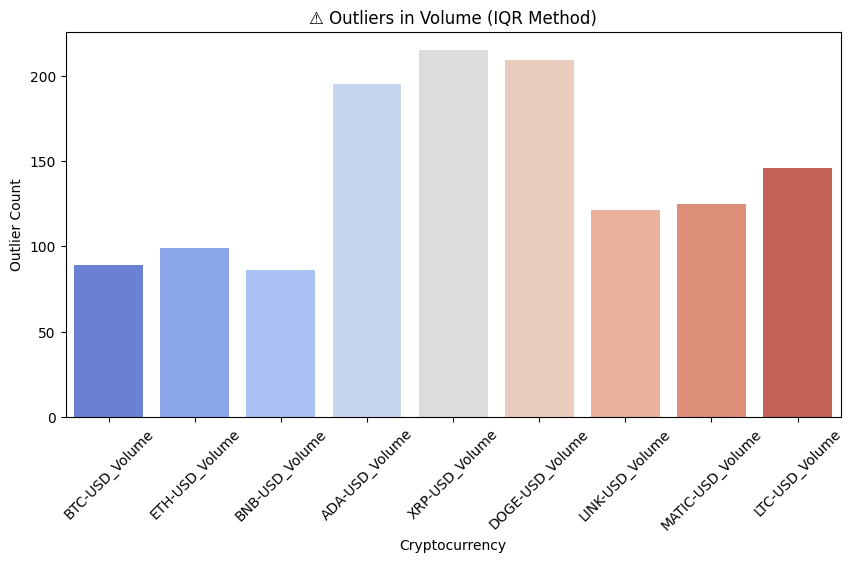

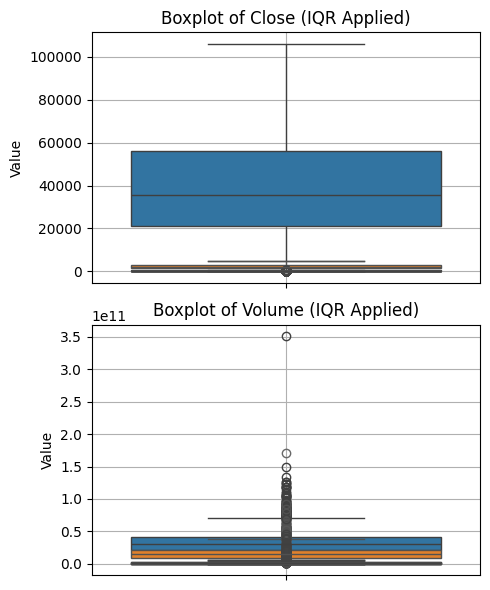

In [4]:
############################### OUTLIER ANALYSIS ###############################
############################### AUTO-DETECT FEATURE GROUPS ###############################

# Extract feature groups dynamically based on column names
feature_groups = {}
for col in final_df.columns:
    feature_type = col.split('_')[-1]  # Extracts 'Close', 'Market_Cap', 'Volume', etc.
    feature_groups.setdefault(feature_type, []).append(col)

print(f"- Automatically detected feature groups: {list(feature_groups.keys())}")

###############################  DYNAMIC GROUPED BOXPLOTS USING PLOTLY ###############################

for feature_type, columns in feature_groups.items():
    fig = go.Figure()
    for col in columns:
        fig.add_trace(go.Box(y=final_df[col].dropna(), name=col, boxmean=True, boxpoints='outliers'))

    fig.update_layout(title=f" {feature_type.replace('_', ' ')} Boxplot",
                      yaxis=dict(title=feature_type),
                      xaxis=dict(title="Cryptocurrency"))
    fig.show()

############################### AUTO-DETECT OUTLIERS (IQR Method) ###############################

outlier_counts = {}

for feature_type, columns in feature_groups.items():
    for col in columns:
        data = final_df[col].dropna()

        # Compute IQR
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find outliers
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        if not outliers.empty:
            outlier_counts[col] = len(outliers)

############################### AUTO-DETECT OUTLIERS (Z-SCORE Method) ###############################

z_score_outliers = {}

for feature_type, columns in feature_groups.items():
    for col in columns:
        data = final_df[col].dropna()
        z_scores = zscore(data)
        outliers = data[(z_scores > 3) | (z_scores < -3)]
        if not outliers.empty:
            z_score_outliers[col] = len(outliers)

###############################  OUTLIER SUMMARY TABLE ###############################
# Structure for summary table
fig_summary = go.Figure(data=[go.Table(
    header=dict(values=["Cryptocurrency", "Total Outliers (IQR)", "Total Outliers (Z-Score)"],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        list(outlier_counts.keys()),
        list(outlier_counts.values()),
        [z_score_outliers.get(col, 0) for col in outlier_counts.keys()]
    ],
               fill_color='lavender',
               align='left'))
])

fig_summary.update_layout(title_text="- Outlier Summary (IQR & Z-Score)")
fig_summary.show()

###############################  DYNAMIC OUTLIER HISTOGRAMS ###############################
# Define structure for histograms (outliers)
def plot_outlier_histogram(outlier_dict, feature_type):
    """Plots histogram of outliers for a specific feature type."""
    if outlier_dict:
        plt.figure(figsize=(10, 5))
        sns.barplot(x=list(outlier_dict.keys()), y=list(outlier_dict.values()), palette="coolwarm")
        plt.xticks(rotation=45)
        plt.title(f"⚠ Outliers in {feature_type} (IQR Method)")
        plt.xlabel("Cryptocurrency")
        plt.ylabel("Outlier Count")
        plt.show()

# Plot histograms dynamically for each feature group
for feature_type in feature_groups.keys():
    outlier_subset = {k: v for k, v in outlier_counts.items() if k.endswith(feature_type)}
    plot_outlier_histogram(outlier_subset, feature_type)

############################### DYNAMIC INDIVIDUAL CRYPTOCURRENCY BOXPLOTS ###############################
# Structure for boxplots
fig, axes = plt.subplots(nrows=len(feature_groups), ncols=1, figsize=(5, len(feature_groups) * 3))

for i, (feature_type, columns) in enumerate(feature_groups.items()):
    for col in columns:
        data = final_df[col].dropna()

        # Compute IQR for outlier detection
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find outliers
        outliers = data[(data < lower_bound) | (data > upper_bound)]

        # Plot boxplot
        sns.boxplot(y=data, ax=axes[i])
        axes[i].set_title(f"Boxplot of {feature_type} (IQR Applied)")
        axes[i].set_ylabel("Value")
        axes[i].grid(True)

plt.tight_layout()
plt.show()

**Outlier Analysis**
- **Outliers**: Assets like **ADA-USD_Close** and **DOGE-USD_Volume** showed significant outliers.
- **Visualization**: Boxplots and histograms highlight extreme values, particularly in the highly volatile assets such as **BTC-USD** and **XRP-USD**.
- **Handling**: No specific adjustments were made for outliers as extreme values reflect inherent market volatility.

These extreme values are relevant for the modeling process, as they indicate critical market movements.


---


### ***2.1.3 - Data Quality Checks***

- Automatically detected feature groups: ['Close', 'Volume']

- **Running Data Quality Checks Before Splitting...**



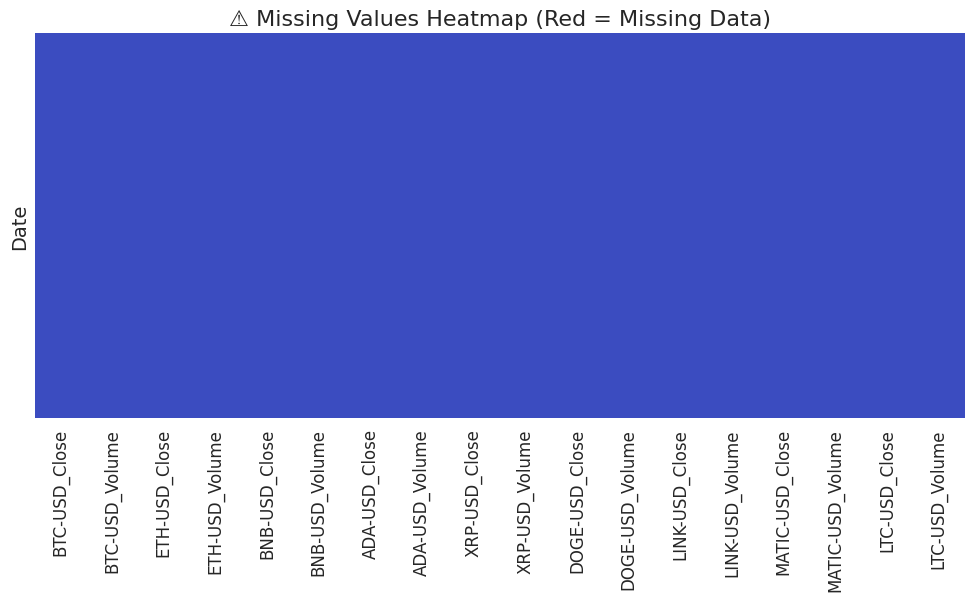


 **Data Quality Dashboard Complete! Ready for Feature Engineering.**



In [83]:
############################### DATA QUALITY CHECKS ###############################
############################### AUTO-DETECT FEATURE GROUPS ###############################

# Extract feature groups dynamically based on column names
feature_groups = {}
for col in final_df.columns:
    feature_type = col.split('_')[-1]  # Extracts 'Close', 'Market_Cap', 'Volume', etc.
    feature_groups.setdefault(feature_type, []).append(col)

print(f"- Automatically detected feature groups: {list(feature_groups.keys())}")

############################### DATA QUALITY CHECKS DASHBOARD ###############################
print("\n- **Running Data Quality Checks Before Splitting...**\n")

# Check for duplicate rows
duplicate_rows = final_df.duplicated().sum()

# Check for constant columns (cryptos that might have no variation)
constant_cols = [col for col in final_df.columns if final_df[col].nunique() == 1]

# Check for **negative/zero values** (applies to all detected feature groups)
negative_zero_counts = {
    col: (final_df[col] <= 0).sum()
    for feature, columns in feature_groups.items()
    for col in columns
    if (final_df[col] <= 0).sum() > 0
}

# Ensure the dataset index is **strictly** increasing in time
date_sorted = final_df.index.is_monotonic_increasing

# Check missing values after forward-filling
missing_after_fill = final_df.isnull().sum()
total_missing = missing_after_fill.sum()

# Dataset size
num_rows, num_cols = final_df.shape

############################### PRINT FULL ROWS WITH NEGATIVE OR ZERO VALUES ###############################
if negative_zero_counts:
    print("\n⚠ **Rows with Negative or Zero Values:**\n")
    for col in negative_zero_counts.keys():
        print(f" {col} has {negative_zero_counts[col]} negative or zero values:")
        display(final_df[final_df[col] <= 0][[col]])

############################### DISPLAY DATA QUALITY SUMMARY ###############################
fig_data_quality = go.Figure(data=[go.Table(
    header=dict(values=["Metric", "Value"],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        ["Duplicate Rows", "Constant Value Columns", "Columns with Negative/Zero Values",
         "Dates Sorted", "Total Missing Values", "Dataset Shape"],
        [duplicate_rows, len(constant_cols), len(negative_zero_counts),
         date_sorted, total_missing, f"{num_rows} rows, {num_cols} columns"]
    ],
    fill_color='lavender',
    align='left'))
])

fig_data_quality.update_layout(title_text="- Data Quality Summary")
fig_data_quality.show()

############################### VISUALIZATIONS FOR DATA QUALITY ISSUES ###############################

# Visualizing Missing Values (Heatmap)
plt.figure(figsize=(12, 5))
sns.heatmap(final_df.isnull(), cmap="coolwarm", cbar=False, yticklabels=False)
plt.title("⚠ Missing Values Heatmap (Red = Missing Data)")
plt.show()

# Visualizing **Negative/Zero Values** for All Feature Groups
if negative_zero_counts:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(negative_zero_counts.keys()), y=list(negative_zero_counts.values()), palette="Reds_r")
    plt.xticks(rotation=45)
    plt.title("⚠ Features with Negative/Zero Values")
    plt.xlabel("Feature")
    plt.ylabel("Count of Negative/Zero Values")
    plt.show()

print("\n **Data Quality Dashboard Complete! Ready for Feature Engineering.**\n")


**Analysis:** <br>
Data quality checks were performed to ensure dataset integrity. No duplicate or constant value columns were found. Some feature columns had negative or zero values, which were visualized. A heatmap confirmed no missing values after forward-filling, and the dataset was properly sorted chronologically. The data is now ready for splitting and fetaure engineering.

---



## **2.2 - Split into Training, Validation & Test Set**

### **Time-Based Data Splitting**
Given the nature of cryptocurrency data, which is non-stationary and starts at different times, it is essential to apply a time-based split rather than a static percentage-based one across the entire dataset. This ensures that each cryptocurrency is split based on its individual timeline, with the dataset for each asset divided into 50% for training, 25% for validation, and 25% for testing. By performing this split on each cryptocurrency separately, we eliminate the risk of data leakage, where future data might incorrectly inform past predictions. Additionally, this approach handles missing data efficiently, ensuring that newer cryptocurrencies with less historical data are not excluded or mishandled. The resulting splits are dynamically adjusted to reflect the available data for each cryptocurrency. To summarize the split sizes, a table is generated for each asset, showing the number of data points allocated to the training, validation, and test sets.
<br> <br>
This method not only respects the chronological order of cryptocurrency data but also ensures the integrity of model evaluation, allowing for more reliable and accurate portfolio optimization.

### **2.1 - Time-based Splitting**

In [85]:
###############################  TIME-BASED DATA SPLITTING ###############################
# Define dictionaries to store the split datasets
train_data = {}
val_data = {}
test_data = {}
split_summary = {}

# Perform time-based split on the refined dataset (`df_selected`)
for col in final_df.columns:
    crypto_data = final_df[col].dropna()  # Ensure we're working with non-null data

    if len(crypto_data) < 10:  # Skip cryptos with insufficient data points
        print(f"⚠ Warning: Skipping {col} due to insufficient data points.")
        continue

    # Define split indices (50% train, 25% validation, 25% test)
    train_cutoff = int(len(crypto_data) * 0.5)
    val_cutoff = int(len(crypto_data) * 0.75)

    # Perform individual crypto splits
    train_data[col] = crypto_data.iloc[:train_cutoff]
    val_data[col] = crypto_data.iloc[train_cutoff:val_cutoff]
    test_data[col] = crypto_data.iloc[val_cutoff:]

    # Store split sizes for summary
    split_summary[col] = [len(train_data[col]), len(val_data[col]), len(test_data[col])]

### **2.2 - Elementary Data Analysis On Split Data**

In [7]:
############################### DISPLAY SPLIT SUMMARY ###############################
# Convert split summary to DataFrame
split_df = pd.DataFrame.from_dict(split_summary, orient='index', columns=['Train Size', 'Validation Size', 'Test Size'])

# Create a summary table using Plotly
fig_summary = go.Figure(data=[go.Table(
    header=dict(values=["Cryptocurrency", "Train Size", "Validation Size", "Test Size"],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[split_df.index, split_df["Train Size"], split_df["Validation Size"], split_df["Test Size"]],
               fill_color='lavender',
               align='left'))
])

fig_summary.update_layout(title_text="- Time-Based Data Split Summary Per Cryptocurrency")
fig_summary.show()

print(" - **Time-Based Data Splitting Completed!**")

############################### ELEMENTARY STATS FOR SELECTED FEATURES ###############################

# Initialize dictionary to store summary statistics
feature_summary = {}

# For loop
for col in train_data.keys():  # Using train_data since it's the raw prices split
    feature_summary[col] = [
        round(train_data[col].mean(), 2), round(train_data[col].std(), 2),
        round(val_data[col].mean(), 2), round(val_data[col].std(), 2),
        round(test_data[col].mean(), 2), round(test_data[col].std(), 2)
    ]

# Convert dictionary to DataFrame
feature_summary_df = pd.DataFrame.from_dict(
    feature_summary,
    orient='index',
    columns=['Train Mean', 'Train Std', 'Val Mean', 'Val Std', 'Test Mean', 'Test Std']
)

# Plot summary table for feature statistics
fig_feature_summary = go.Figure(data=[go.Table(
    header=dict(values=["Cryptocurrency", "Train Mean", "Train Std", "Validation Mean", "Validation Std", "Test Mean", "Test Std"],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        feature_summary_df.index,
        feature_summary_df["Train Mean"], feature_summary_df["Train Std"],
        feature_summary_df["Val Mean"], feature_summary_df["Val Std"],
        feature_summary_df["Test Mean"], feature_summary_df["Test Std"]
    ],
    fill_color='lavender',
    align='left'))
])

fig_feature_summary.update_layout(title_text="- Feature Statistics Summary Per Cryptocurrency")
fig_feature_summary.show()

print("\n✅ **Feature Statistics Summary Ready!**")


 - **Time-Based Data Splitting Completed!**



✅ **Feature Statistics Summary Ready!**


## **2.3- Feature Engineering**


### **2.3.1 - Feature Engineering Pre-Analysis**
The data is merged into a single DataFrame, and the correlation matrix is computed to analyze relationships between features. Columns are grouped by feature type (e.g., "Close", "Volume") and visualized in a heatmap to identify correlations. Highly correlated pairs (correlation > 0.8) are extracted and displayed for further analysis.

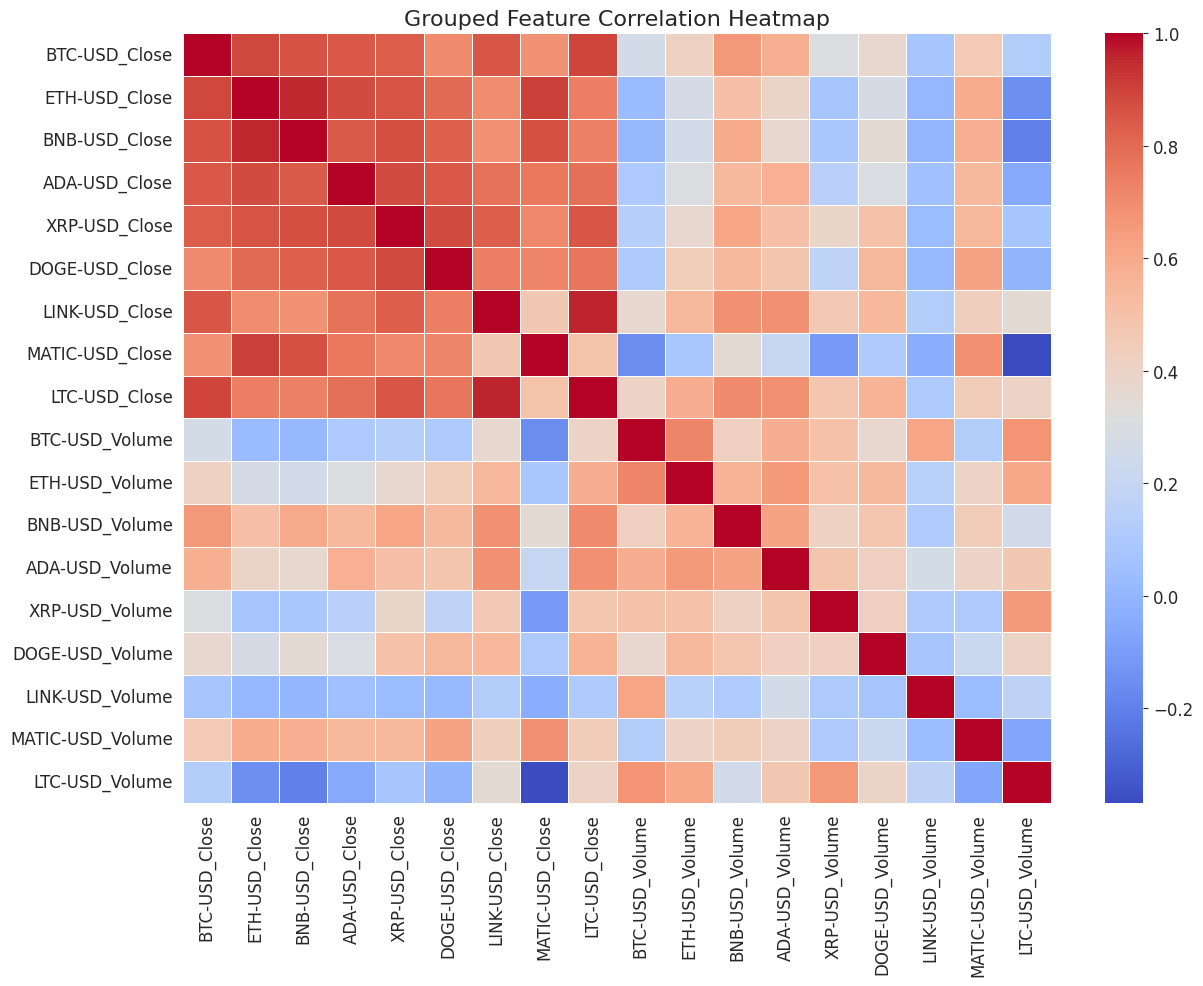


⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**



,level_0,level_1,correlation
1,BTC-USD_Close,ETH-USD_Close,0.889154
2,BTC-USD_Close,BNB-USD_Close,0.861800
3,BTC-USD_Close,ADA-USD_Close,0.847657
4,BTC-USD_Close,XRP-USD_Close,0.838512
6,BTC-USD_Close,LINK-USD_Close,0.854969
8,BTC-USD_Close,LTC-USD_Close,0.895449
18,ETH-USD_Close,BTC-USD_Close,0.889154
20,ETH-USD_Close,BNB-USD_Close,0.955522
21,ETH-USD_Close,ADA-USD_Close,0.881874
22,ETH-USD_Close,XRP-USD_Close,0.857794


In [86]:
############################### FEATURE ENGINEERING ###############################
# Convert train_data dictionary into a DataFrame
df_features = pd.DataFrame(train_data)  # Merging all crypto series into one DataFrame

# Compute correlation matrix
corr_matrix = df_features.corr()

# Extract group names from column names
def extract_group(feature_name):
    """Extracts the group name from the feature (assumes {crypto}_{group})"""
    return feature_name.split("_", 1)[-1]  # Takes everything after the first underscore

# Create a mapping of features to their groups
feature_groups = {col: extract_group(col) for col in df_features.columns}

# Sort features by group name
sorted_features = sorted(df_features.columns, key=lambda x: feature_groups[x])

# Reorder correlation matrix - group by feature group
corr_matrix = corr_matrix.loc[sorted_features, sorted_features]

# Plot heatmap with grouped features
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Grouped Feature Correlation Heatmap")
plt.xticks(ticks=np.arange(len(sorted_features)) + 0.5, labels=sorted_features, rotation=90)
plt.yticks(ticks=np.arange(len(sorted_features)) + 0.5, labels=sorted_features, rotation=0)
plt.show()

# Identify highly correlated feature pairs (absolute correlation > 0.8)
high_corr_pairs = (
    corr_matrix.abs()
    .stack()
    .reset_index()
    .rename(columns={0: "correlation"})
    .query("correlation > 0.8 and level_0 != level_1")
)

# Print results
print("\n⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**\n")
display(high_corr_pairs)


**Analysis:**<br>
The heatmap shows strong correlations between major cryptocurrencies like BTC-USD and ETH-USD (0.89), indicating similar price movements. Pairs such as BTC-USD_Close and LTC-USD_Close (0.89) and ETH-USD_Close and MATIC-USD_Close (0.91) are highly correlated, suggesting potential for portfolio risk reduction through diversification. Correlations between price and volume vary, with some assets like DOGE-USD showing less predictable relationships. This analysis is crucial for optimizing portfolios and managing risk.

---

### **2.3.2 - Adding Features**
New features were generated from the original data to enhance the model. These included:
1. Log Returns: Calculated for each cryptocurrency to assess daily percentage changes in price.
2. Rolling Volatility (30-day): Measures price fluctuation over a 30-day window.
3. Simple Moving Averages (SMA): 7-day and 30-day moving averages were computed to capture short-term and long-term price trends.
4. Relative Strength Index (RSI): Indicates overbought or oversold conditions.
5. MACD (Moving Average Convergence Divergence): Measures the relationship between short- and long-term price trends.
6. Drawdowns: Measures the peak-to-trough decline in price to assess risk and volatility during downturns.

In [88]:
############################### FEATURE ENGINEERING - ADDING FEATURES ###############################
# Convert `train_data` dictionary into a DataFrame
df_features = pd.DataFrame(train_data)

# Ensure Index is in Proper DateTime Format
df_features.index = pd.to_datetime(df_features.index, errors='coerce')
df_features = df_features.sort_index()

# Initialize Feature Dictionary
new_features = {}

# Iterate over columns and generate only **relevant** features
for col in df_features.columns:
    if '_Close' in col:
        crypto_name = col.replace('_Close', '')

        # Ensure values are numeric to prevent NaN propagation
        df_features[col] = pd.to_numeric(df_features[col], errors='coerce')

        # 1. **Log Returns**
        new_features[f'{crypto_name}_Log_Return'] = np.log(df_features[col] / df_features[col].shift(1))

        # 2.**Rolling Volatility (30-day)**
        new_features[f'{crypto_name}_Volatility_30d'] = (
            new_features[f'{crypto_name}_Log_Return'].rolling(window=30).std()
        )

        # 3. **Simple Moving Averages (SMA)**
        new_features[f'{crypto_name}_SMA_7D'] = df_features[col].rolling(window=7).mean()
        new_features[f'{crypto_name}_SMA_30D'] = df_features[col].rolling(window=30).mean()

        # 4. **Relative Strength Index (RSI)**
        delta = df_features[col].diff()
        gain = np.where(delta > 0, delta, 0)
        loss = np.where(delta < 0, -delta, 0)

        avg_gain = pd.Series(gain, index=df_features.index).rolling(window=14, min_periods=1).mean()
        avg_loss = pd.Series(loss, index=df_features.index).rolling(window=14, min_periods=1).mean()

        rs = avg_gain / (avg_loss + 1e-9)  # Avoid division by zero
        new_features[f'{crypto_name}_RSI'] = (100 - (100 / (1 + rs))).round(2)

        # 5. **MACD (Moving Average Convergence Divergence)**
        short_ema = df_features[col].ewm(span=12, adjust=False).mean()
        long_ema = df_features[col].ewm(span=26, adjust=False).mean()
        macd_line = short_ema - long_ema
        signal_line = macd_line.ewm(span=9, adjust=False).mean()

        new_features[f'{crypto_name}_MACD'] = macd_line.round(2)
        new_features[f'{crypto_name}_MACD_Signal'] = signal_line.round(2)

# Convert New Features to DataFrame & Round Values to 2 Decimals
df_new_features = pd.DataFrame(new_features).round(2).fillna(method='bfill').fillna(0)  # Handle missing values

# Identify Log Return Features (For drawdown calculation)
log_return_features = [col for col in df_new_features.columns if '_Log_Return' in col]

if log_return_features:
    print("\n - Computing Drawdowns for Log Returns...")

    def calculate_drawdowns(series):
        """ Optimized drawdown calculation for Log Returns only """
        series = series.replace([np.inf, -np.inf], np.nan).fillna(0)
        cumulative_returns = np.exp(series.cumsum().clip(-50, 50))
        peak = cumulative_returns.cummax()
        drawdown = (cumulative_returns - peak) / peak
        return drawdown.round(2)

    # Apply Drawdown Calculation
    drawdown_features = df_new_features[log_return_features].apply(calculate_drawdowns).add_suffix("_Drawdown")

    # Append Drawdown Features
    df_new_features = pd.concat([df_new_features, drawdown_features], axis=1)

# Combine All Features & Round Again to Ensure Consistency
df_features = pd.concat([df_features, df_new_features], axis=1).round(2)

# Drop NaN values that result from shifting operations
df_features.dropna(inplace=True)

############################### DISPLAY SUMMARY ###############################

print("\n **Feature Engineering Complete! Summary of New Features:**\n")
display(df_features.describe())

# Check Final DataFrame Shape
print("\n - **Final DataFrame Shape:**", df_features.shape)


<ipython-input-88-9a5a6015a142>:53: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.




 - Computing Drawdowns for Log Returns...

 **Feature Engineering Complete! Summary of New Features:**



,BTC-USD_Close,BTC-USD_Volume,ETH-USD_Close,ETH-USD_Volume,BNB-USD_Close,BNB-USD_Volume,ADA-USD_Close,ADA-USD_Volume,XRP-USD_Close,XRP-USD_Volume,...,LTC-USD_MACD_Signal,BTC-USD_Log_Return_Drawdown,ETH-USD_Log_Return_Drawdown,BNB-USD_Log_Return_Drawdown,ADA-USD_Log_Return_Drawdown,XRP-USD_Log_Return_Drawdown,DOGE-USD_Log_Return_Drawdown,LINK-USD_Log_Return_Drawdown,MATIC-USD_Log_Return_Drawdown,LTC-USD_Log_Return_Drawdown
count,913.000000,9.130000e+02,913.000000,9.130000e+02,913.000000,9.130000e+02,913.000000,9.130000e+02,913.000000,9.130000e+02,...,913.000000,913.000000,913.000000,913.000000,913.000000,913.000000,913.000000,913.000000,913.000000,913.000000
mean,31609.063308,3.763052e+10,1834.067448,2.011992e+10,250.465279,1.720860e+09,0.837809,2.180011e+09,0.584337,4.094080e+09,...,0.004217,-0.250274,-0.247218,-0.294228,-0.347218,-0.411752,-0.499869,-0.449671,-0.377908,-0.438510
std,17418.750896,1.954623e+10,1325.130995,1.039194e+10,198.837481,1.729390e+09,0.732398,2.544957e+09,0.361792,4.644966e+09,...,8.026742,0.213240,0.212111,0.193344,0.277520,0.226141,0.285573,0.273662,0.223755,0.271229
min,4970.790000,1.225260e+10,110.610000,5.109033e+09,9.390000,1.365992e+08,0.020000,6.484569e+07,0.140000,4.987595e+08,...,-27.150000,-0.720000,-0.770000,-0.710000,-0.860000,-0.820000,-0.920000,-0.900000,-0.880000,-0.890000
25%,11878.370000,2.590558e+10,399.920000,1.343309e+10,28.080000,4.344649e+08,0.120000,6.071842e+08,0.260000,1.628784e+09,...,-3.790000,-0.410000,-0.400000,-0.440000,-0.590000,-0.580000,-0.770000,-0.680000,-0.530000,-0.670000
50%,33746.000000,3.349994e+10,1803.910000,1.755705e+10,286.050000,1.384576e+09,0.640000,1.227753e+09,0.490000,2.380083e+09,...,-0.010000,-0.210000,-0.200000,-0.290000,-0.300000,-0.400000,-0.500000,-0.470000,-0.390000,-0.450000
75%,46188.450000,4.406839e+10,2934.140000,2.357156e+10,405.020000,2.200879e+09,1.310000,2.798264e+09,0.830000,4.325860e+09,...,3.530000,-0.060000,-0.060000,-0.120000,-0.090000,-0.210000,-0.270000,-0.200000,-0.200000,-0.220000
max,67566.830000,3.509679e+11,4812.090000,8.448291e+10,675.680000,1.798295e+10,2.970000,1.914198e+10,1.840000,3.695518e+10,...,25.890000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



 - **Final DataFrame Shape:** (913, 90)


### **2.3.3 -  Feature Selection**

#### ***Feature Importance (Random Forests)***
*Bonus analysis for feature importance.*


Training Random Forest for BTC-USD_Log_Return...

Model training complete for BTC-USD_Log_Return!


<ipython-input-93-d3a2281e3f45>:41: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




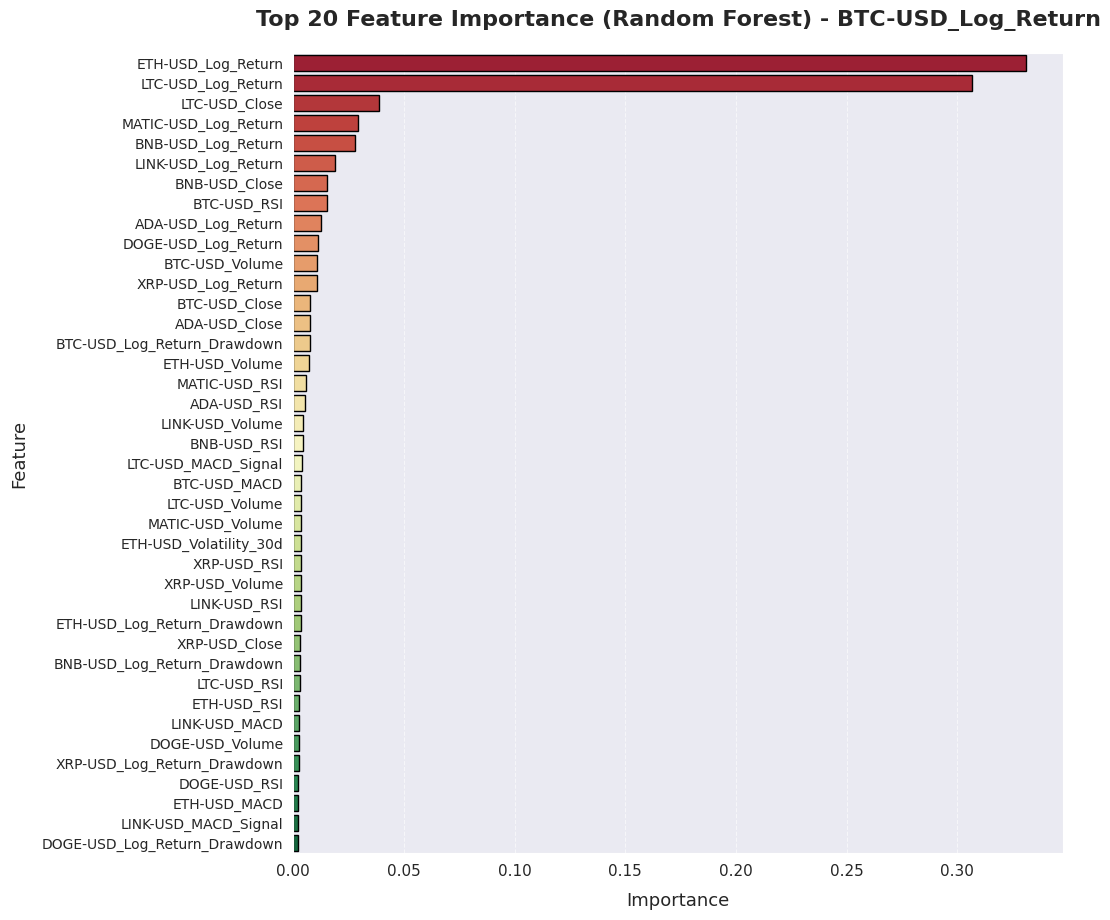


 **Feature Importance Analysis Complete for Selected Cryptos.**


In [93]:
############################### FEATURE ANALYSIS RANDOM FORESTS ###############################
# Set global Seaborn style for clean, professional plots
sns.set_style("darkgrid")

# Selected target cryptocurrency
selected_cryptos = ["BTC-USD_Log_Return"]
log_return_targets = [col for col in df_features.columns if col in selected_cryptos]

# Ensure at least one target is found
if not log_return_targets:
    raise ValueError("X - No Log Return columns found for BTC, ETH, or BNB. Ensure feature engineering includes log returns.")

# Function for training and feature importance analysis
def train_and_plot(target):
    print(f"\nTraining Random Forest for {target}...\n")

    # Define Features & Target
    X = df_features.drop(columns=[target])  # Drop the current target variable
    y = df_features[target]  # Predicting the current crypto's log return

    # Split Data into Train & Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Random Forest Model
    model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)  # Reduce trees and use parallel jobs
    model.fit(X_train, y_train)
    print(f"Model training complete for {target}!")

    # Feature Importance Analysis
    feature_importances = model.feature_importances_
    features = X.columns

    importance_df = pd.DataFrame({"Feature": features, "Importance": feature_importances}).sort_values(
        by="Importance", ascending=False
    )

    # Limit to top 20 features for better visualization
    importance_df = importance_df.head(40)

    # Plot Feature Importance
    plt.figure(figsize=(14, 10))
    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature",
        palette="RdYlGn",
        edgecolor="black"
    )

    plt.title(f"Top 20 Feature Importance (Random Forest) - {target}", fontsize=16, pad=20, fontweight="bold")
    plt.xlabel("Importance", fontsize=13, labelpad=10)
    plt.ylabel("Feature", fontsize=13, labelpad=10)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=10, ha="right")
    plt.subplots_adjust(left=0.4, right=0.95, top=0.9, bottom=0.1)
    plt.grid(axis="x", linestyle="--", alpha=0.6)
    plt.show()

# Train model and plot for selected target
for target in log_return_targets:
    train_and_plot(target)

# Final summary
print("\n **Feature Importance Analysis Complete for Selected Cryptos.**")


**Analysis:** <br>
The feature importance analysis using the Random Forest model highlights which features have the most predictive power for the target variable, in this case, the log returns for BTC-USD. The bar plot shows the top features that most influence the model's prediction, with ETH-USD_Log_Return and LTC-USD_Close emerging as the most significant predictors. The Random Forest model identifies that historical log returns of Ethereum and Bitcoin, as well as specific features like the closing price of Litecoin, play key roles in forecasting Bitcoin's returns. This analysis provides insights into the relationships between the selected cryptocurrency features and BTC's future performance, which can be useful for further refining predictive models or portfolio optimization strategies.

---

### ***2.3.4 - Feature Selection Finalization***

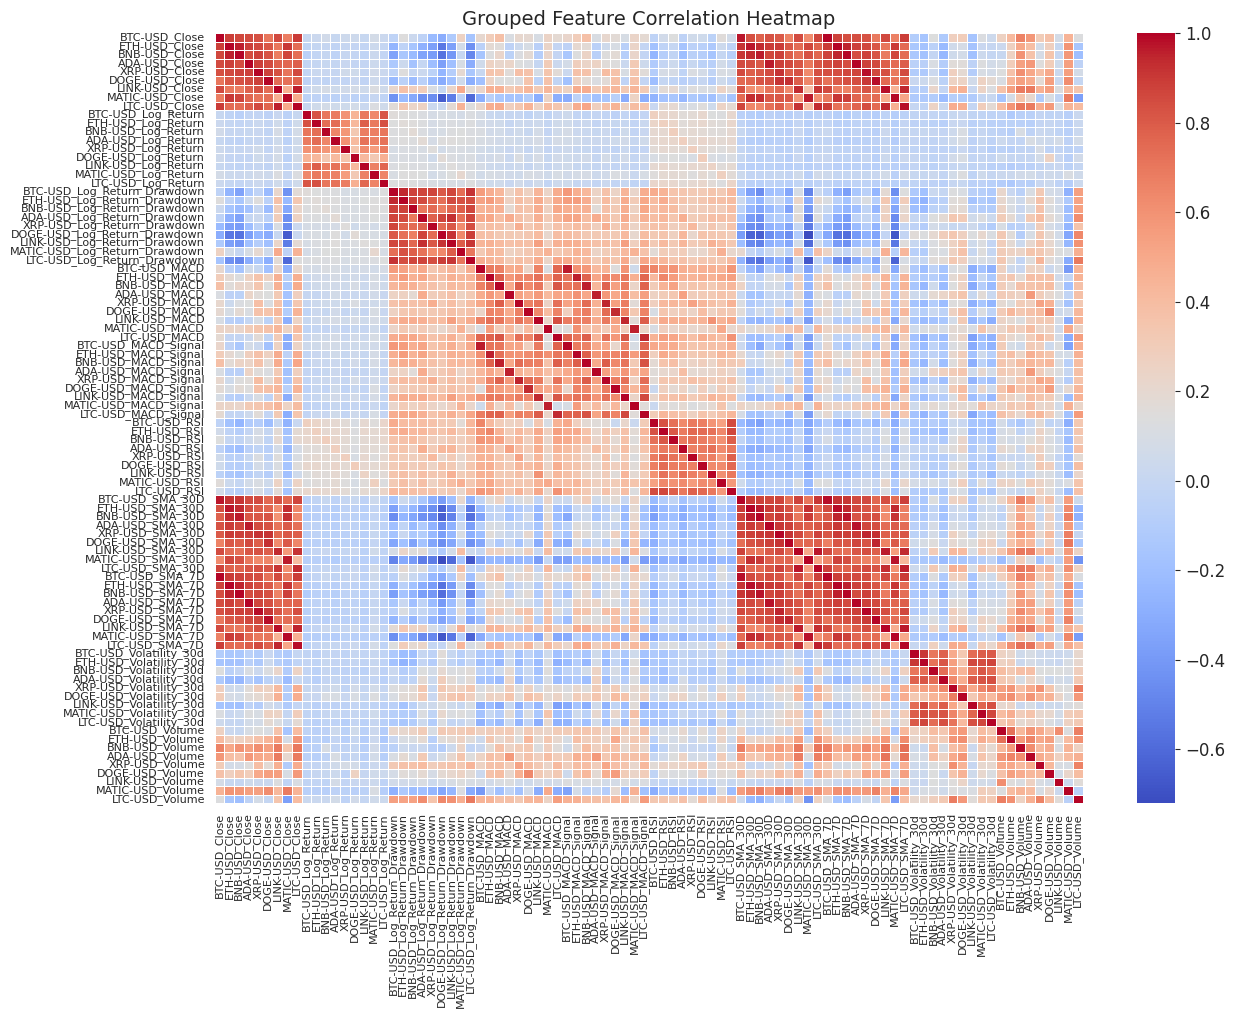


⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**



,level_0,level_1,correlation
1,BTC-USD_Close,ETH-USD_Close,0.889154
2,BTC-USD_Close,BNB-USD_Close,0.861800
3,BTC-USD_Close,ADA-USD_Close,0.847636
4,BTC-USD_Close,XRP-USD_Close,0.838535
6,BTC-USD_Close,LINK-USD_Close,0.854971
...,...,...,...
7190,MATIC-USD_Volatility_30d,LTC-USD_Volatility_30d,0.862428
7273,LTC-USD_Volatility_30d,ETH-USD_Volatility_30d,0.870471
7275,LTC-USD_Volatility_30d,ADA-USD_Volatility_30d,0.836382
7278,LTC-USD_Volatility_30d,LINK-USD_Volatility_30d,0.832670


In [94]:
############################### FEATURE SELECTION ###############################
# Compute correlation matrix
corr_matrix = df_features.corr()

# Extract group names from column names
def extract_group(feature_name):
    """Extracts the group name from the feature (assumes {crypto}_{group})"""
    return feature_name.split("_", 1)[-1]  # Takes everything after the first underscore

# Create a mapping of features to their groups
feature_groups = {col: extract_group(col) for col in df_features.columns}

# Sort features by group name
sorted_features = sorted(df_features.columns, key=lambda x: feature_groups[x])

# Reorder correlation matrix
corr_matrix = corr_matrix.loc[sorted_features, sorted_features]

# Plot heatmap with **smaller labels**
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Grouped Feature Correlation Heatmap", fontsize=14)

# Reduce label size for better readability
plt.xticks(
    ticks=np.arange(len(sorted_features)) + 0.5,
    labels=sorted_features,
    rotation=90,
    fontsize=8  # Adjust font size (smaller)
)

plt.yticks(
    ticks=np.arange(len(sorted_features)) + 0.5,
    labels=sorted_features,
    rotation=0,
    fontsize=8  # Adjust font size (smaller)
)

plt.show()

# Identify highly correlated feature pairs (absolute correlation > 0.8)
high_corr_pairs = (
    corr_matrix.abs()
    .stack()
    .reset_index()
    .rename(columns={0: "correlation"})
    .query("correlation > 0.8 and level_0 != level_1")
)

print("\n⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**\n")
display(high_corr_pairs)


**Analysis**: <br>
The correlation heatmap reveals patterns of interrelationships between various cryptocurrency features. The analysis identifies clusters of highly correlated features, indicating significant relationships among different cryptos' prices, SMAs, RSIs, MACDs, and volatility indicators. For example, the BTC-USD_Close feature shows strong correlations with other cryptocurrencies like ETH-USD_Close, BNB-USD_Close, and LTC-USD_Close. High correlations also appear between the 7-day and 30-day Simple Moving Averages (SMA) for multiple assets, as well as between the MACD and its signal for different coins. Features like the BTC-USD_SMA_30D and ETH-USD_SMA_30D exhibit notable correlations, highlighting the shared movement of cryptocurrencies' SMAs over different periods.
<br><br>
From a feature selection standpoint, these correlations suggest potential redundancy in the data, as features with high correlation (greater than 0.8) may provide similar predictive power. By removing highly correlated pairs, you can streamline the model, reducing complexity without losing predictive accuracy. This can enhance model performance by mitigating multicollinearity and focusing on the most important, independent features for training.

---

In [95]:
###############################  FEATURE SELECTION (Optimized for Portfolio Optimization) ###############################
#  Step 1: Define Feature Removal Flags
remove_sma = True  # Remove all SMA features (_SMA_7d and _SMA_30d)
remove_market_cap = True  # Remove all _Market_Cap features
remove_marketcap_to_volume = True  # Remove all _MarketCap_to_Volume features
remove_volume = True  # Remove all _Volume features (including _Volume_Change)
remove_macd = False  # Remove all _MACD features
remove_rsi = False  # Remove all _RSI features
remove_log_return_drawdown = True  # Remove all _Log_Return_Drawdown features

# Step 2: Identify Columns to Remove
features_to_drop = []

for col in df_features.columns:
    if remove_sma and ("_SMA_7D" in col or "_SMA_30D" in col):
        features_to_drop.append(col)
    if remove_market_cap and "_Market_Cap" in col: # if we readd marketcap
        features_to_drop.append(col)
    if remove_marketcap_to_volume and "_MarketCap_to_Volume" in col: # based on addiiton of marketcap
        features_to_drop.append(col)
    if remove_volume and ("_Volume" in col or "_Volume_Change" in col):
        features_to_drop.append(col)
    if remove_macd and "_MACD" in col:
        features_to_drop.append(col)
    if remove_rsi and "_RSI" in col:
        features_to_drop.append(col)
    if remove_log_return_drawdown and "_Log_Return_Drawdown" in col:
        features_to_drop.append(col)

# Step 3: Drop Selected Features
df_selected = df_features.drop(columns=features_to_drop, errors='ignore')

# Step 4: Confirm Shape After Feature Selection
print("\n **Feature Selection Completed! Final Data Shape:**", df_selected.shape)
print(f"Removed {len(features_to_drop)} Features")
display(df_selected.head())


 **Feature Selection Completed! Final Data Shape:** (913, 54)
Removed 36 Features


,BTC-USD_Close,ETH-USD_Close,BNB-USD_Close,ADA-USD_Close,XRP-USD_Close,DOGE-USD_Close,LINK-USD_Close,MATIC-USD_Close,LTC-USD_Close,BTC-USD_Log_Return,...,MATIC-USD_Log_Return,MATIC-USD_Volatility_30d,MATIC-USD_RSI,MATIC-USD_MACD,MATIC-USD_MACD_Signal,LTC-USD_Log_Return,LTC-USD_Volatility_30d,LTC-USD_RSI,LTC-USD_MACD,LTC-USD_MACD_Signal
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-01,8562.45,218.97,18.96,0.05,0.23,0.0,3.88,0.02,57.96,0.04,...,0.09,0.16,0.0,0.0,0.0,0.05,0.11,0.00,0.00,0.00
2020-03-02,8869.67,230.57,19.81,0.05,0.24,0.0,4.22,0.02,61.00,0.04,...,0.09,0.16,100.0,0.0,0.0,0.05,0.11,100.00,0.24,0.05
2020-03-03,8787.79,224.48,19.64,0.05,0.23,0.0,4.58,0.02,61.14,-0.01,...,0.10,0.16,100.0,0.0,0.0,0.00,0.11,100.00,0.44,0.13
2020-03-04,8755.25,224.52,19.96,0.05,0.23,0.0,4.64,0.03,60.38,-0.00,...,0.07,0.16,100.0,0.0,0.0,-0.01,0.11,80.71,0.53,0.21
2020-03-05,9078.76,229.27,20.80,0.05,0.24,0.0,4.72,0.03,62.05,0.04,...,0.05,0.16,100.0,0.0,0.0,0.03,0.11,86.42,0.73,0.31


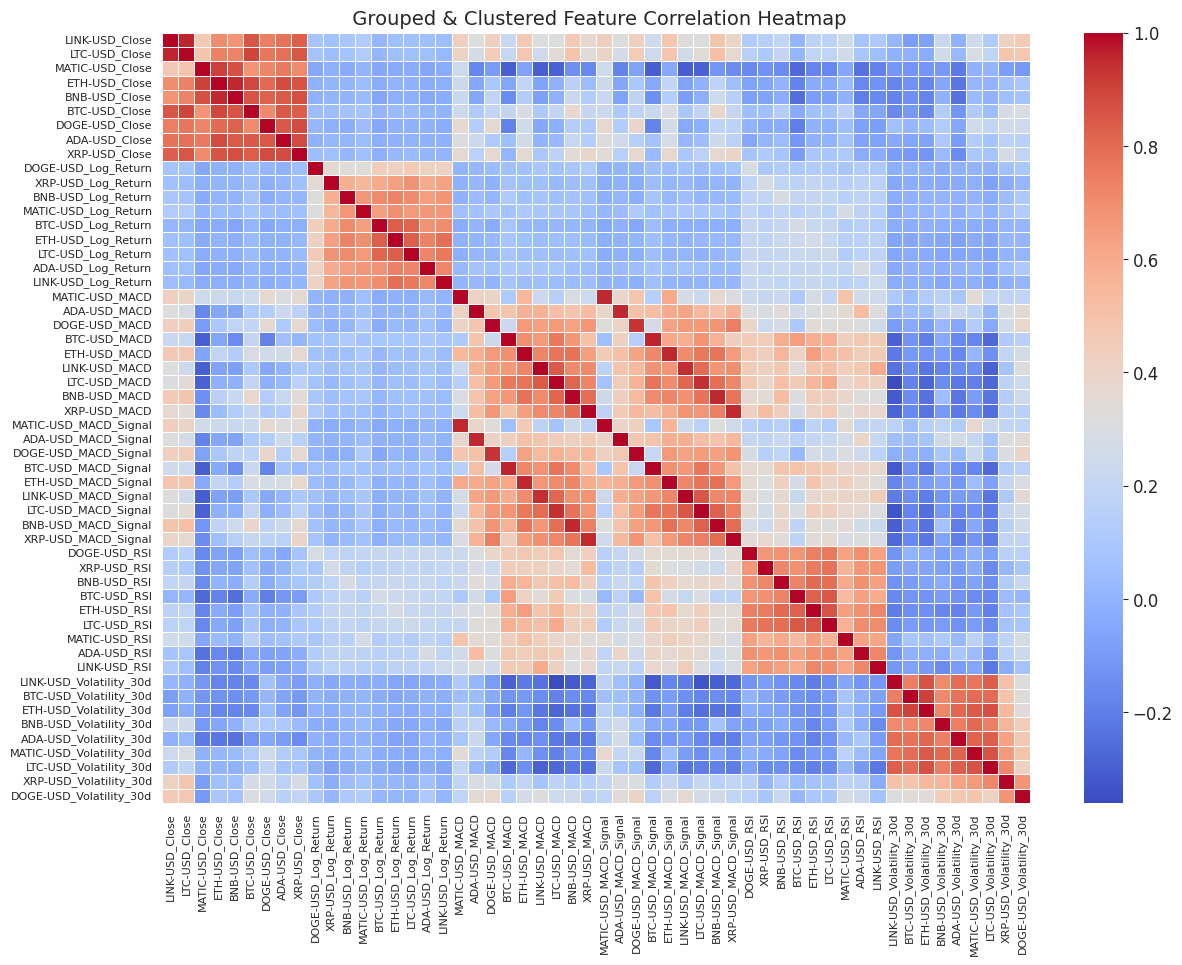


⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**



,level_0,level_1,correlation
1,LINK-USD_Close,LTC-USD_Close,0.958220
5,LINK-USD_Close,BTC-USD_Close,0.854971
8,LINK-USD_Close,XRP-USD_Close,0.834097
54,LTC-USD_Close,LINK-USD_Close,0.958220
59,LTC-USD_Close,BTC-USD_Close,0.895449
...,...,...,...
2751,MATIC-USD_Volatility_30d,LTC-USD_Volatility_30d,0.862428
2799,LTC-USD_Volatility_30d,LINK-USD_Volatility_30d,0.832670
2801,LTC-USD_Volatility_30d,ETH-USD_Volatility_30d,0.870471
2803,LTC-USD_Volatility_30d,ADA-USD_Volatility_30d,0.836382


In [96]:
###############################  Dynamic Feature Grouping ###############################
# Compute correlation matrix
corr_matrix = df_selected.corr()

# Extract group names from column names
def extract_group(feature_name):
    """Extracts the group name from the feature (assumes {crypto}_{group})"""
    return feature_name.split("_", 1)[-1]  # Takes everything after the first underscore

#  Create a mapping of features to their groups
feature_groups = {col: extract_group(col) for col in df_selected.columns}

# Sort features by group name
sorted_features = sorted(df_selected.columns, key=lambda x: feature_groups[x])

#   Apply Hierarchical Clustering Within Each Group
final_sorted_features = []
unique_groups = sorted(set(feature_groups.values()))  # Unique sorted group names

for group in unique_groups:
    group_features = [f for f in sorted_features if feature_groups[f] == group]

    if len(group_features) > 1:  # Only apply clustering if multiple features exist
        sub_corr_matrix = df_selected[group_features].corr()

        if not sub_corr_matrix.isnull().values.all():  # Ensure clustering is possible
            linked = linkage(sub_corr_matrix.fillna(0), method='ward')
            ordered_indices = leaves_list(linked)
            ordered_group_features = [group_features[i] for i in ordered_indices]
        else:
            ordered_group_features = group_features  # No clustering needed

        final_sorted_features.extend(ordered_group_features)
    else:
        final_sorted_features.extend(group_features)

#  Reorder correlation matrix with new feature ordering
corr_matrix = corr_matrix.loc[final_sorted_features, final_sorted_features]

# Plot heatmap with **smaller labels**
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title(" Grouped & Clustered Feature Correlation Heatmap", fontsize=14)

# Reduce label size for better readability
plt.xticks(
    ticks=np.arange(len(final_sorted_features)) + 0.5,
    labels=final_sorted_features,
    rotation=90,
    fontsize=8  # Adjust font size (smaller)
)

plt.yticks(
    ticks=np.arange(len(final_sorted_features)) + 0.5,
    labels=final_sorted_features,
    rotation=0,
    fontsize=8  # Adjust font size (smaller)
)

plt.show()

###############################  Identifying Highly Correlated Features ###############################

# Identify highly correlated feature pairs (absolute correlation > 0.8)
high_corr_pairs = (
    corr_matrix.abs()
    .stack()
    .reset_index()
    .rename(columns={0: "correlation"})
    .query("correlation > 0.8 and level_0 != level_1")
)

print("\n⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**\n")
display(high_corr_pairs)


**Analysis:** <br>
The correlation matrix reveals that several features, particularly the `Close` prices of different cryptocurrencies, exhibit strong correlations (greater than 0.8). Notable pairs include `LINK-USD Close` and `BTC-USD Close` (0.95), `BTC-USD Close` and `ETH-USD Close` (0.89), and `ETH-USD Close` and `BNB-USD Close` (0.95). These high correlations suggest redundancy in the data, which could lead to multicollinearity in the model. Hierarchical clustering further identified groups of similar features, such as multiple `Close` prices and technical indicators like `SMA` and `RSI`, which could be reduced without significant loss of information.
<br><br>
Based on this analysis,certain features, like `BTC-USD Close` and `ETH-USD Close`, which are highly correlated (0.89), seem like they should be excluded to avoid redundancy. However, each group of features - Close prices, Log Returns,etc. - will either be completely included or excluded. Additionally, trend-following features such as `SMA` and `RSI`, along with `Volatility` indicators, should be retained as they provide complementary insights into market trends and volatility and are less likely to be redundant.
<br><br>
By excluding highly correlated features and focusing on distinct indicators, the model will be streamlined, reducing multicollinearity and enhancing its interpretability and efficiency.

---


---
---
# **Chapter 3 - Data Analysis**


## **3.1 - Statistical Summary**

In [97]:
############################### FEATURE SUMMARY ANALYSIS (All Features) ###############################
# Identify Feature Groups Dynamically
feature_summary = {}

for col in df_selected.columns:
    # Extract feature category dynamically
    match = re.search(r'_(Close|SMA_\d+d|Log_Return|Volatility_\d+d|Volume|MarketCap_to_Volume|RSI|MACD)$', col)

    if match:
        feature_type = match.group(1)  # Extract feature type
        crypto_name = col.replace(f"_{feature_type}", "")  # Extract crypto name
        data = df_selected[col].dropna()  # Drop NaN values

        # Compute statistics only if there is sufficient data
        if len(data) > 1:
            if feature_type not in feature_summary:
                feature_summary[feature_type] = {}

            feature_summary[feature_type][crypto_name] = [
                round(data.count(), 4), round(data.mean(), 4), round(data.std(), 4),
                round(data.max() - data.min(), 4), round(median_abs_deviation(data), 4),
                round(skew(data), 4), round(kurtosis(data), 4),
                round(data.min(), 4), round(data.quantile(0.25), 4),
                round(data.median(), 4), round(data.quantile(0.75), 4), round(data.max(), 4)
            ]

# Convert to DataFrames & Plot
summary_columns = ['Count', 'Mean', 'Std Dev', 'Range', 'MAD', 'Skewness', 'Kurtosis',
                   'Min', '25%', '50% (Median)', '75%', 'Max']

# Generate Summary Tables for Each Feature Type
for feature_type, summary_data in feature_summary.items():
    feature_summary_df = pd.DataFrame.from_dict(summary_data, orient='index', columns=summary_columns)

    # Drop NaN values before plotting
    feature_summary_df.dropna(inplace=True)

    # Plotly Table for each feature type
    fig = go.Figure(data=[go.Table(
        columnwidth=[150] + [70] * len(feature_summary_df.columns),  # Adjust width dynamically
        header=dict(values=["Cryptocurrency"] + list(feature_summary_df.columns),
                    fill_color='paleturquoise',
                    align='left'),
        cells=dict(values=[
            feature_summary_df.index,  # Ensure longer column width for crypto names
            feature_summary_df["Count"], feature_summary_df["Mean"], feature_summary_df["Std Dev"],
            feature_summary_df["Range"], feature_summary_df["MAD"],
            feature_summary_df["Skewness"], feature_summary_df["Kurtosis"],
            feature_summary_df["Min"], feature_summary_df["25%"], feature_summary_df["50% (Median)"],
            feature_summary_df["75%"], feature_summary_df["Max"]
        ],
        fill_color='lavender',
        align='left'))
    ])

    # Update layout
    fig.update_layout(title_text=f"- Statistical Summary ({feature_type})")
    fig.show()

    print(f"\n **Dashboard-Style Summary Completed for {feature_type}!**")



 **Dashboard-Style Summary Completed for Close!**



 **Dashboard-Style Summary Completed for Log_Return!**



 **Dashboard-Style Summary Completed for Volatility_30d!**



 **Dashboard-Style Summary Completed for RSI!**



 **Dashboard-Style Summary Completed for MACD!**


**Analysis**: <br>
Based on the statistical summary for various cryptocurrency features, the following is observed:
1. **Closing Price**:
   - The **mean** closing prices across the cryptocurrencies exhibit significant variation. For example, BTC-USD has a mean of 15100.96, whereas MATIC-USD is much lower at 0.67. This highlights the vast difference in market capitalization and value between different cryptocurrencies.
   - **Standard deviation** values are high, particularly for BTC-USD (12478.79), indicating significant volatility in the price movements.
   - **Range** values, representing the difference between the max and min closing prices, are similarly large. For example, BTC-USD has a range of 62905.48, showing considerable price fluctuations.
   - The **median** values for most cryptocurrencies are lower than the means, reflecting a slight skew toward lower values.
   
2. **Log Returns**:
   - The **mean** of log returns is close to zero for most cryptocurrencies, suggesting an overall balance between positive and negative returns.
   - **Standard deviations** for log returns show a moderate level of volatility, with ETH-USD having the highest at 0.0352. This suggests slightly greater fluctuations in return for ETH compared to other cryptocurrencies.
   - **Skewness** values are mostly negative, indicating that the distributions of log returns are skewed to the left (with more negative returns), particularly for ADA-USD, which has a skewness of -0.242.
   - The **kurtosis** values reflect distributions that are more peaked than a normal distribution, especially for MATIC-USD with a kurtosis of 10.16, suggesting extreme events or outliers in its returns.

3. **Volatility (30-day)**:
   - The **mean** volatility values are relatively low, indicating moderate daily price fluctuations over the 30-day period. However, **standard deviations** remain high, particularly for BTC-USD (0.0136), suggesting more significant movements in certain periods.
   - The **range** is relatively narrow across the cryptocurrencies, with most volatilities ranging between 0.01 and 0.02, except for BTC-USD, which reaches 0.09.
   
4. **RSI**:
   - The **mean** RSI values are mostly above 50 for most cryptocurrencies, indicating that they are, on average, neither overbought nor oversold. For instance, BTC-USD has a mean of 53.91, while ETH-USD has a mean of 52.93.
   - The **standard deviations** are relatively high (around 18.4), indicating that the RSI fluctuates significantly within a period.
   - **Minimum RSI values** are near 0, indicating that some cryptocurrencies occasionally experience oversold conditions. However, the **maximum** RSI values are also around 100, indicating overbought conditions at times.

5. **MACD**:
   - The **mean** values of the MACD for most cryptocurrencies are near zero, indicating that the short-term price movements are in balance with long-term trends.
   - There are some cryptocurrencies with higher **standard deviations**, like ADA-USD (0.0425), which could indicate more volatile momentum changes over time.
   - The **range** of MACD values is quite wide, especially for high volatility coins like BTC-USD, suggesting varying momentum strength.

<br><br>

#### **Summary**:
Based on the statistical summary, the following insights are drawn:
- **BTC-USD** shows high volatility, significant price fluctuations, and a higher mean closing price compared to other cryptocurrencies.
- Cryptocurrencies such as **MATIC-USD** and **LTC-USD** show lower mean prices but still demonstrate considerable volatility and price movement.
- **Log returns** for most cryptocurrencies are near zero, with distributions skewed slightly to the left, suggesting a balanced return profile overall.
- The **RSI** values indicate that most cryptocurrencies are near neutral in terms of market momentum (neither overbought nor oversold), with some occasional extremes.
- **MACD** values suggest that the short-term and long-term trends for most cryptocurrencies are in relative balance.

These statistics can guide decisions about which features to retain and which to exclude based on their variance, correlation, and relevance for further analysis or modeling.

<!--  -->

## **5.2 - Data Visualizations**

### ***5.2.1 - Histogram & KDE***

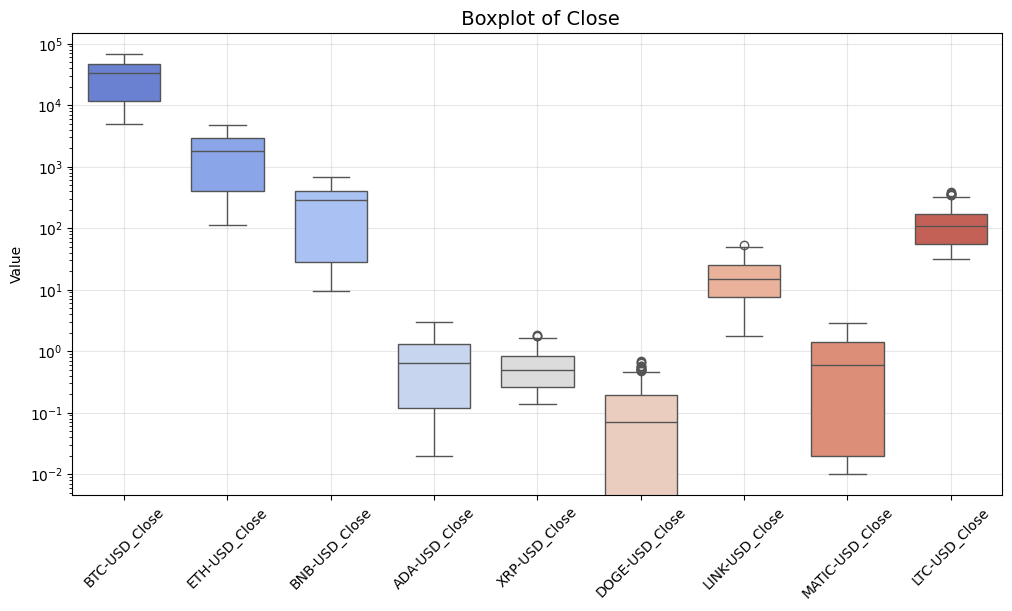

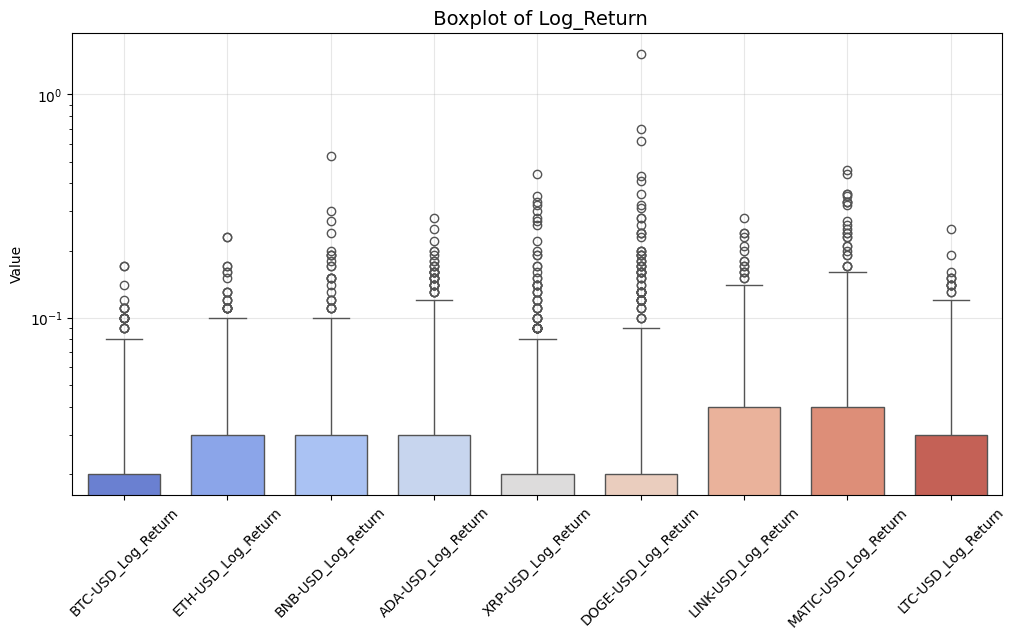

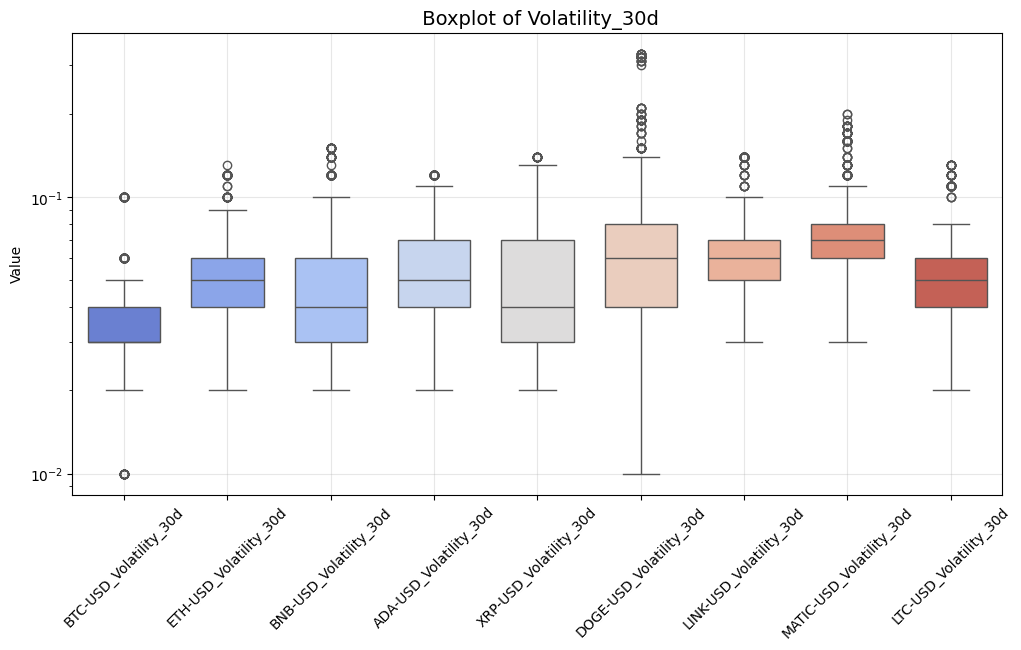

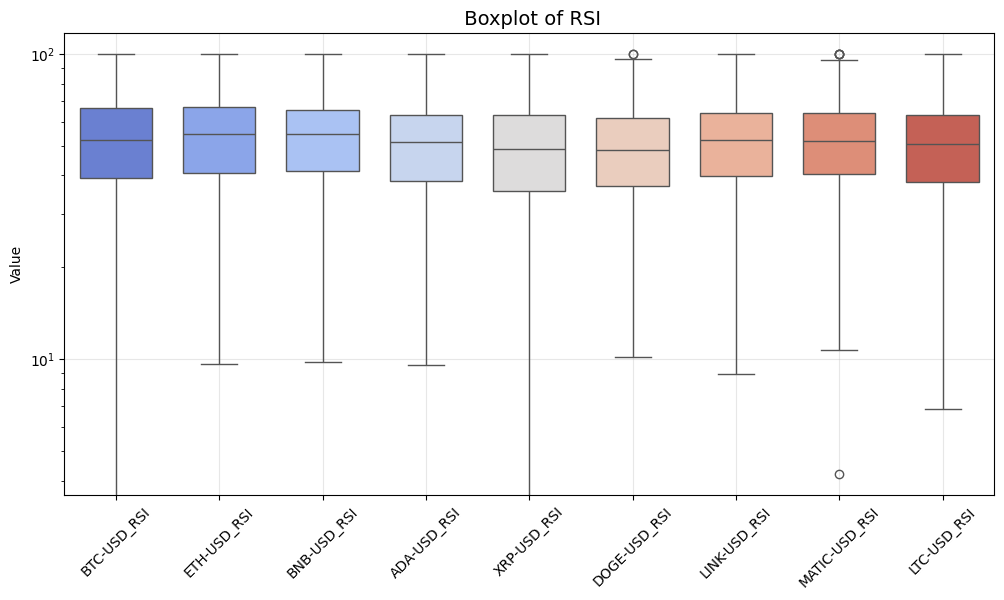

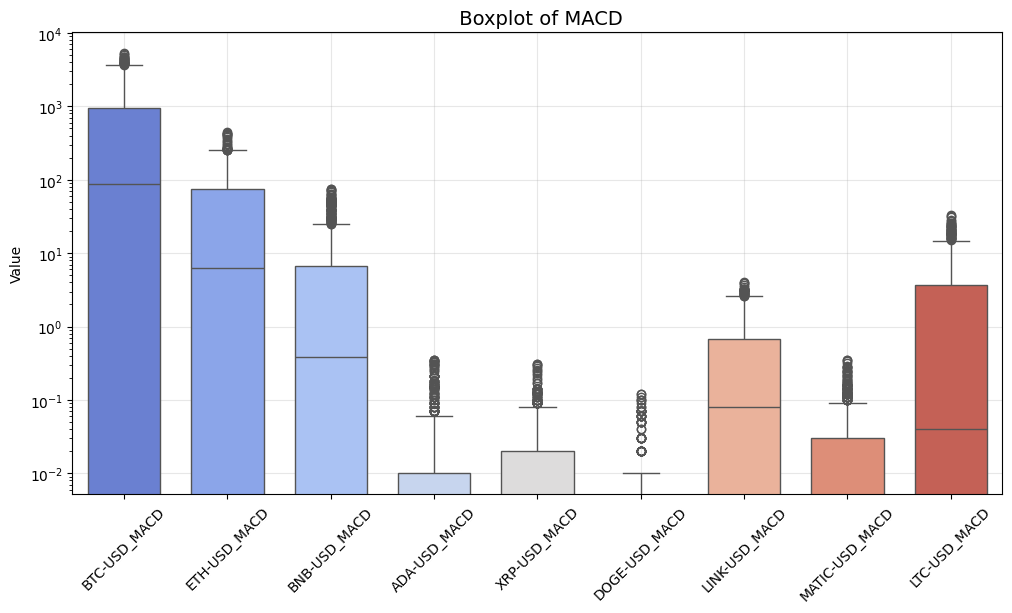

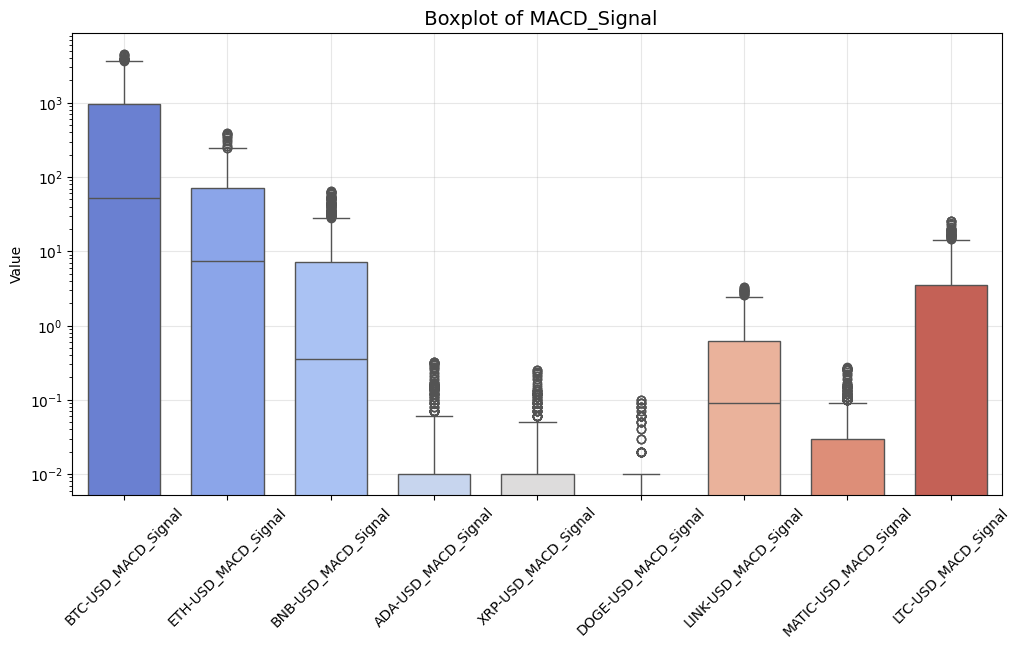

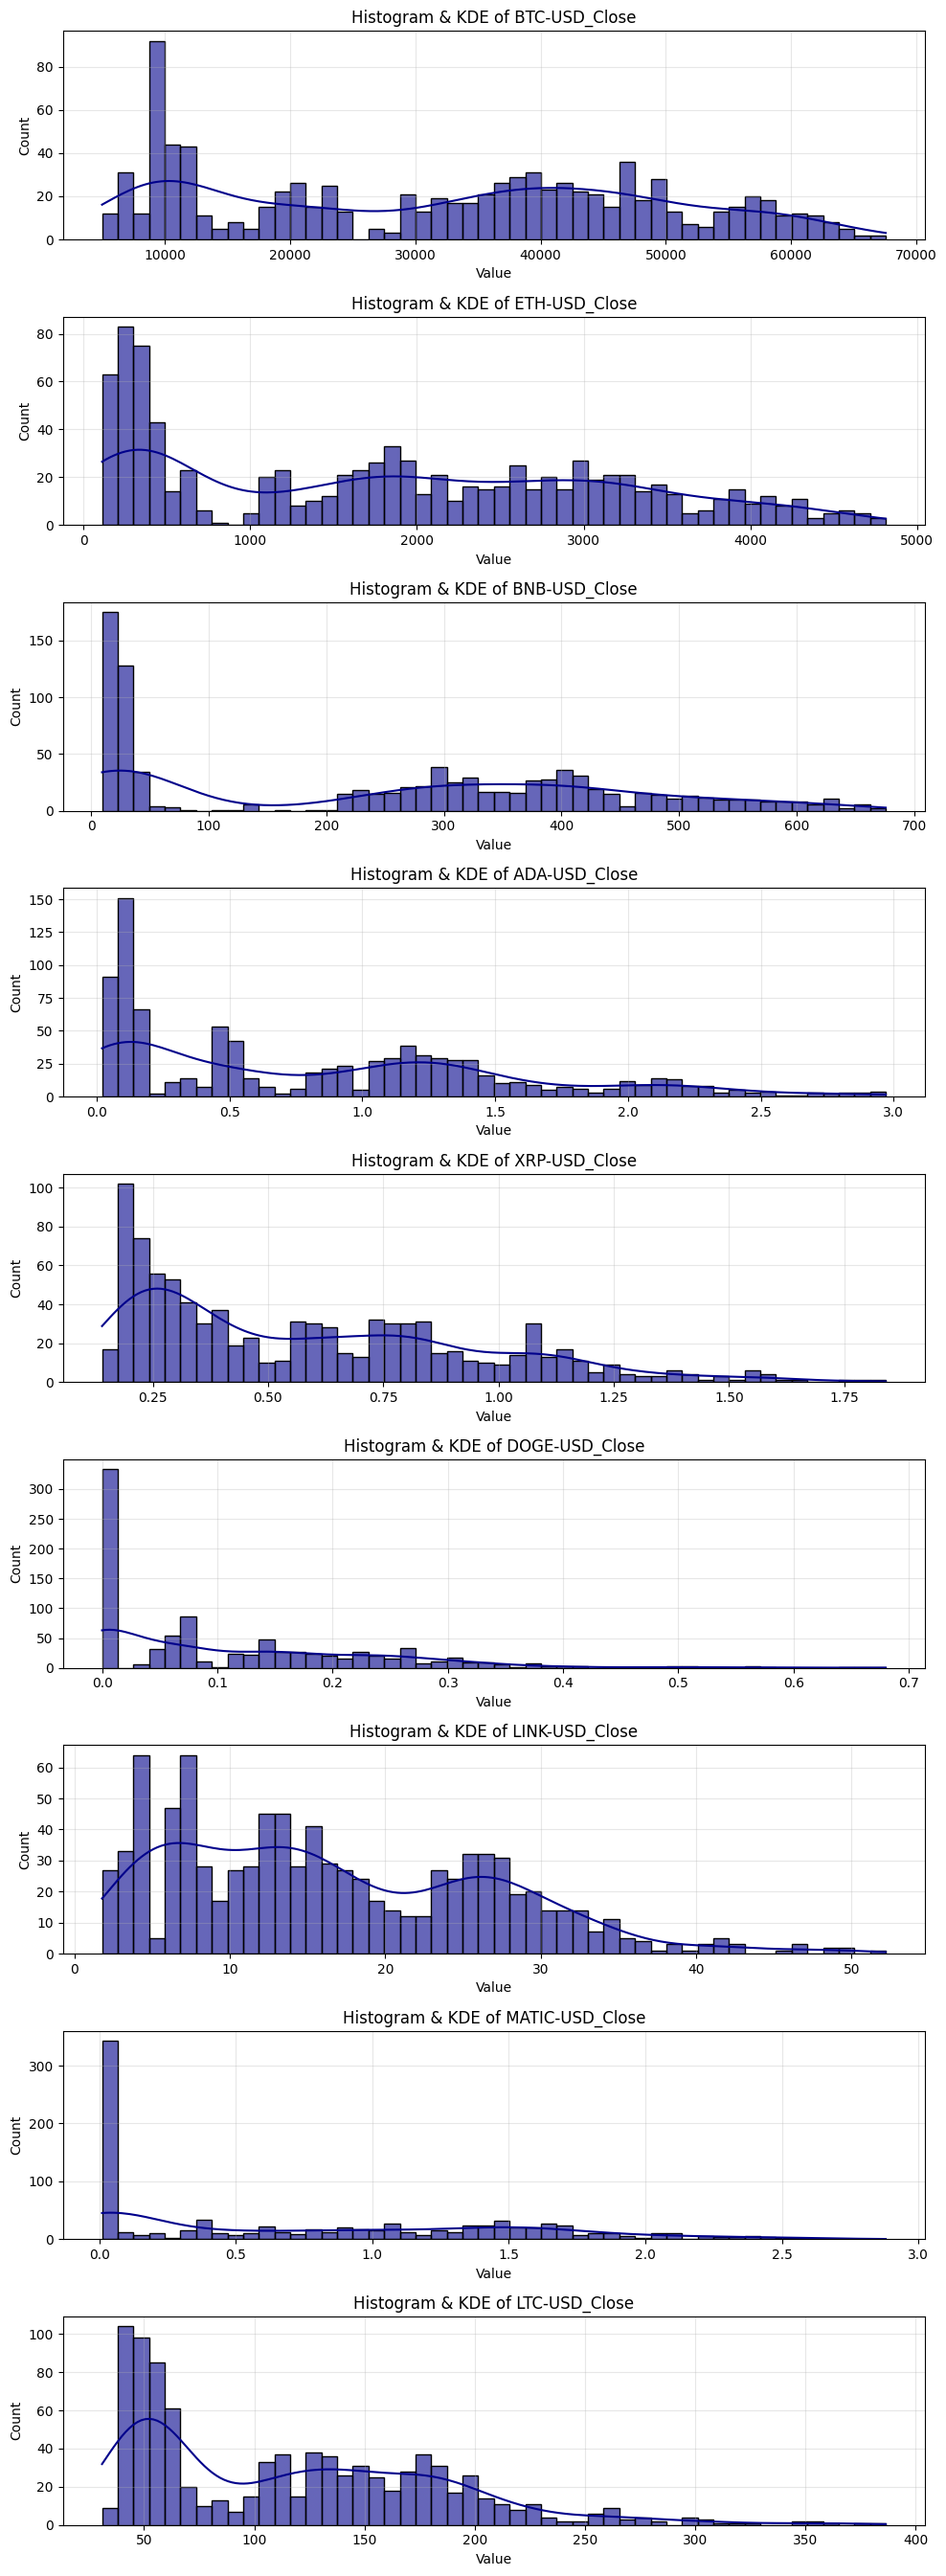

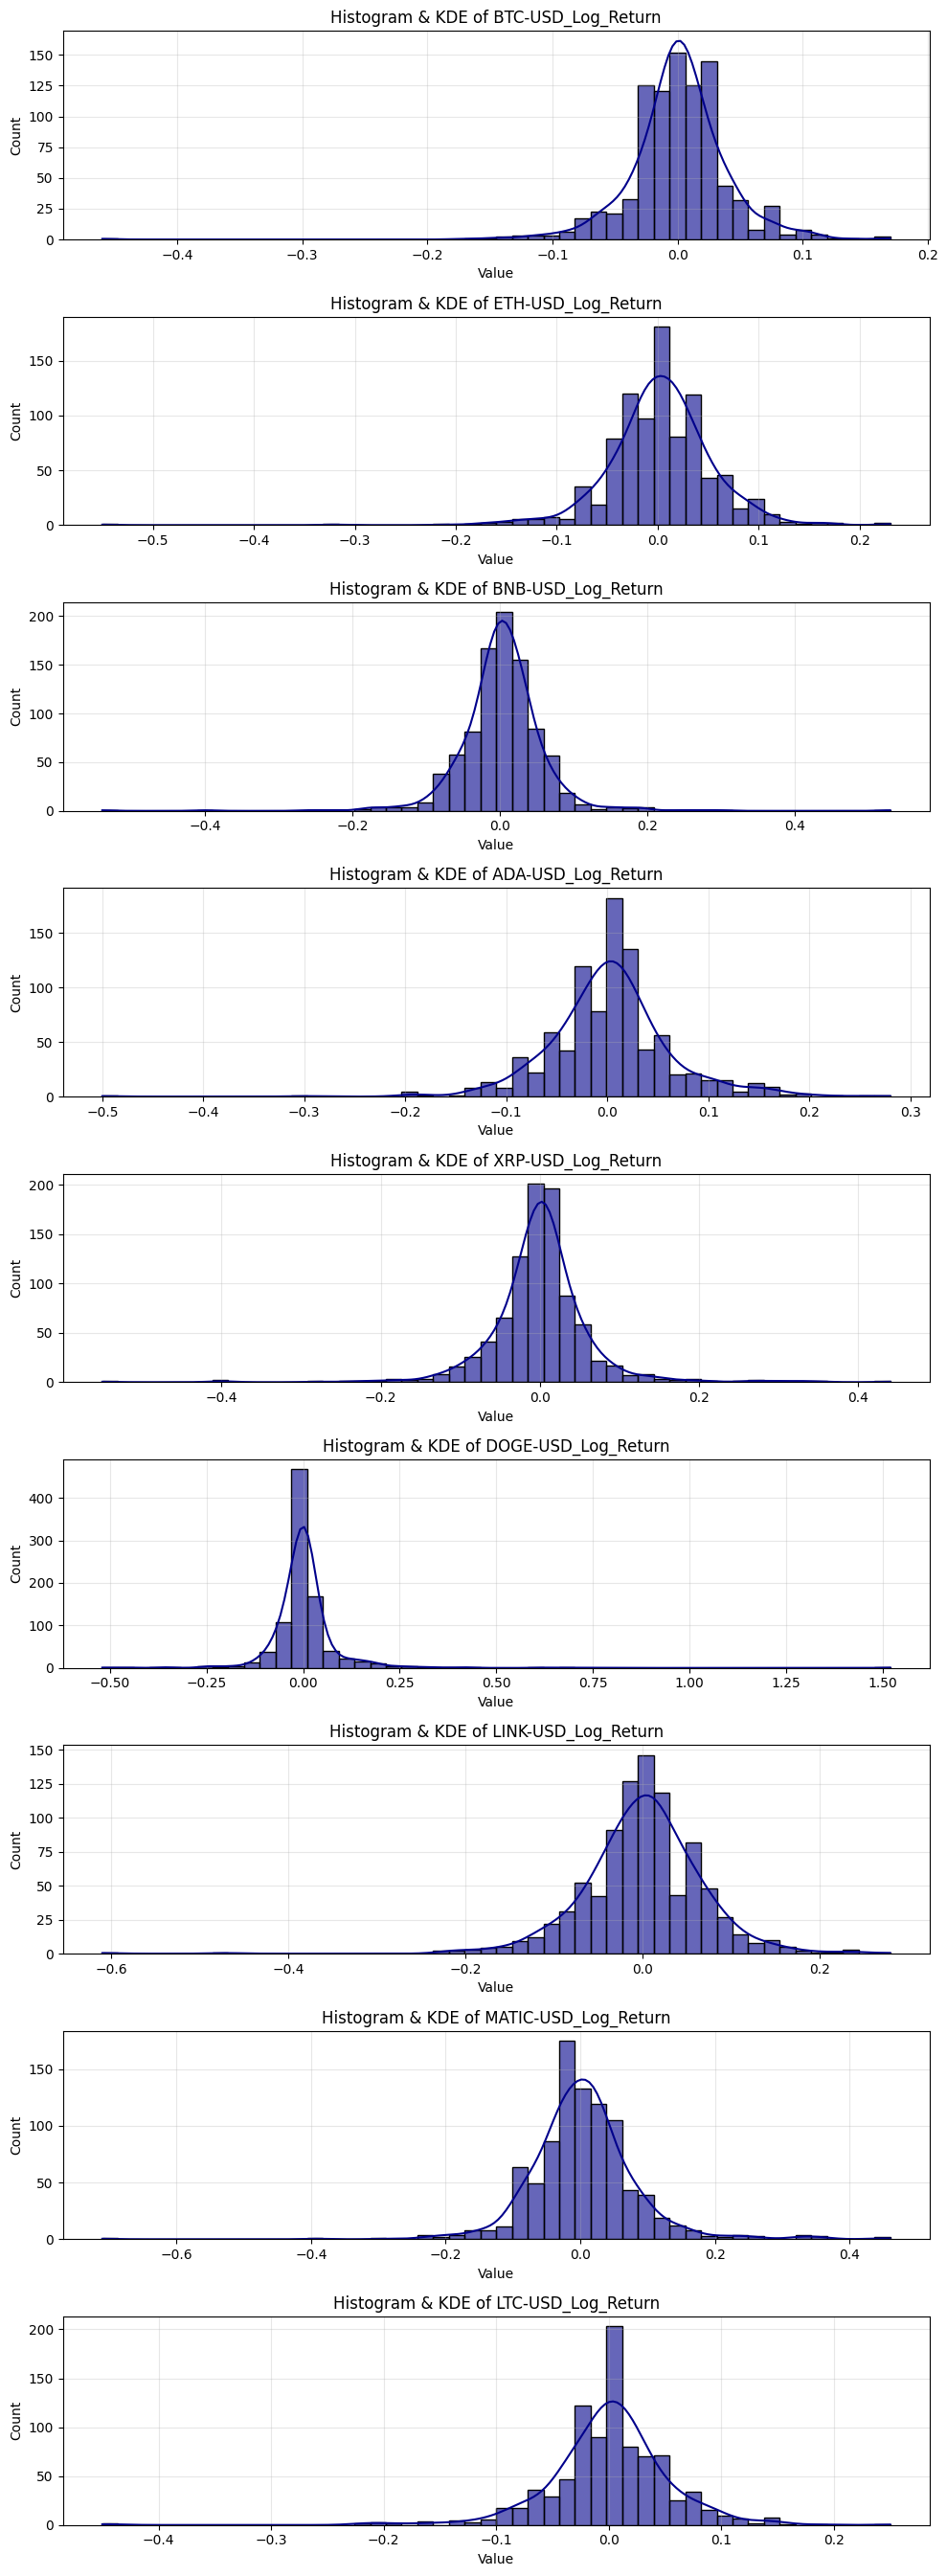

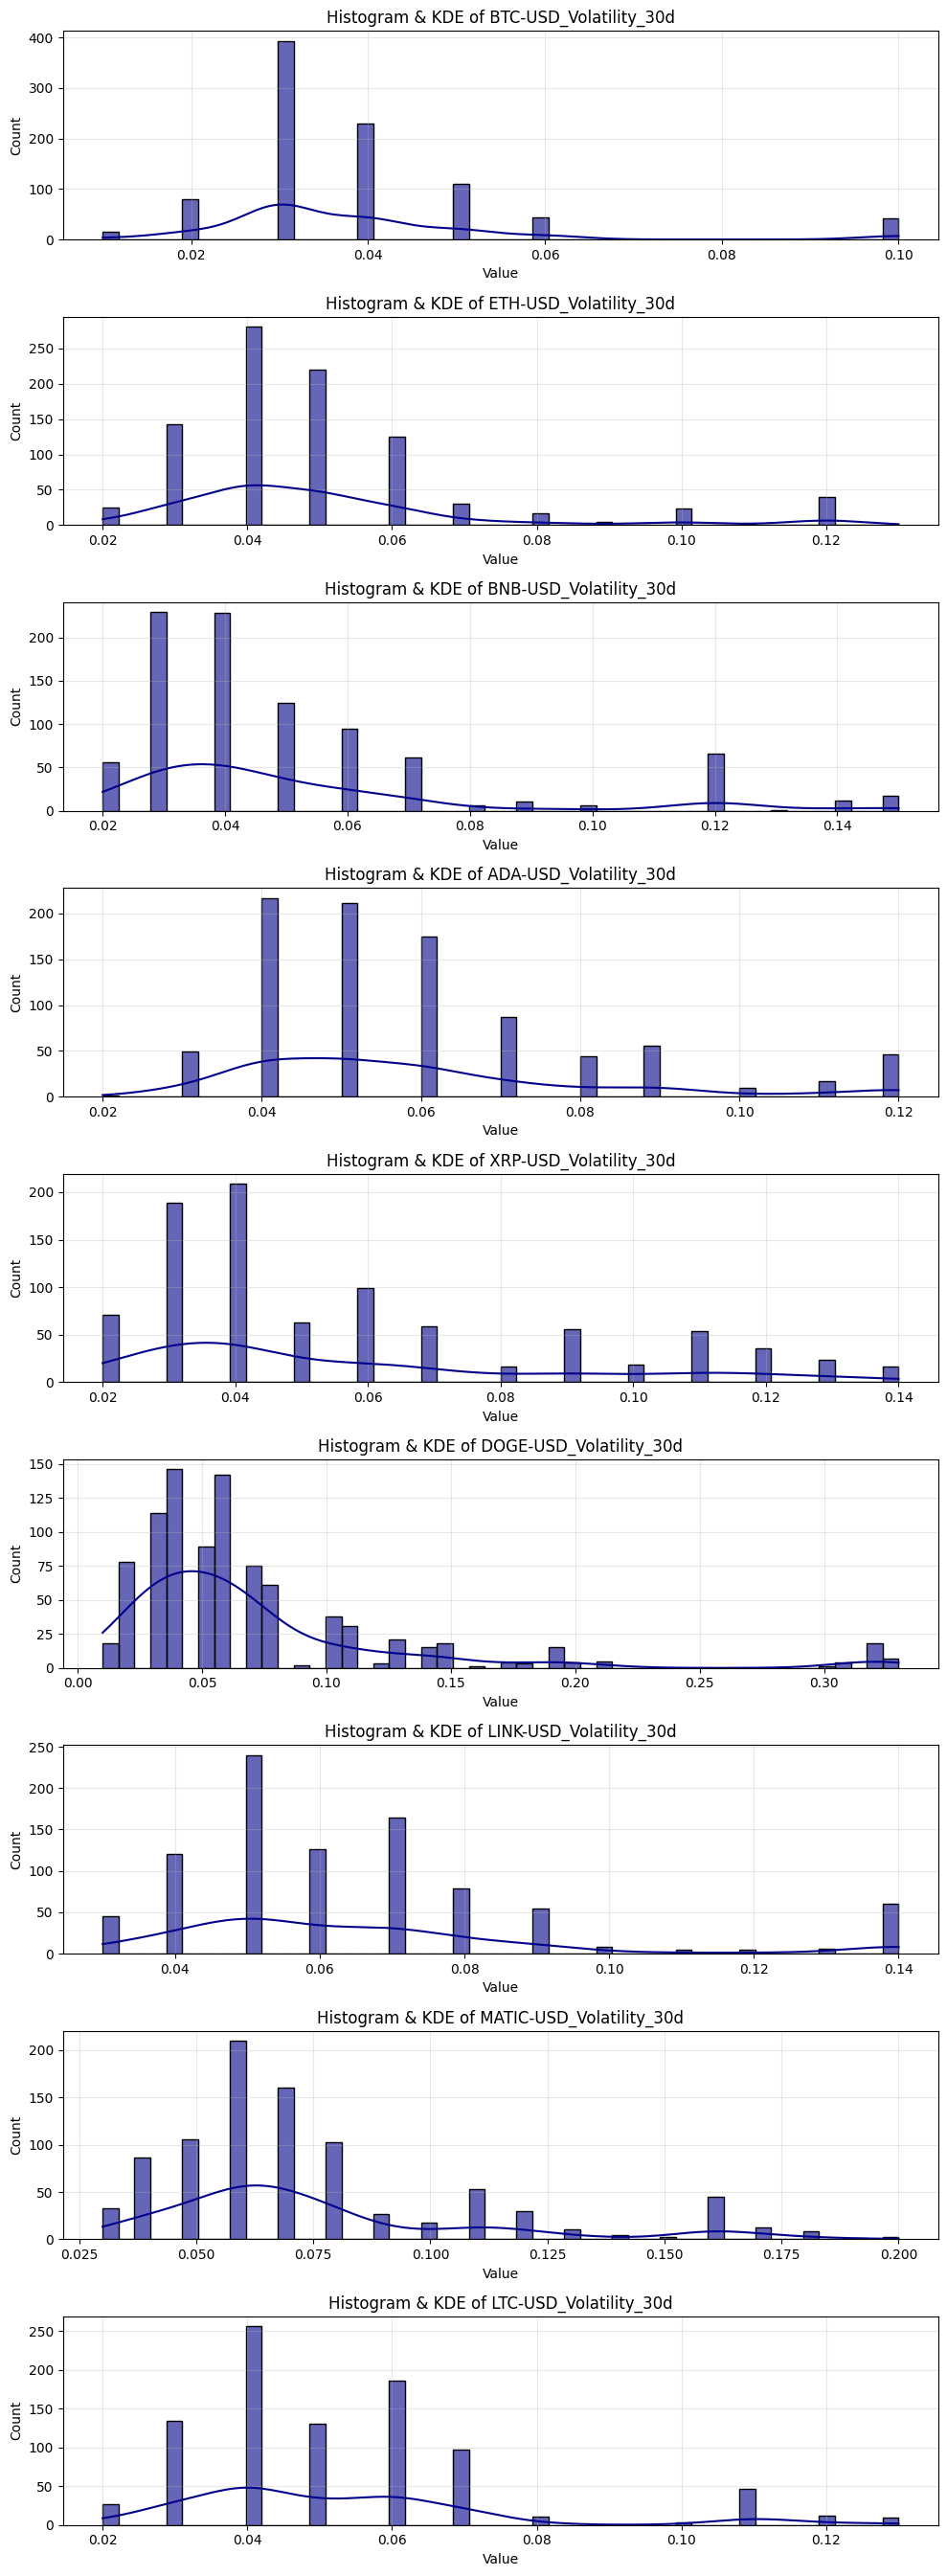

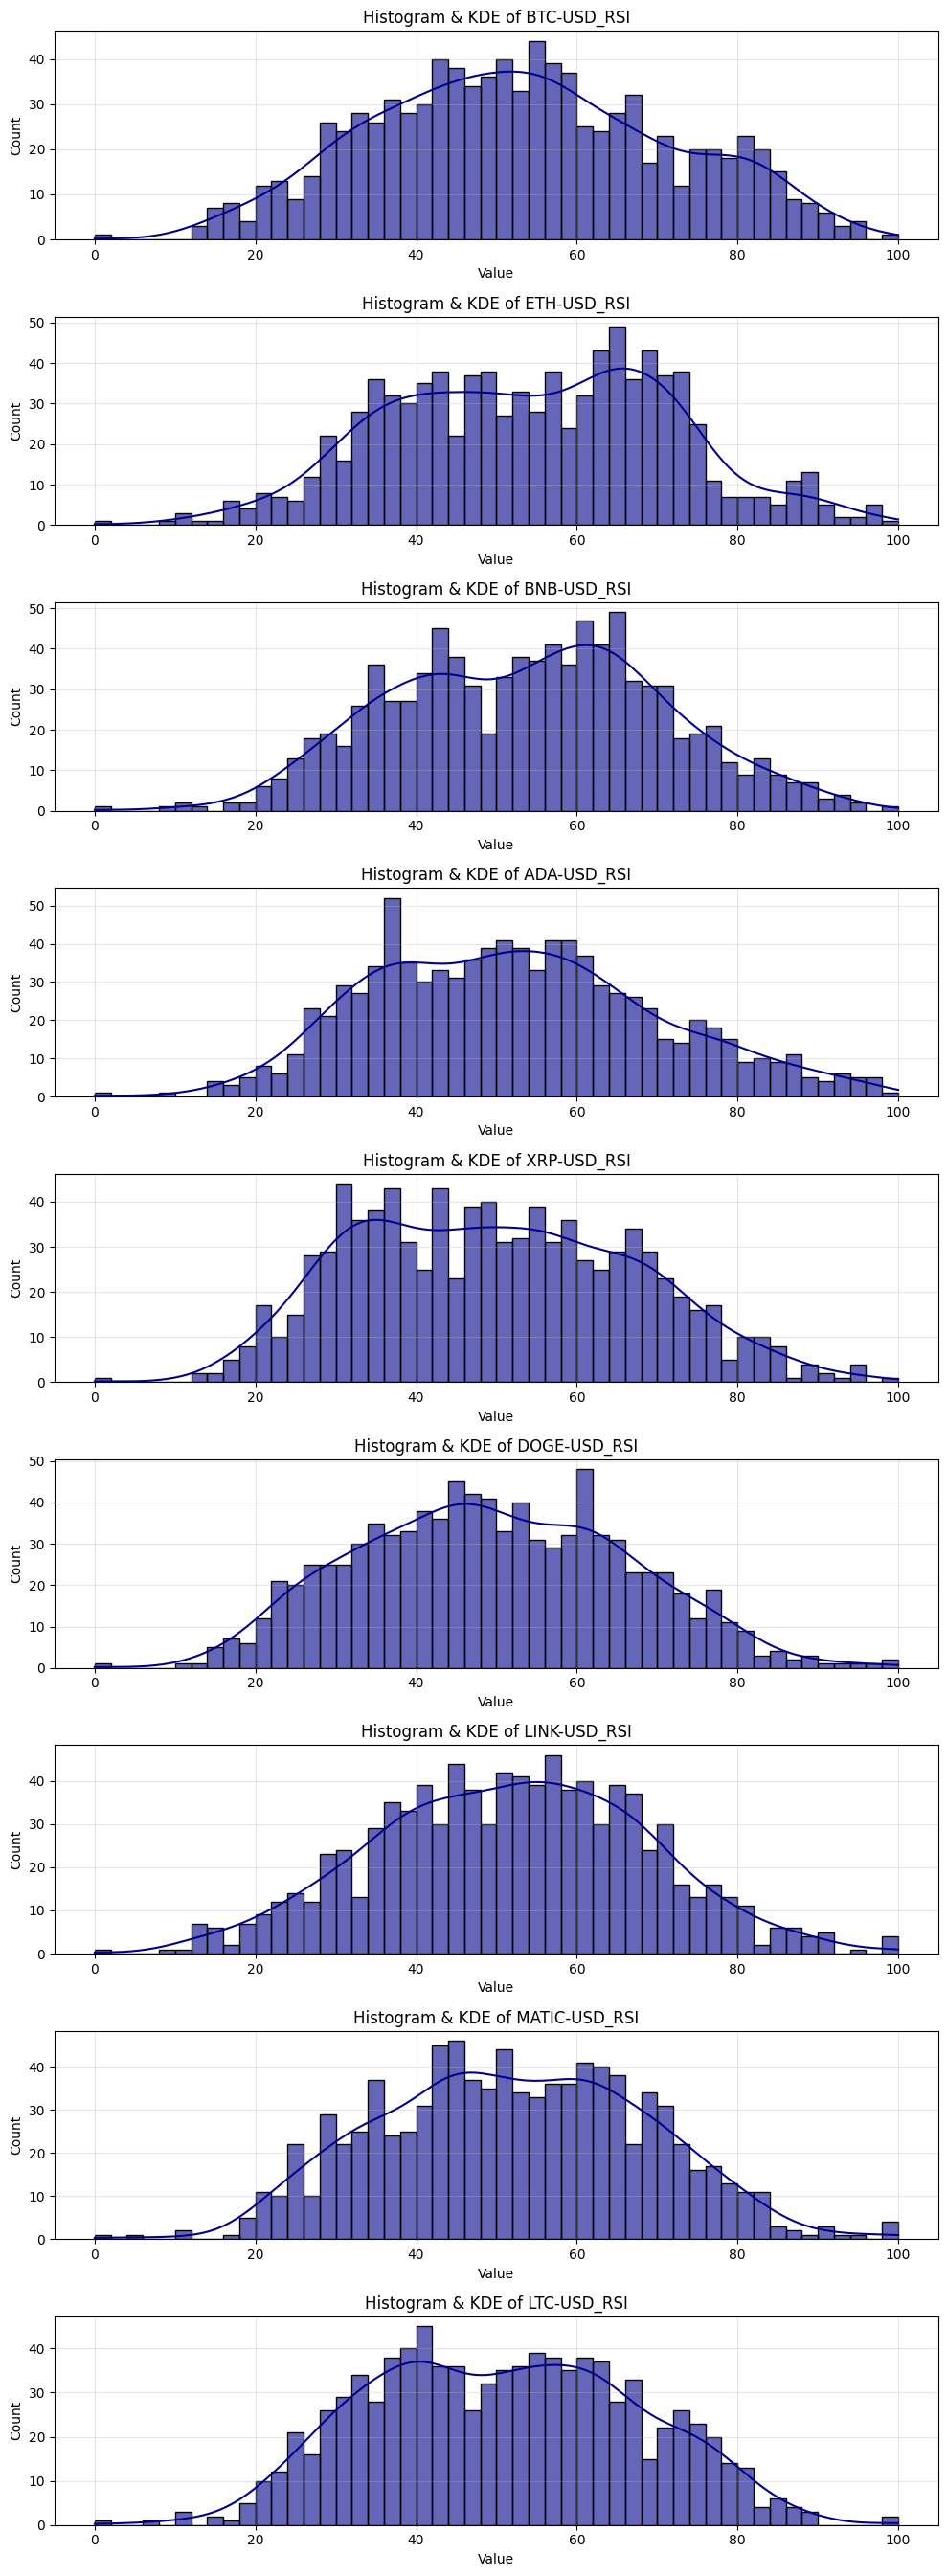

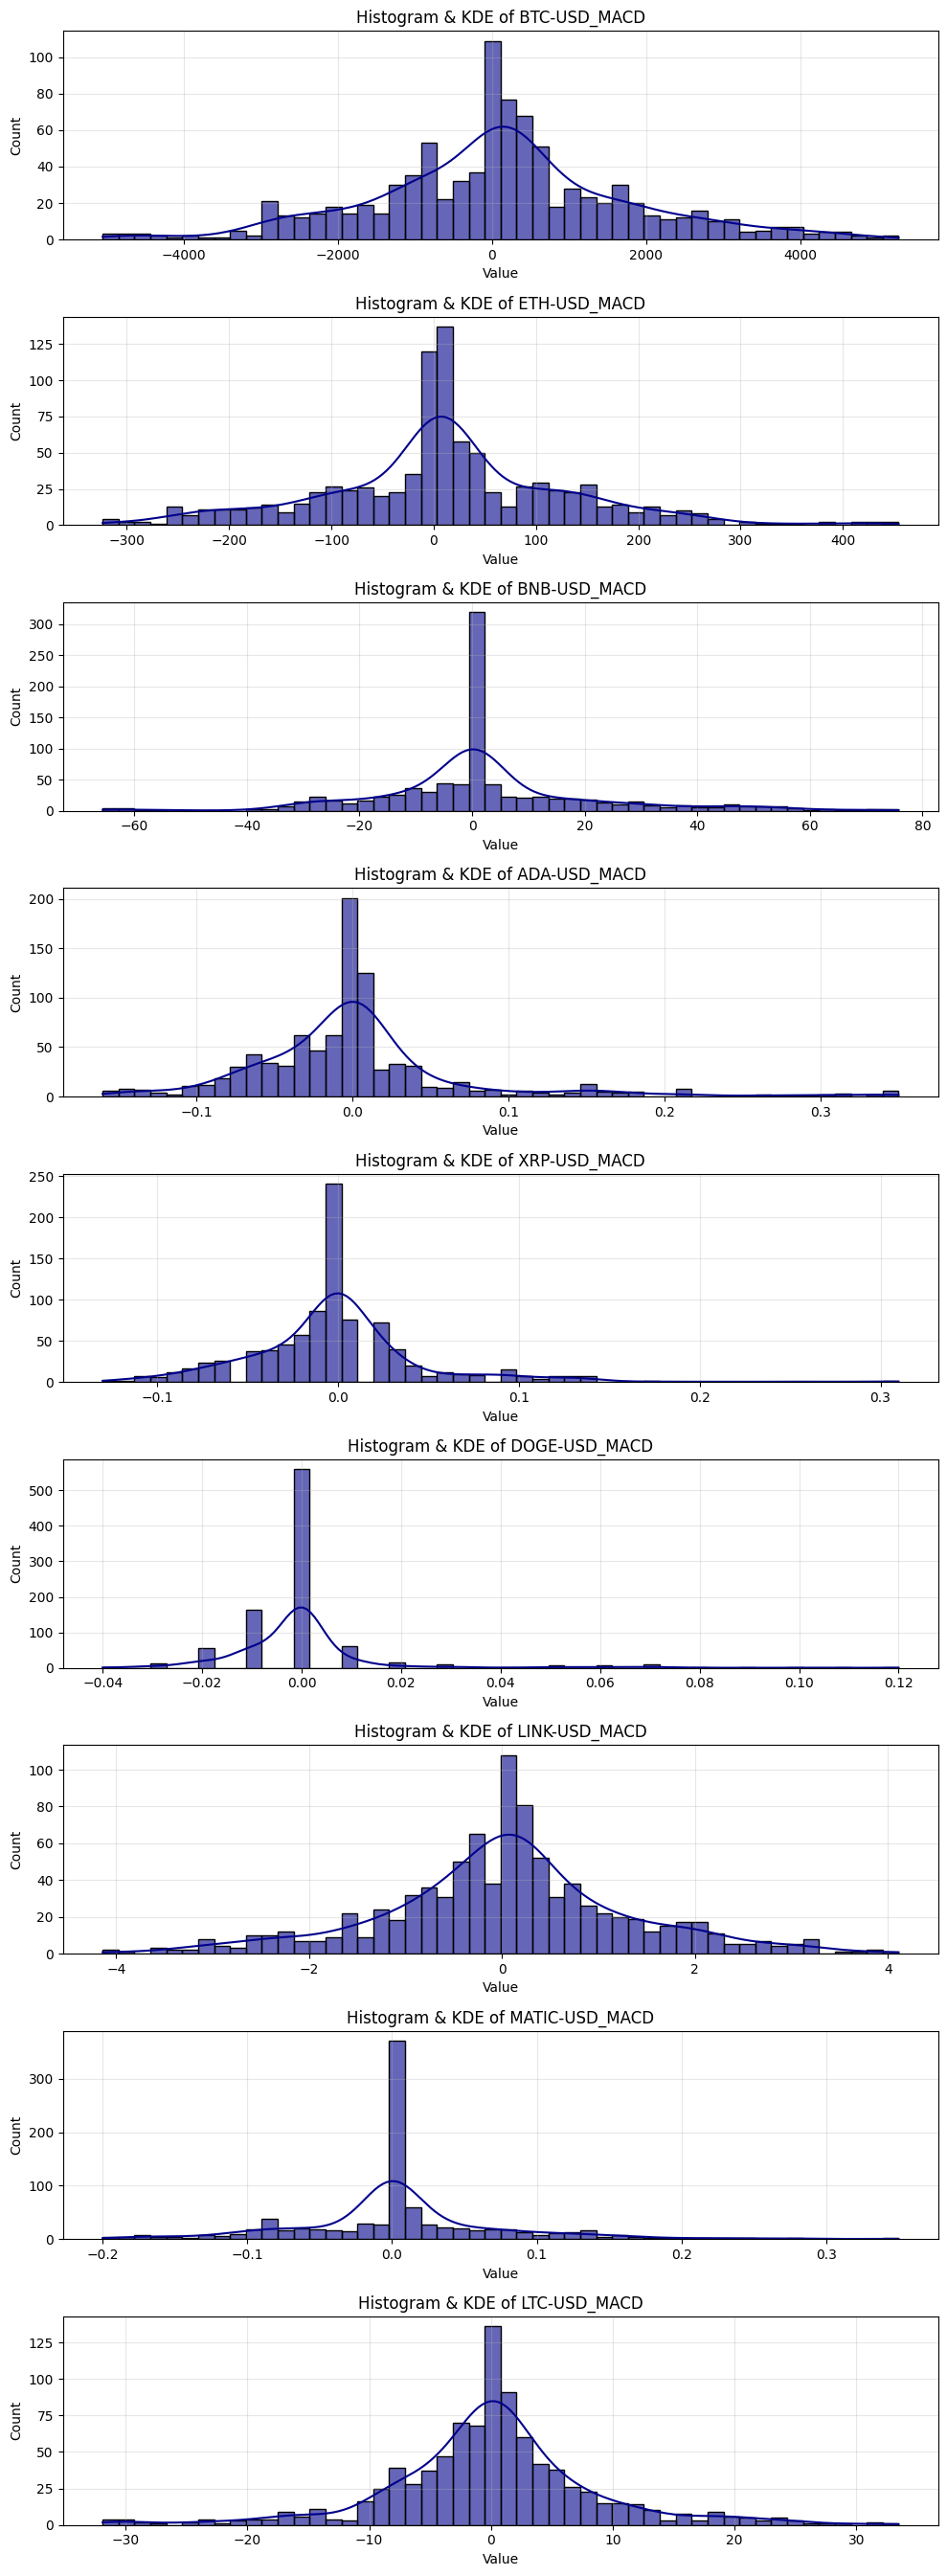

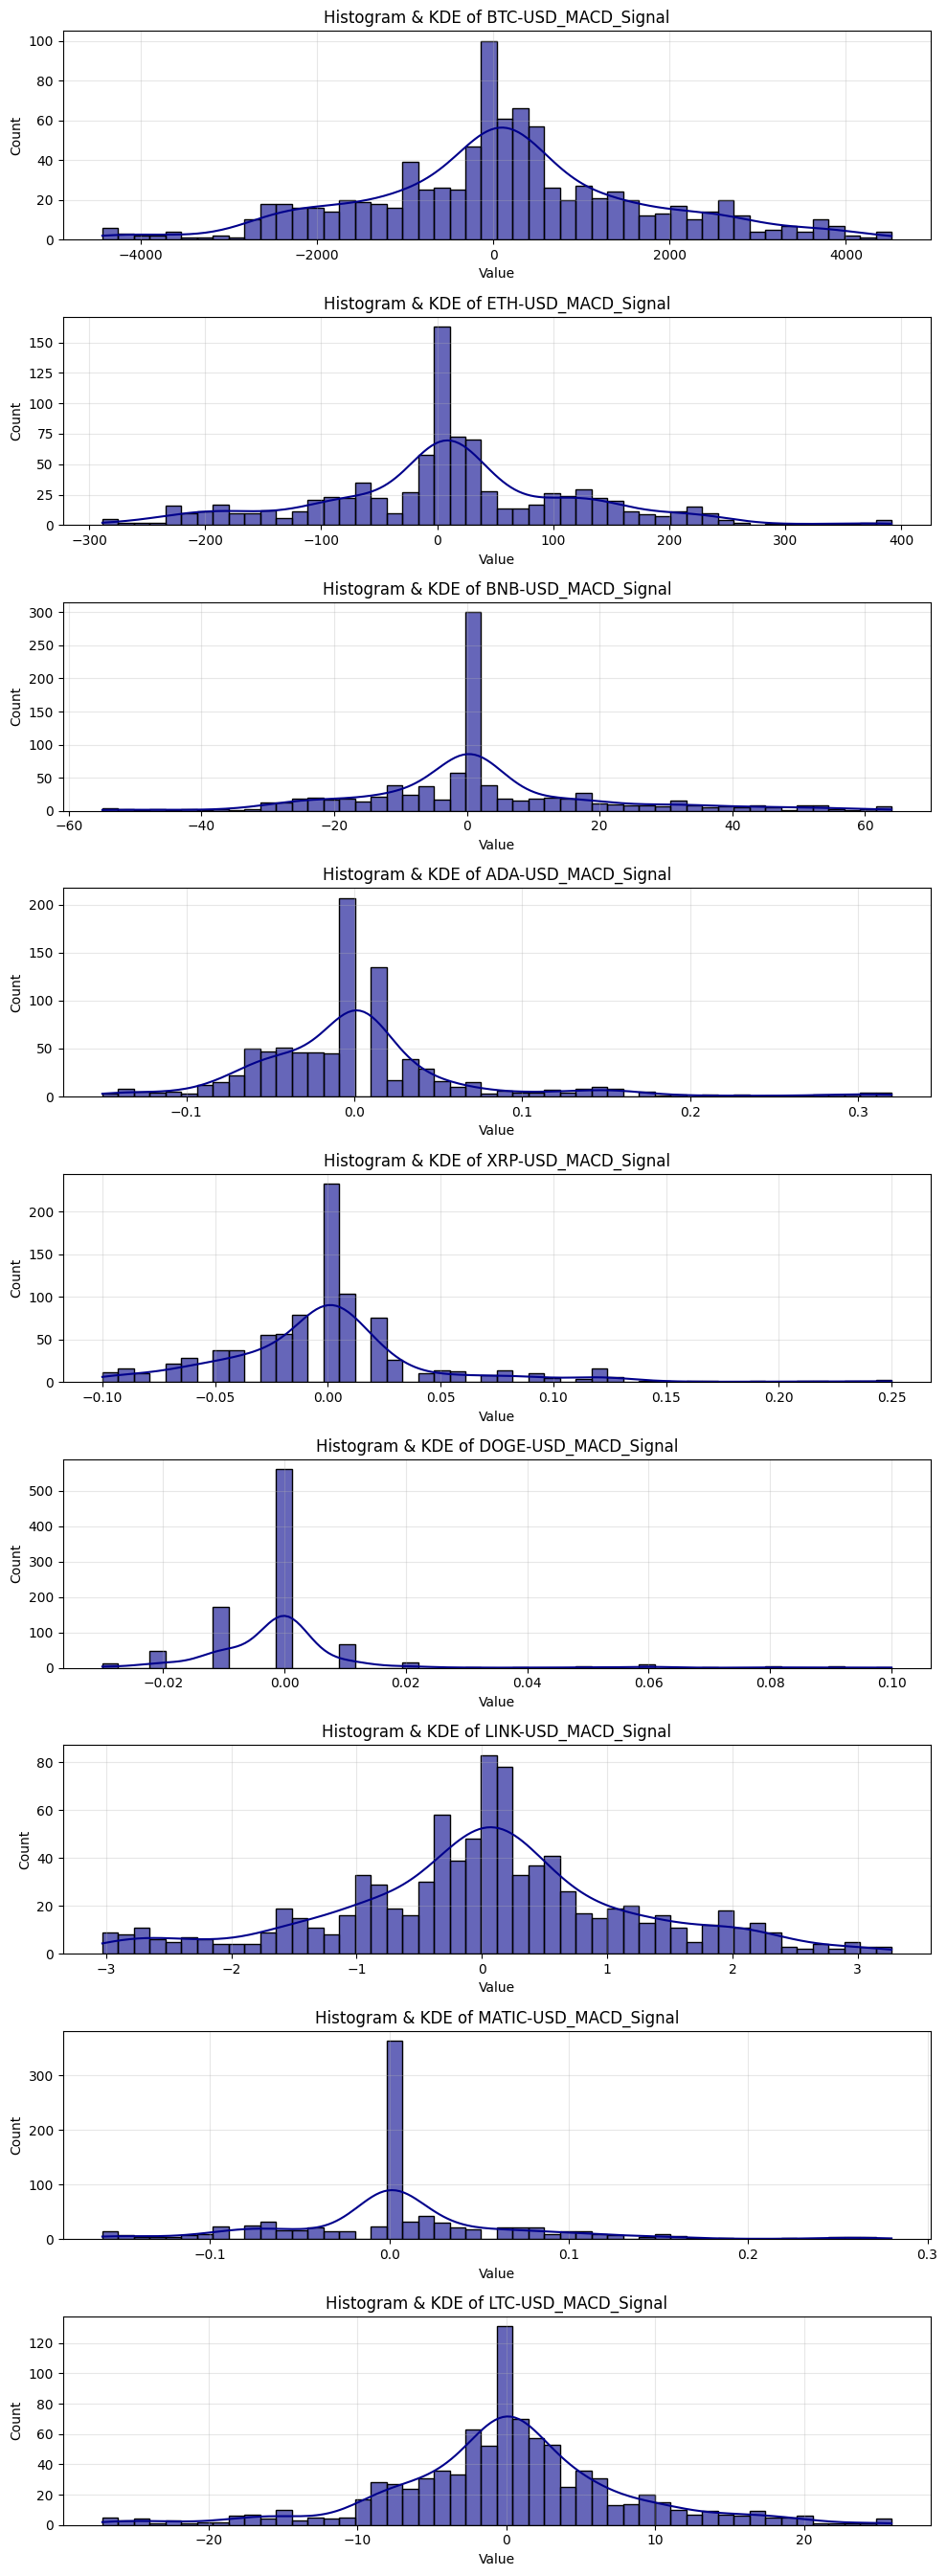


✅ **Dynamic Feature Grouping & Visualization Completed!**


In [15]:
############################### AUTO-DETECT FEATURE GROUPS ###############################
# Identify Unique Feature Groups Based on Column Names
feature_groups = {}
for col in df_selected.columns:
    # Extract feature type (assumes naming convention "{crypto}_{feature}")
    feature_type = col.split("_", 1)[-1]  # Everything after the first "_"

    # Add to dictionary
    if feature_type not in feature_groups:
        feature_groups[feature_type] = []
    feature_groups[feature_type].append(col)

############################### BOXPLOTS: DYNAMICALLY GROUPED FEATURES ###############################

# Function to Plot Boxplots
def plot_boxplot(feature_list, title):
    if not feature_list:
        print(f"⚠ No data available for {title}. Skipping...")
        return

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_selected[feature_list], showfliers=True, width=0.7, palette="coolwarm")
    plt.yscale("log")  # Log scale for better visualization
    plt.title(f" {title}", fontsize=14)
    plt.ylabel("Value")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.show()

# Generate Boxplots for Each Feature Group
for group_name, feature_list in feature_groups.items():
    plot_boxplot(feature_list, f"Boxplot of {group_name}")

############################### HISTOGRAMS + KDE PLOTS ###############################

# Function to Plot Histograms & KDE
def plot_histogram(feature_list, title, color="blue"):
    if not feature_list:
        print(f"⚠ No data available for {title}. Skipping...")
        return

    fig, axes = plt.subplots(nrows=len(feature_list), ncols=1, figsize=(10, len(feature_list) * 3))

    for i, col in enumerate(feature_list):
        sns.histplot(df_selected[col], kde=True, bins=50, ax=axes[i], color=color, alpha=0.6)
        axes[i].set_title(f"Histogram & KDE of {col}", fontsize=12)
        axes[i].set_xlabel("Value")
        axes[i].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Generate Histograms for Each Feature Group
for group_name, feature_list in feature_groups.items():
    plot_histogram(feature_list, f"Histogram & KDE of {group_name}", color="darkblue")

print("\n✅ **Dynamic Feature Grouping & Visualization Completed!**")


### ***5.2.2 - Risk vs Return***

In [16]:
############################### COMPUTE MEAN & VOLATILITY ###############################
# Calculate Mean & Volatility (Standard Deviation)
returns_volatility = pd.DataFrame({
    "Mean Value": df_selected.mean(),
    "Volatility (Std Dev)": df_selected.std()
})

############################### AUTO-DETECT FEATURE GROUPS ###############################
feature_groups = {}
for col in df_selected.columns:
    # Extract feature type dynamically
    feature_type = col.split("_", 1)[-1]  # Everything after first "_"

    # Add to dictionary
    if feature_type not in feature_groups:
        feature_groups[feature_type] = []
    feature_groups[feature_type].append(col)

############################### SCATTER PLOTS: RISK VS RETURN ###############################

# Function to Generate Scatter Plots
def plot_scatter(feature_list, title):
    if not feature_list:
        print(f"⚠ No data available for {title}. Skipping...")
        return

    subset_df = returns_volatility.loc[feature_list]  # Filter relevant features

    fig = px.scatter(
        subset_df,
        x="Volatility (Std Dev)",
        y="Mean Value",
        text=subset_df.index,
        size_max=15,
        color=subset_df.index,
        title=title
    )

    fig.update_traces(textposition='top center')
    fig.update_layout(xaxis_title="Volatility (Std Dev)", yaxis_title="Mean Value")
    fig.show()

# Generate Scatter Plots for Each Feature Group (Including BTC & ETH)
print("\n **Generating Scatter Plots for All Cryptos (Including BTC & ETH)...**")
for group_name, feature_list in feature_groups.items():
    plot_scatter(feature_list, f"Risk vs. Return: {group_name} (All Cryptos)")

############################### EXCLUDE BITCOIN & ETHEREUM & REPEAT PLOTS ###############################

# Filter Out BTC & ETH Features
btc_eth_features = [col for col in df_selected.columns if col.startswith(("bitcoin", "ethereum"))]
df_selected_no_btc_eth = df_selected.drop(columns=btc_eth_features)

# Recompute Mean & Volatility for Altcoins Only
returns_volatility_no_btc_eth = pd.DataFrame({
    "Mean Value": df_selected_no_btc_eth.mean(),
    "Volatility (Std Dev)": df_selected_no_btc_eth.std()
})

# Recreate Feature Groups Without BTC & ETH
feature_groups_no_btc_eth = {}
for col in df_selected_no_btc_eth.columns:
    feature_type = col.split("_", 1)[-1]  # Extract feature type
    if feature_type not in feature_groups_no_btc_eth:
        feature_groups_no_btc_eth[feature_type] = []
    feature_groups_no_btc_eth[feature_type].append(col)

# Generate Scatter Plots Again (Without BTC & ETH)
print("\n **Generating Scatter Plots for Altcoins Only (Excluding BTC & ETH)...**")
for group_name, feature_list in feature_groups_no_btc_eth.items():
    plot_scatter(feature_list, f"Risk vs. Return: {group_name} (Excluding BTC & ETH)")

print("\n✅ **Dynamic Scatter Plots Completed!**")



 **Generating Scatter Plots for All Cryptos (Including BTC & ETH)...**



 **Generating Scatter Plots for Altcoins Only (Excluding BTC & ETH)...**



✅ **Dynamic Scatter Plots Completed!**


### ***5.2.3 - Line Plots of All Features***


 **Plotting All Cryptos Before Removing BTC & ETH...**


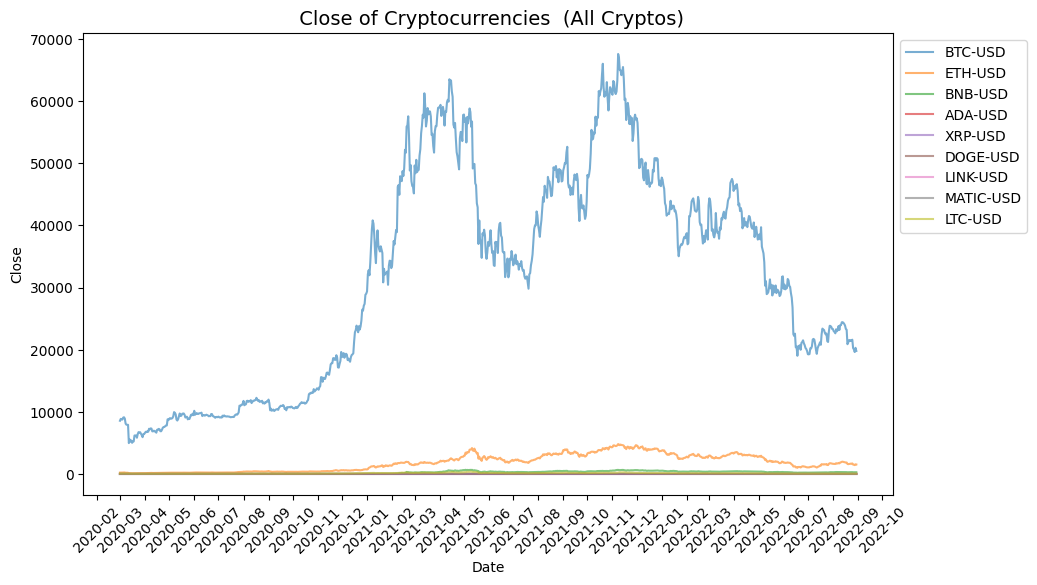

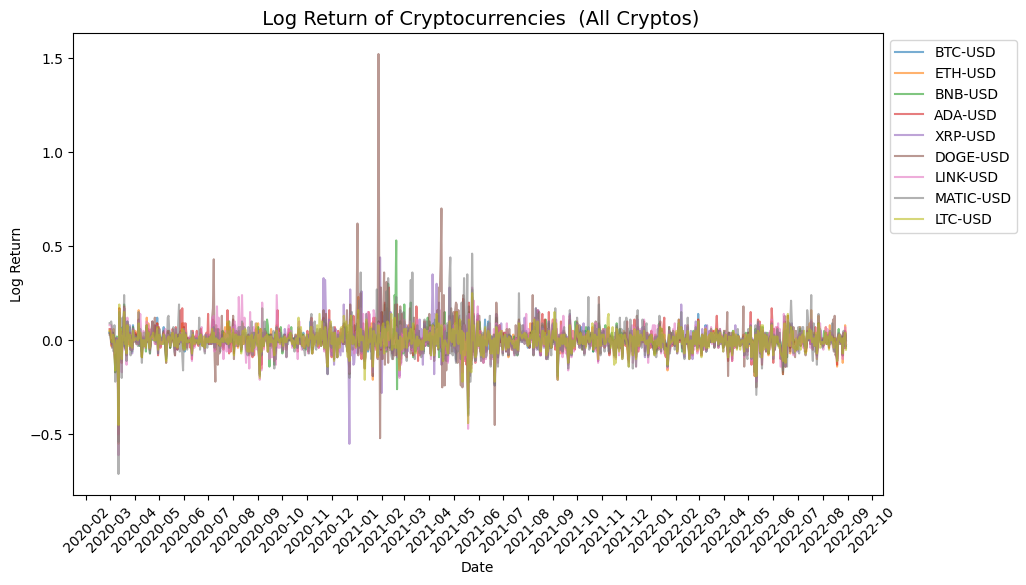

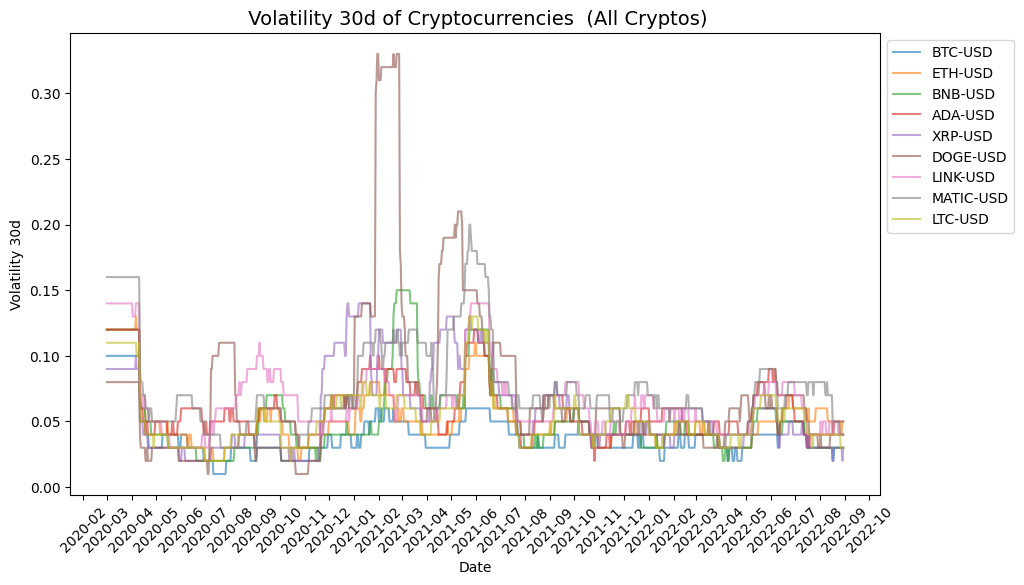

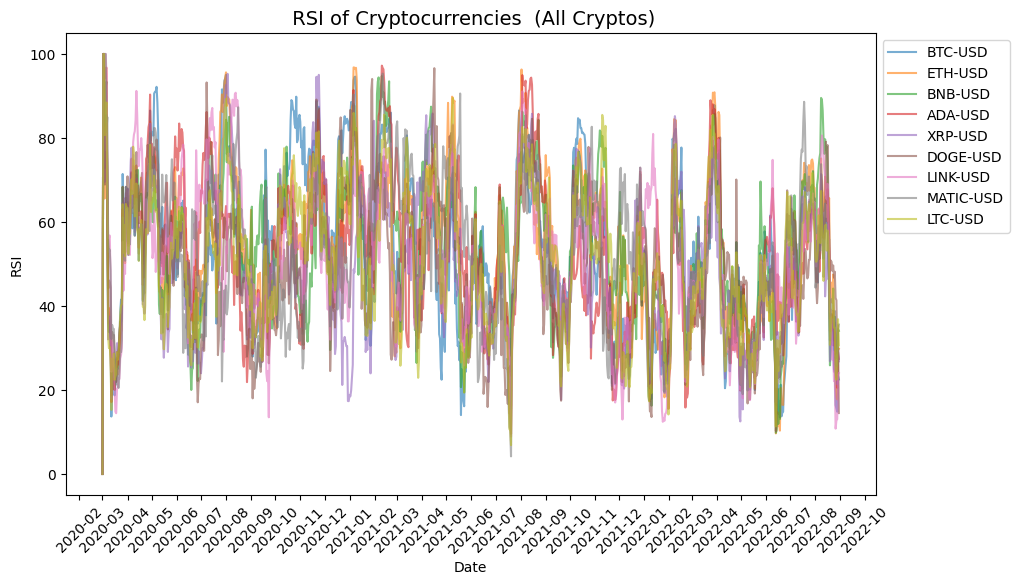

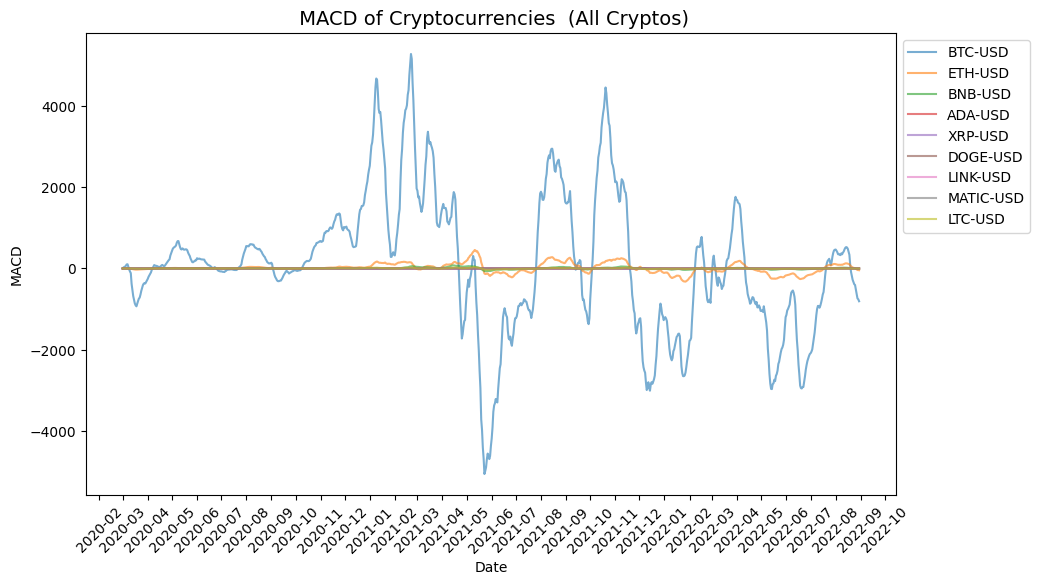

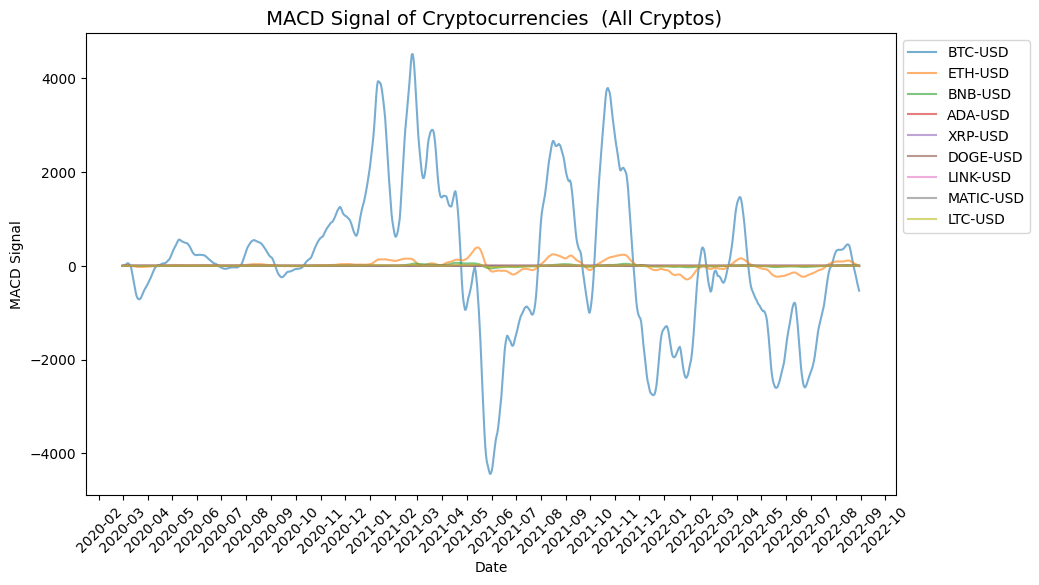


🚫 **Plotting Cryptos AFTER Removing BTC & ETH...**


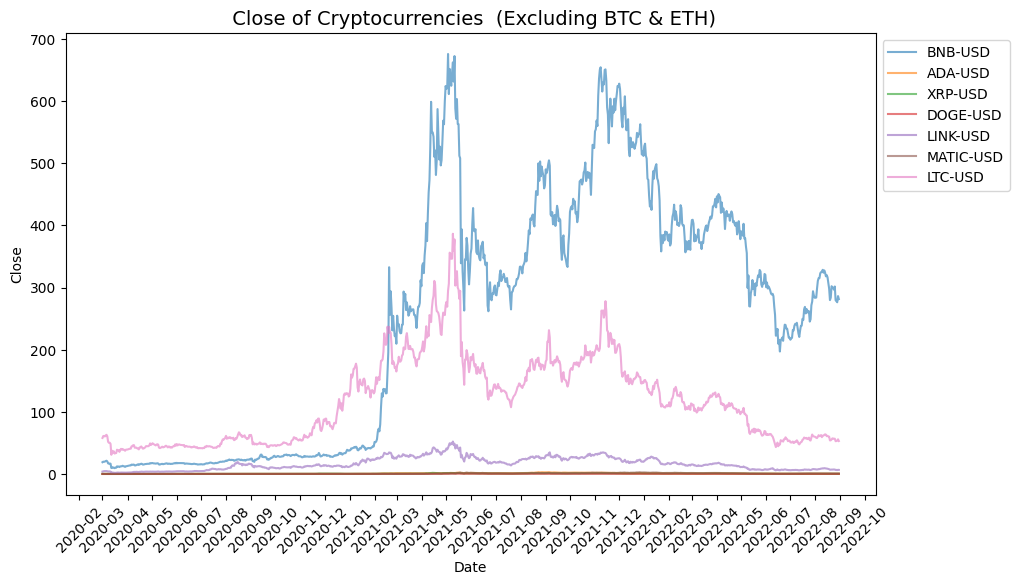

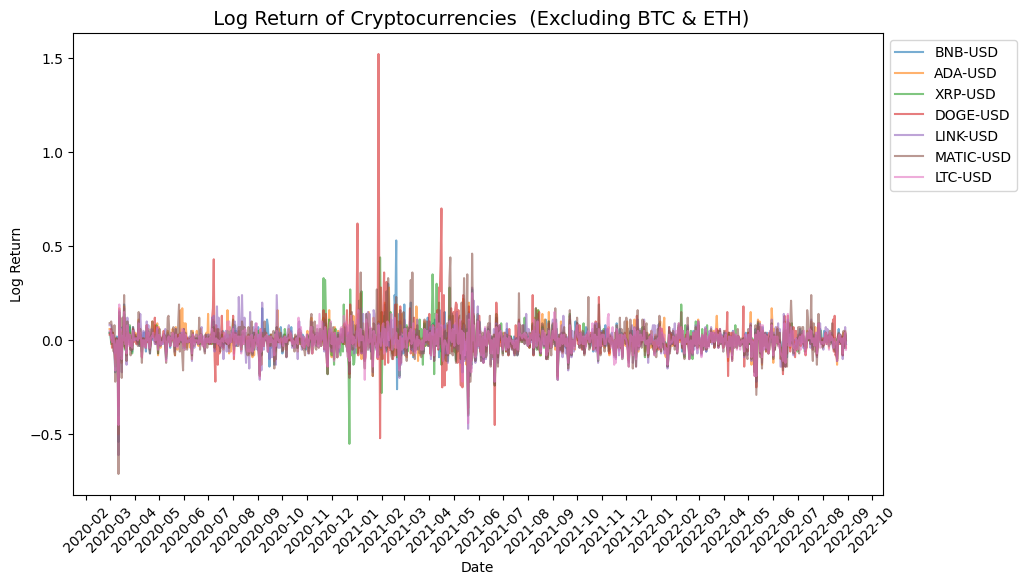

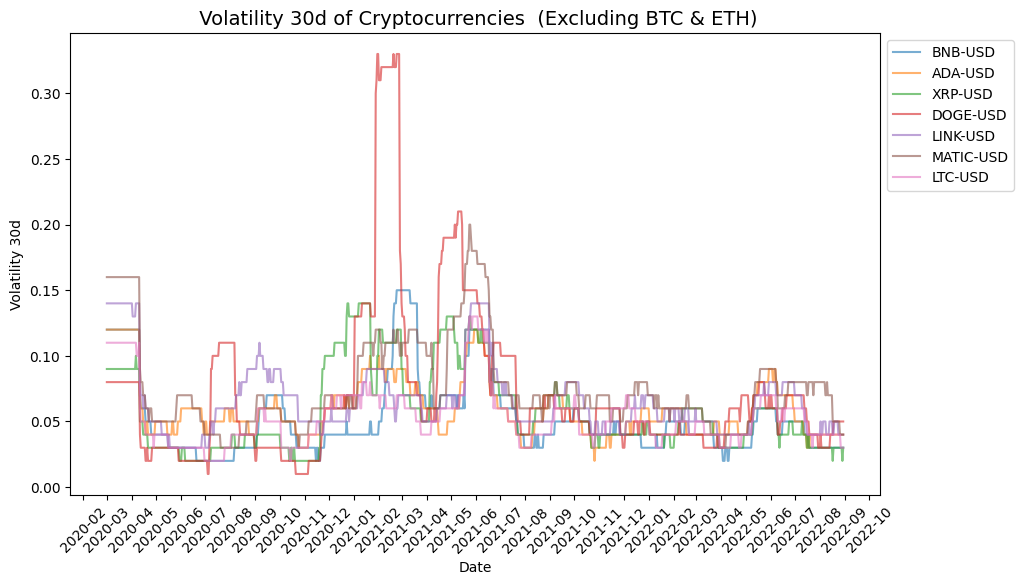

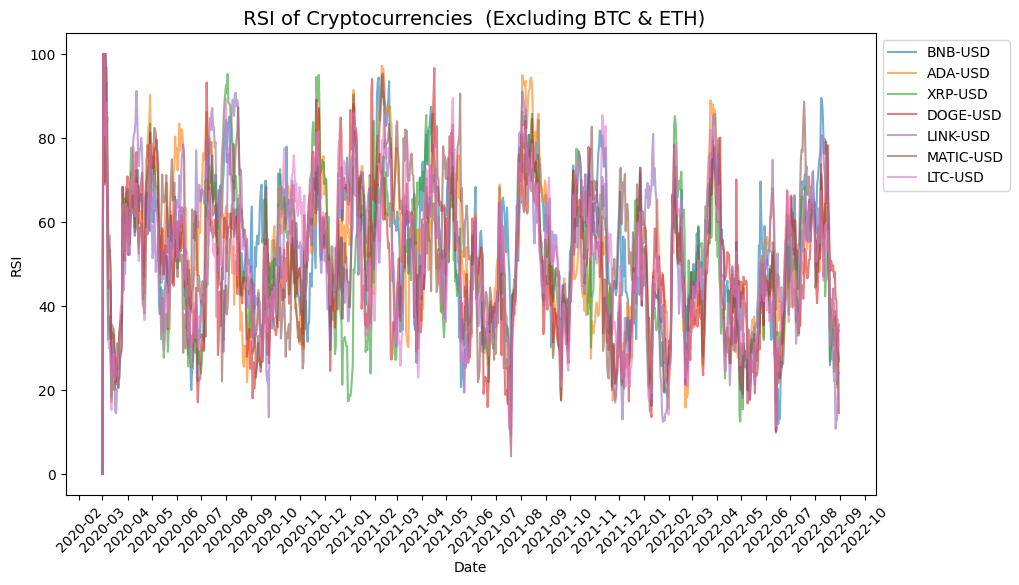

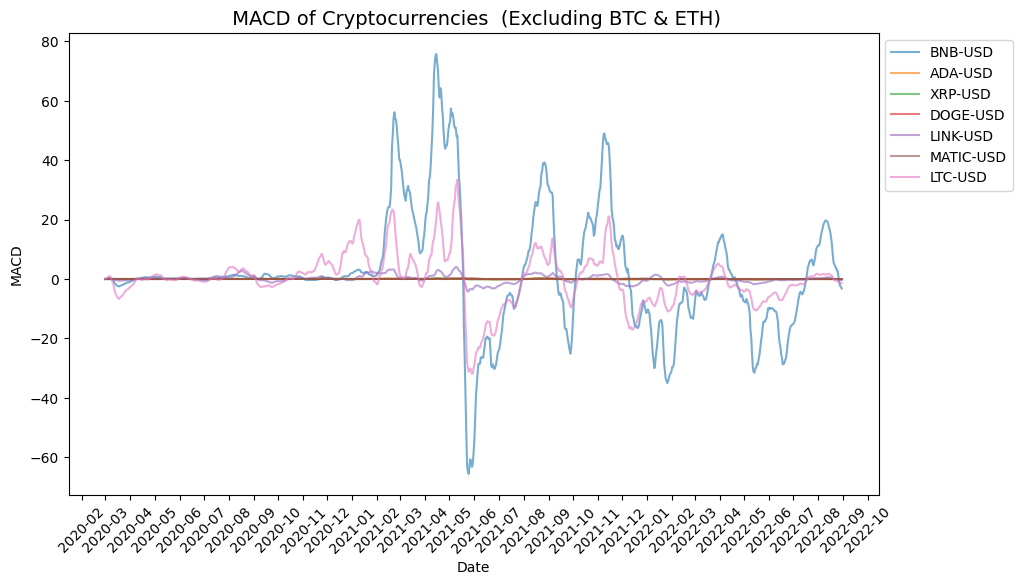

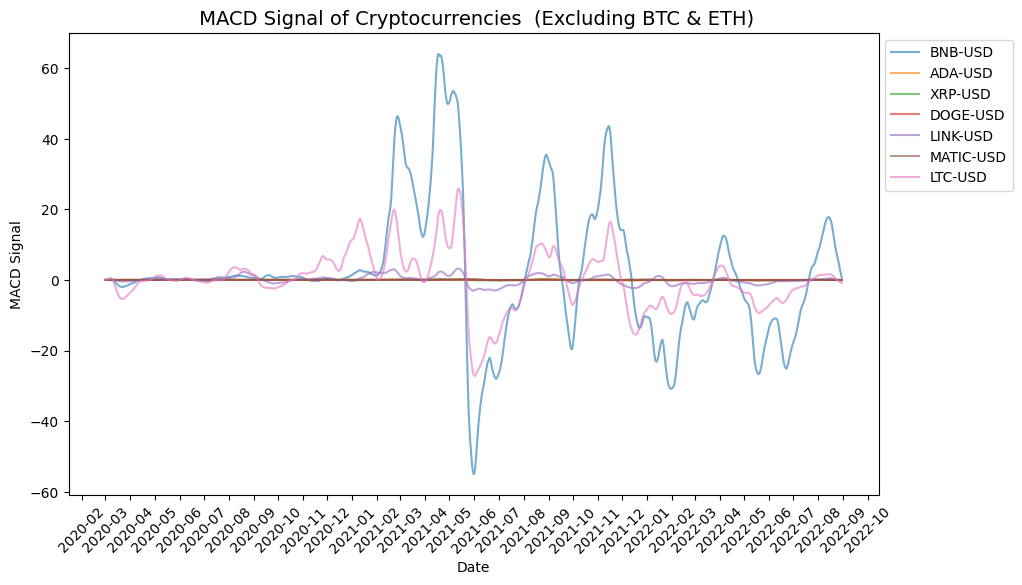


✅ **Comparison Completed!**


In [17]:
############################### HELPER FUNCTION TO FORMAT DATES ###############################
# Formate date
def format_date_axis(ax):
    """Formats date axis for better readability."""
    ax.xaxis.set_major_locator(mdates.MonthLocator())  # Show one tick per month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format as "YYYY-MM"
    plt.xticks(rotation=45)

############################### DYNAMIC FEATURE GROUPING ###############################
# Extract feature groups dynamically from `df_selected`
def extract_group(feature_name):
    """Extracts the feature type dynamically from {crypto}_{feature} format."""
    return feature_name.split("_", 1)[-1]  # Keeps everything after the first "_"

# Create feature group mapping
feature_groups = {}
for col in df_selected.columns:  # Ensure we are using the correct variable
    feature_type = extract_group(col)  # Extract dynamic feature type
    if feature_type not in feature_groups:
        feature_groups[feature_type] = []
    feature_groups[feature_type].append(col)

###############################  PLOT FUNCTION FOR GROUPED FEATURES ###############################
# Define grouped plot
def plot_grouped_features(group_name, feature_list, title_suffix=" (All Cryptos)"):
    """Plots all cryptocurrencies for a given feature group on the same axis."""
    fig, ax = plt.subplots(figsize=(12, 6))

    if not feature_list:
        print(f"⚠ No matching features for {group_name}. Skipping plot.")
        return

    for col in feature_list:
        crypto_name = col.split("_")[0]  # Extract the cryptocurrency name
        ax.plot(df_selected.index, df_selected[col], label=crypto_name, alpha=0.6)

    format_date_axis(ax)
    ax.set_title(f" {group_name.replace('_', ' ')} of Cryptocurrencies {title_suffix}", fontsize=14)
    ax.set_xlabel("Date")
    ax.set_ylabel(group_name.replace("_", " "))

    #  Move legend outside the plot
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.subplots_adjust(right=0.8)  # Adjust space for legend
    plt.show()

############################### PLOT BEFORE REMOVING BTC & ETH ###############################

print("\n **Plotting All Cryptos Before Removing BTC & ETH...**")
for group_name, feature_list in feature_groups.items():
    plot_grouped_features(group_name, feature_list)

############################### REMOVE BTC & ETH & PLOT AGAIN ###############################

# Remove BTC & ETH dynamically
df_selected_no_btc_eth = df_selected[[col for col in df_selected.columns if not col.startswith(("BTC", "ETH"))]]

# Extract updated feature groups dynamically
filtered_feature_groups = {}
for col in df_selected_no_btc_eth.columns:
    feature_type = extract_group(col)  # Extract dynamic feature type
    if feature_type not in filtered_feature_groups:
        filtered_feature_groups[feature_type] = []
    filtered_feature_groups[feature_type].append(col)

#  Generate plots AFTER removing BTC & ETH
print("\n🚫 **Plotting Cryptos AFTER Removing BTC & ETH...**")
for group_name, feature_list in filtered_feature_groups.items():
    plot_grouped_features(group_name, feature_list, title_suffix=" (Excluding BTC & ETH)")

print("\n✅ **Comparison Completed!**")


### ***5.2.4 - Histograms of All Features***

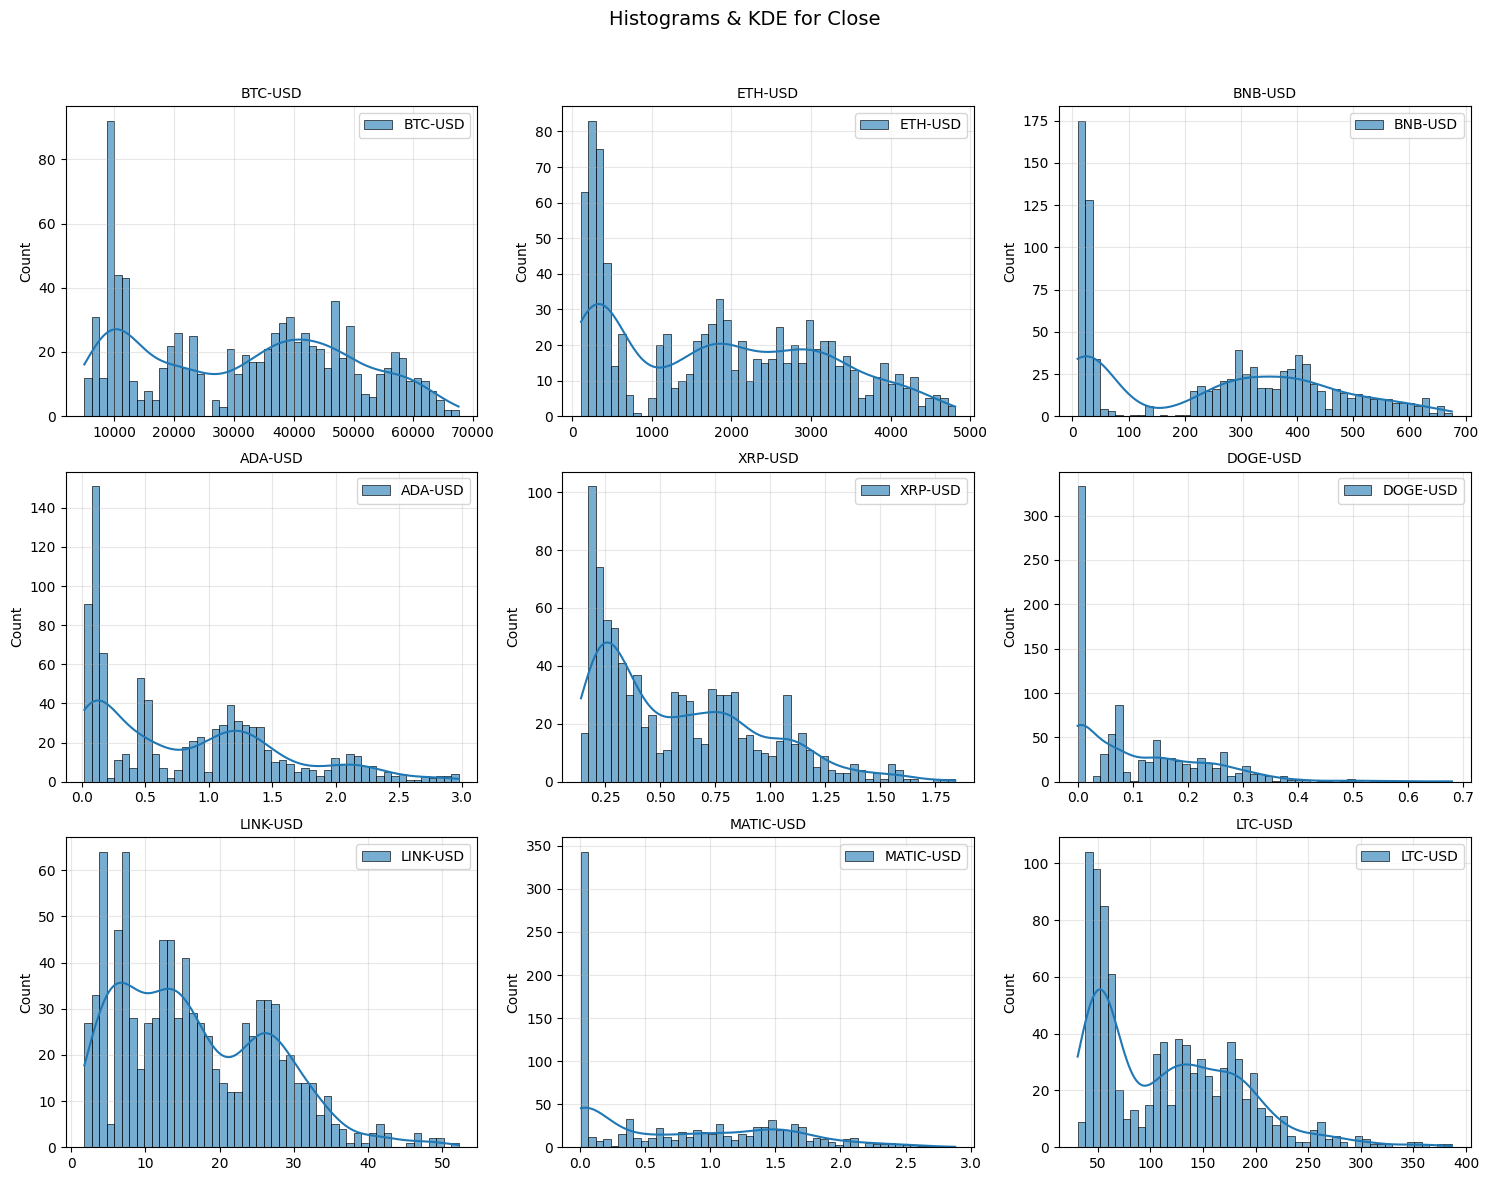

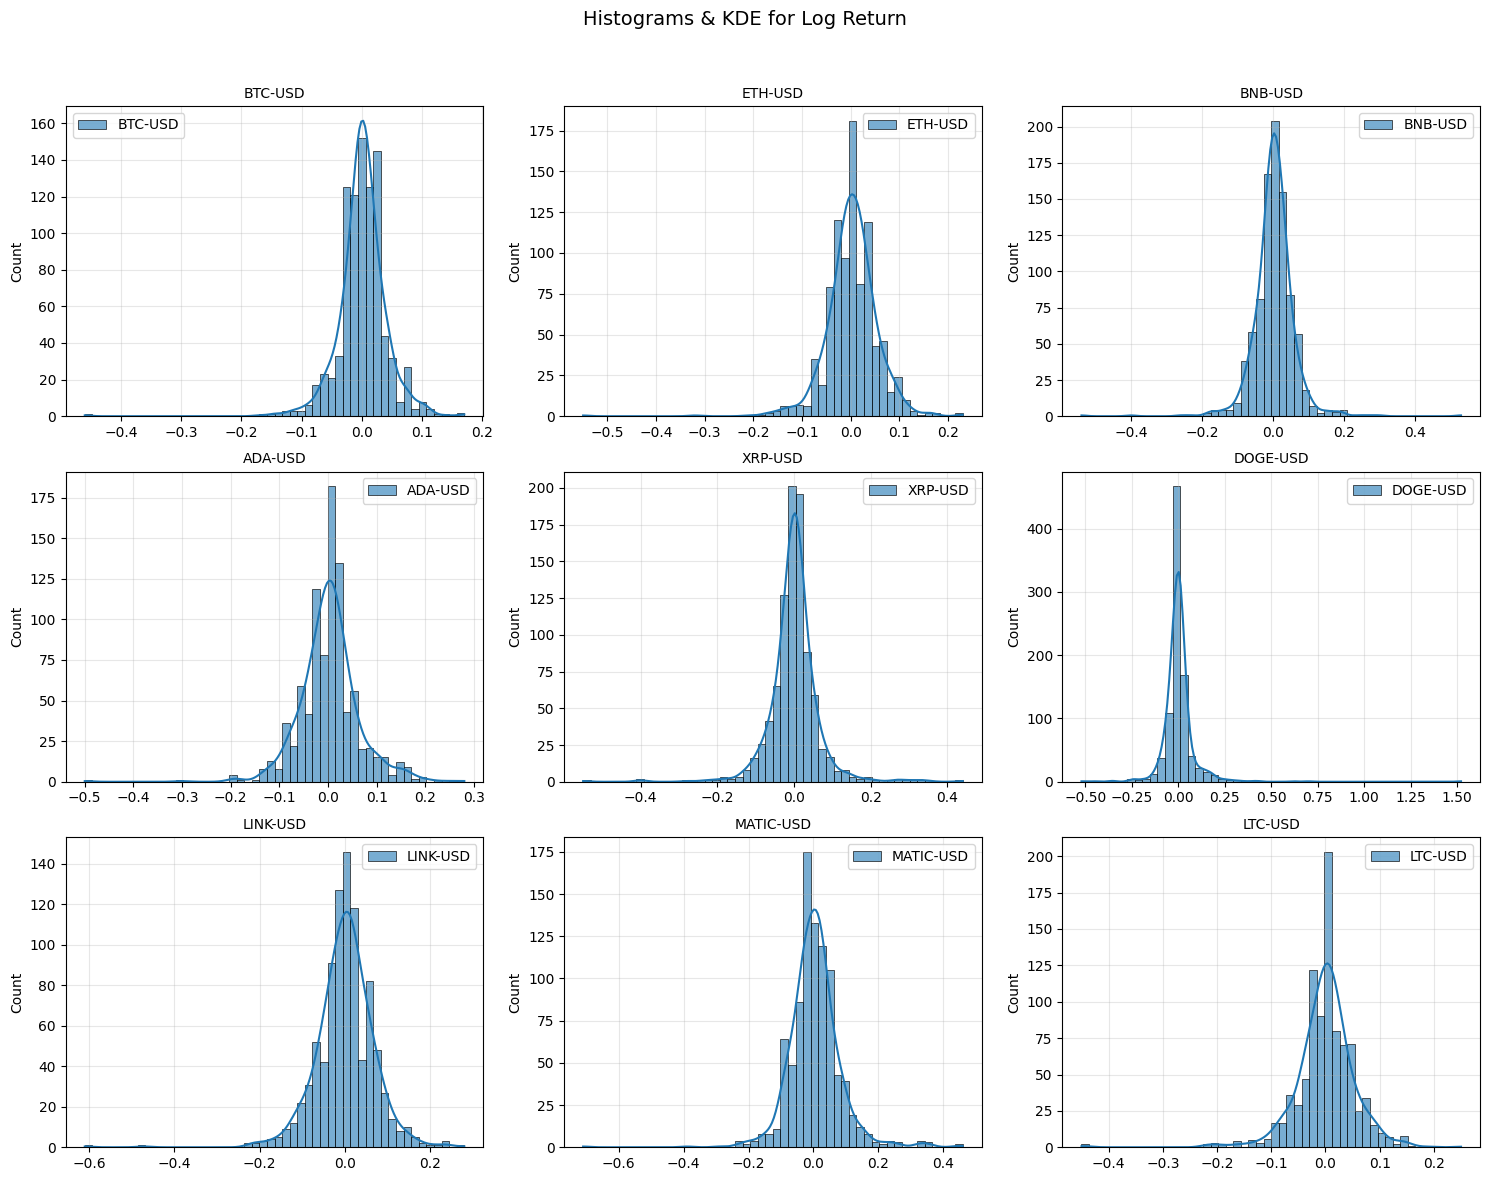

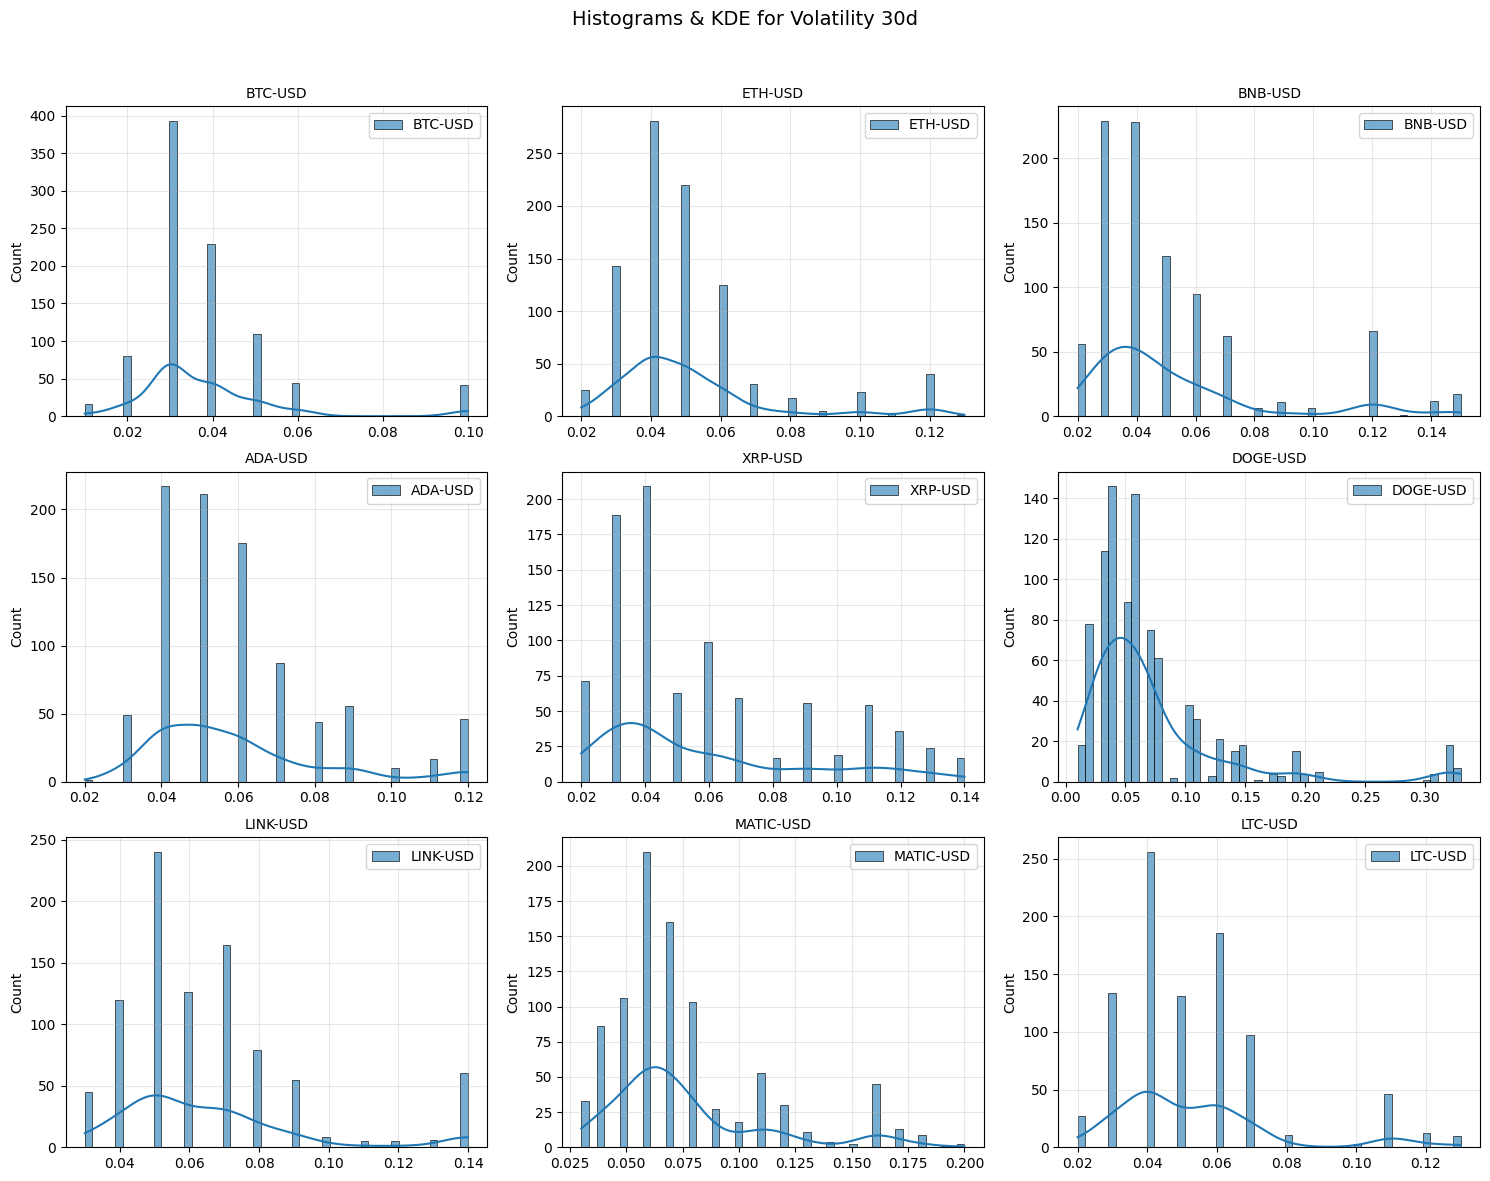

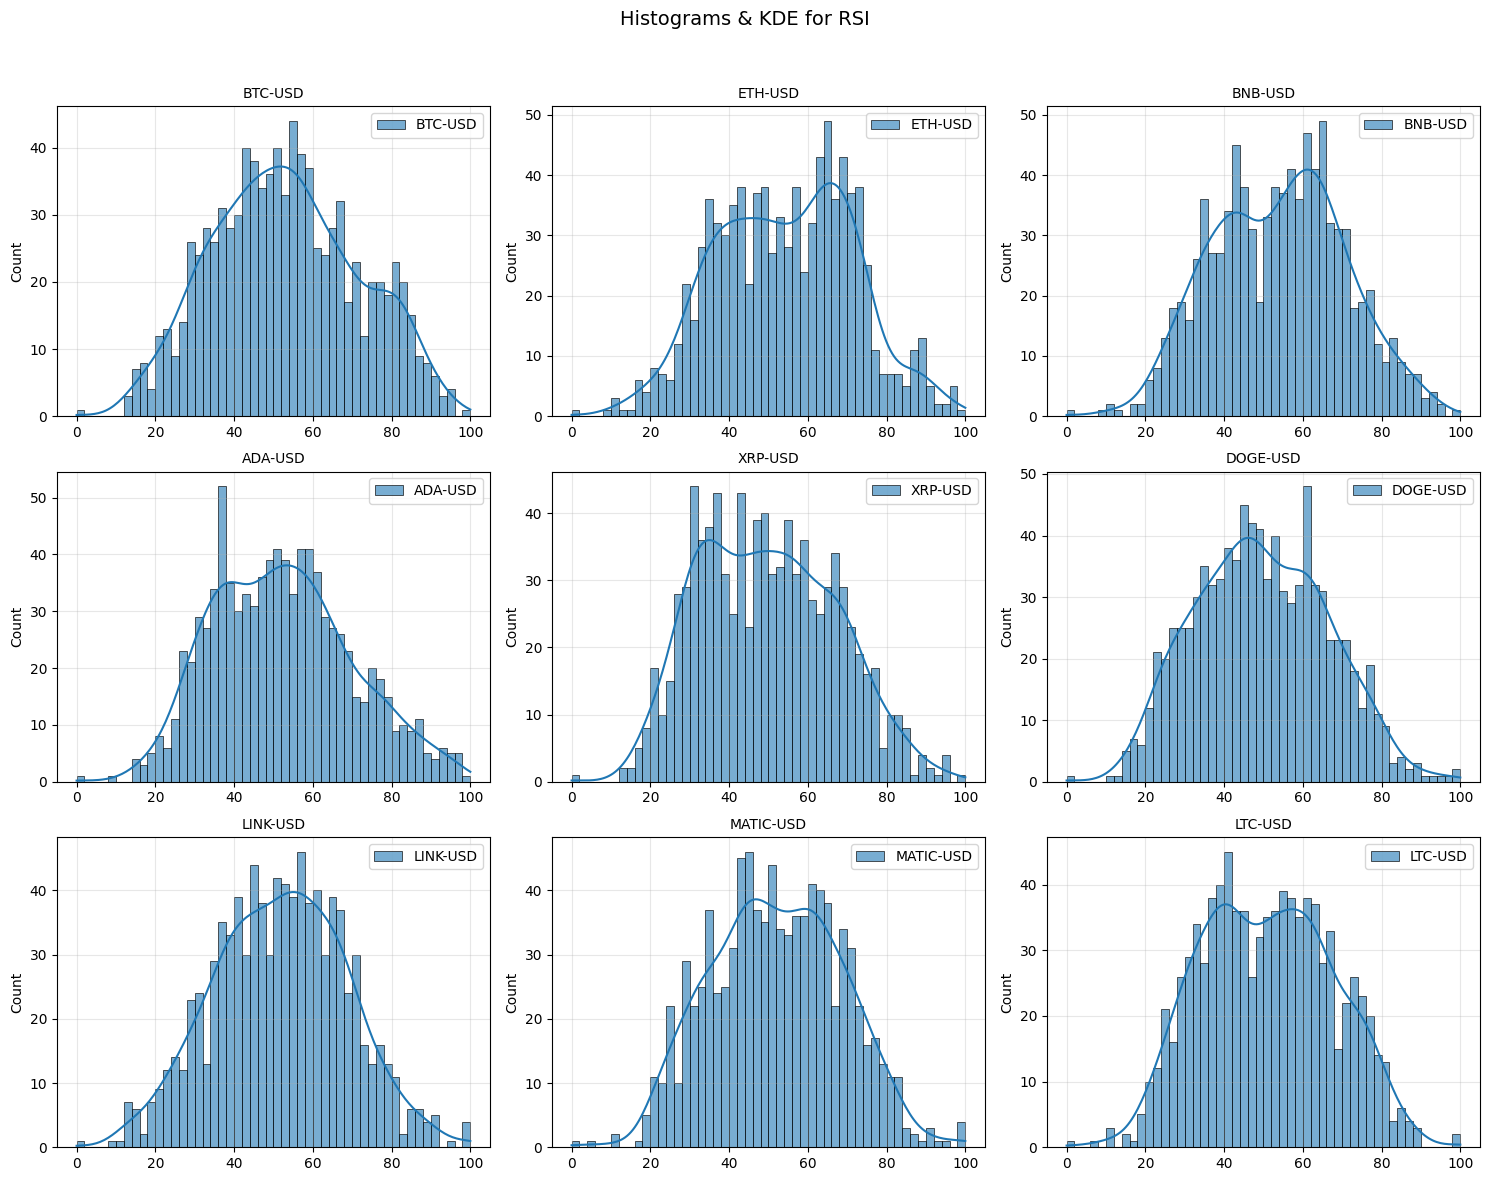

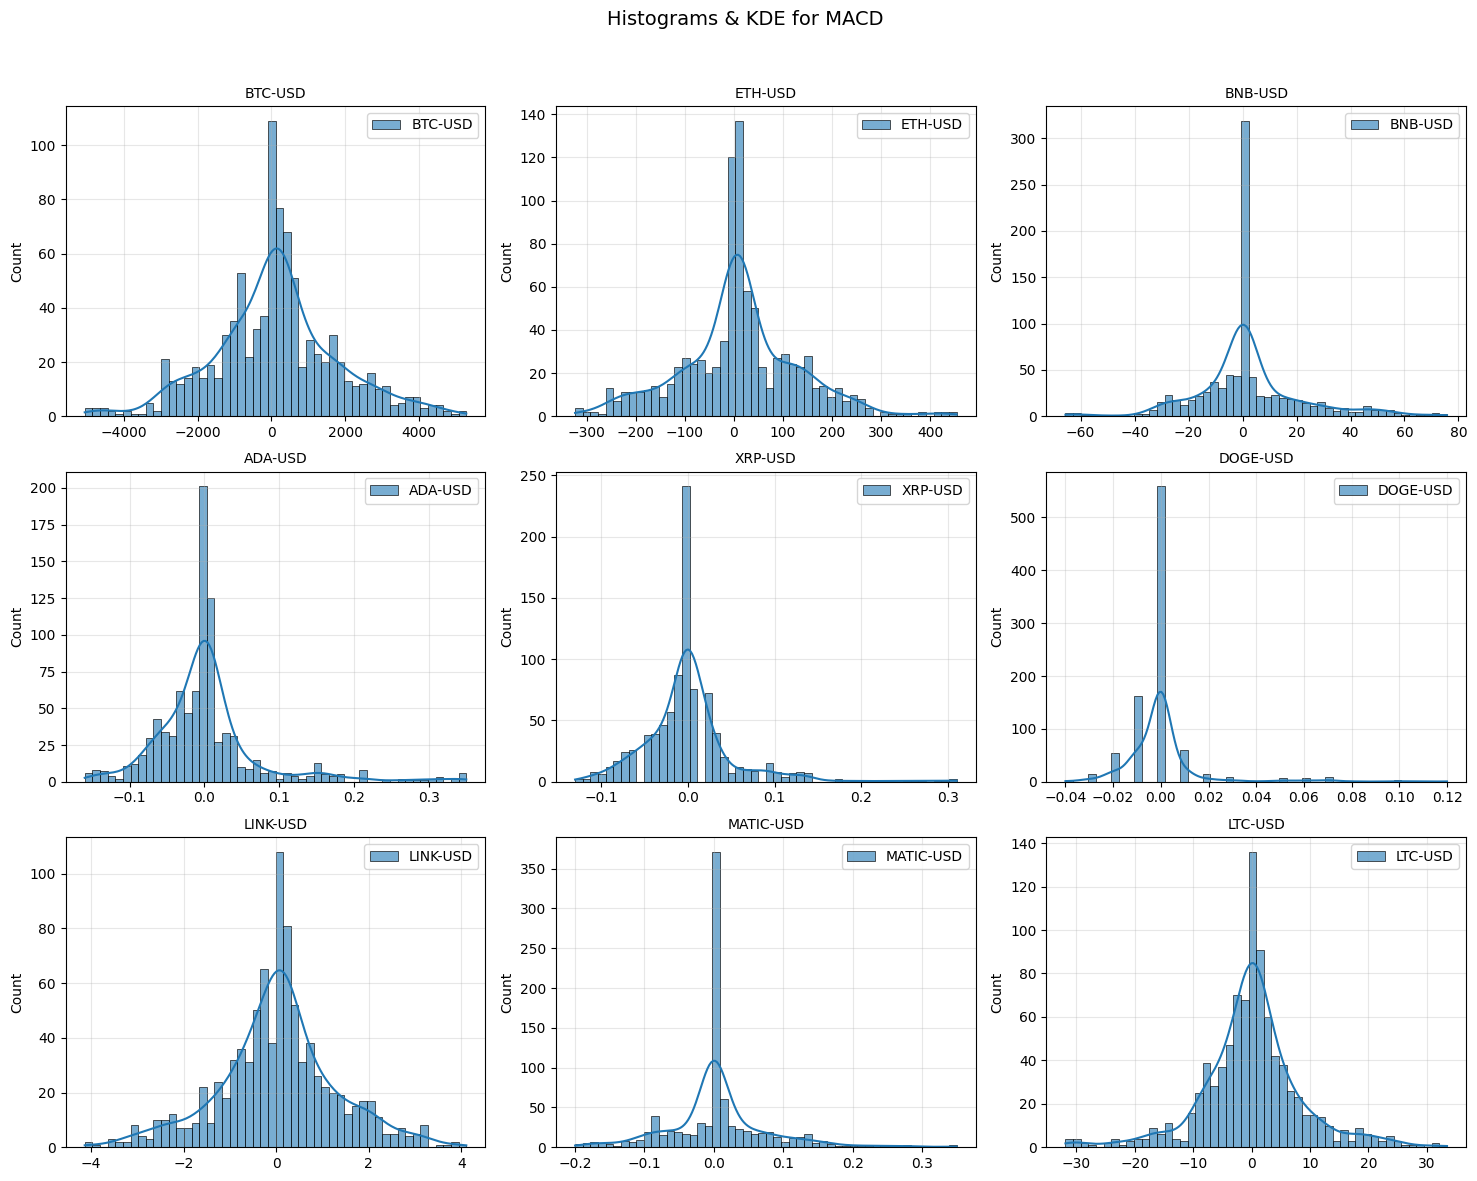

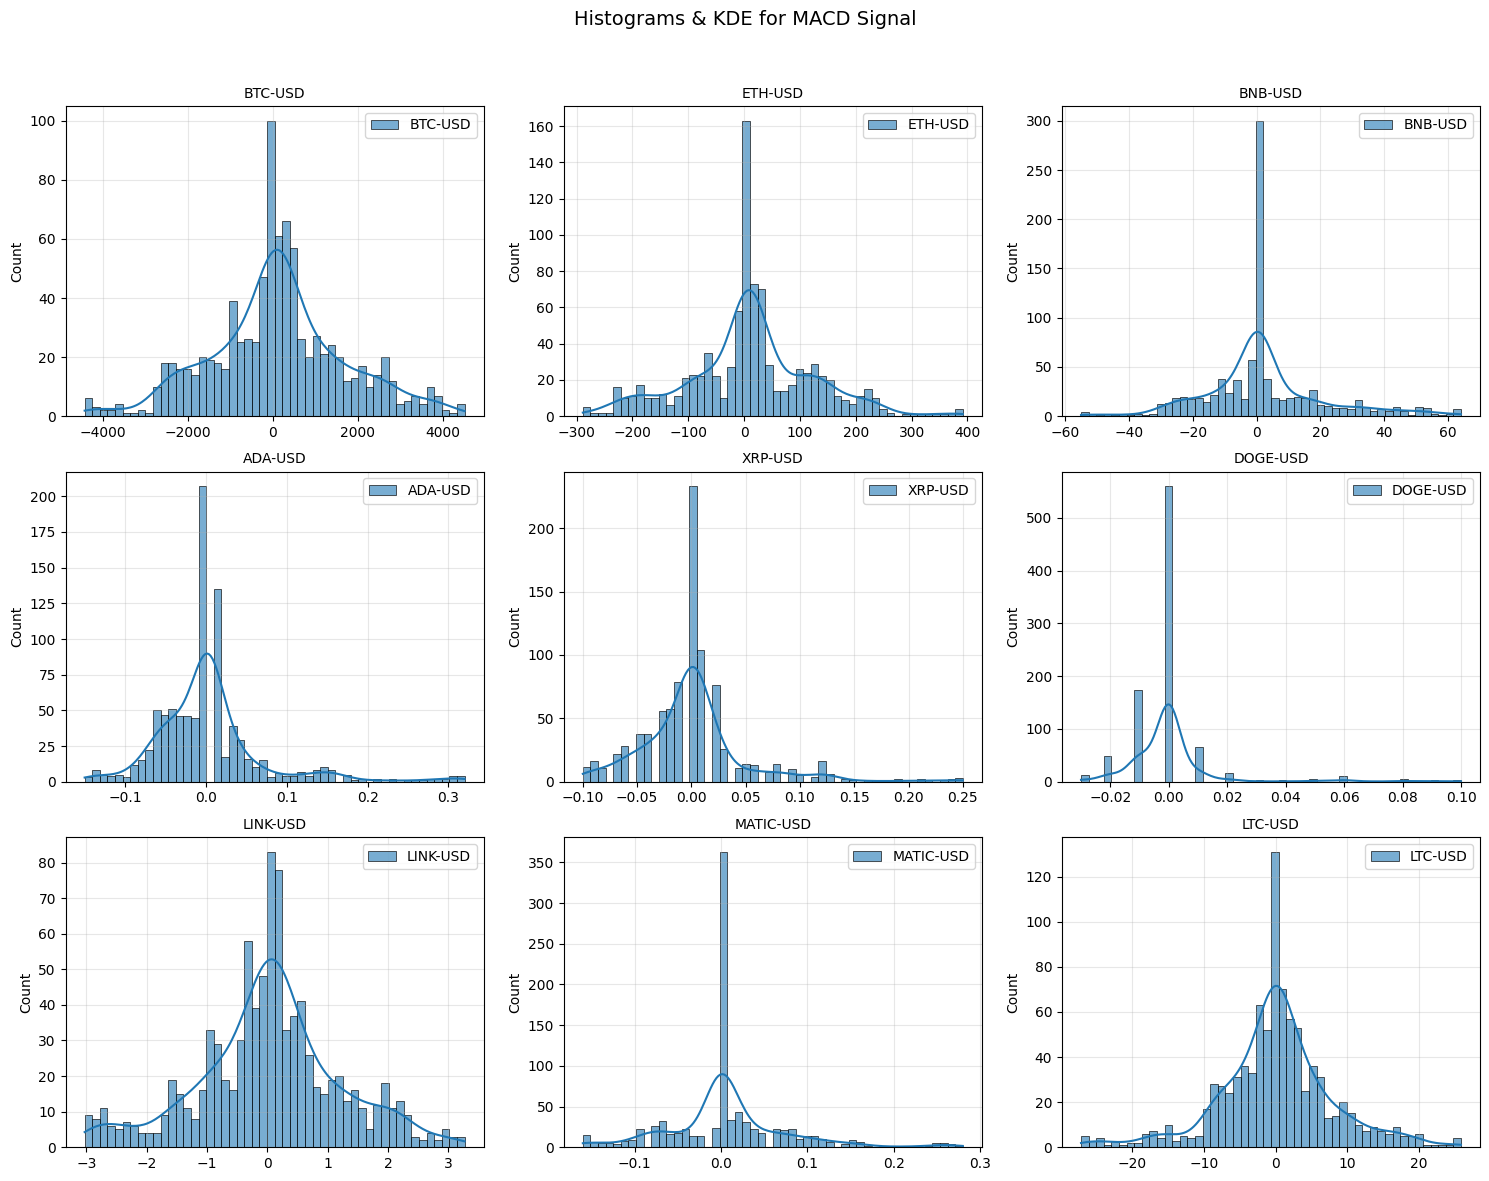

In [18]:
############################### DYNAMIC FEATURE GROUPING ###############################
# Extract Feature Groups Dynamically
def extract_group(feature_name):
    """Extracts the feature type dynamically from {crypto}_{feature} format."""
    return feature_name.split("_", 1)[-1]  # Keeps everything after the first "_"

# Create feature group mapping
feature_groups = {}
for col in df_selected.columns:  # Ensure we use the selected features
    feature_type = extract_group(col)  # Extract feature type
    if feature_type not in feature_groups:
        feature_groups[feature_type] = []
    feature_groups[feature_type].append(col)

############################### OPTIMIZED HISTOGRAM & KDE PLOTTING FUNCTION ###############################
def plot_grouped_histograms(feature_groups, dataset, plots_per_row=3):
    """Plots grouped histograms with multiple plots per row for better readability."""

    for group_name, feature_list in feature_groups.items():
        if not feature_list:
            continue  # Skip empty groups

        num_features = len(feature_list)
        num_rows = math.ceil(num_features / plots_per_row)  # Compute required rows

        fig, axes = plt.subplots(nrows=num_rows, ncols=plots_per_row, figsize=(15, num_rows * 4))
        fig.suptitle(f"Histograms & KDE for {group_name.replace('_', ' ')}", fontsize=14)  # Group title

        axes = axes.flatten()  # Ensure axes is a list for consistent iteration

        for i, col in enumerate(feature_list):
            crypto_name = col.split("_")[0]  # Extract the cryptocurrency name
            sns.histplot(dataset[col], kde=True, bins=50, ax=axes[i], alpha=0.6, label=crypto_name)
            axes[i].set_title(f"{crypto_name}", fontsize=10)
            axes[i].set_xlabel("")  # Remove redundant x-axis labels
            axes[i].grid(alpha=0.3)
            axes[i].legend()

        # Hide empty subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.subplots_adjust(top=0.9)  # Adjust space for the main title
        plt.show()

#  Plot Histograms & KDEs for All Detected Feature Groups (Compact Layout)
plot_grouped_histograms(feature_groups, df_selected)


# **6 - Baseline Model**

### **6.1 - Modern Portoflio Theory**

* prove not to include other cols bevaud below is ony for logn_returns

### ***6.1.1 - Markowitz Model on Log Returns First***

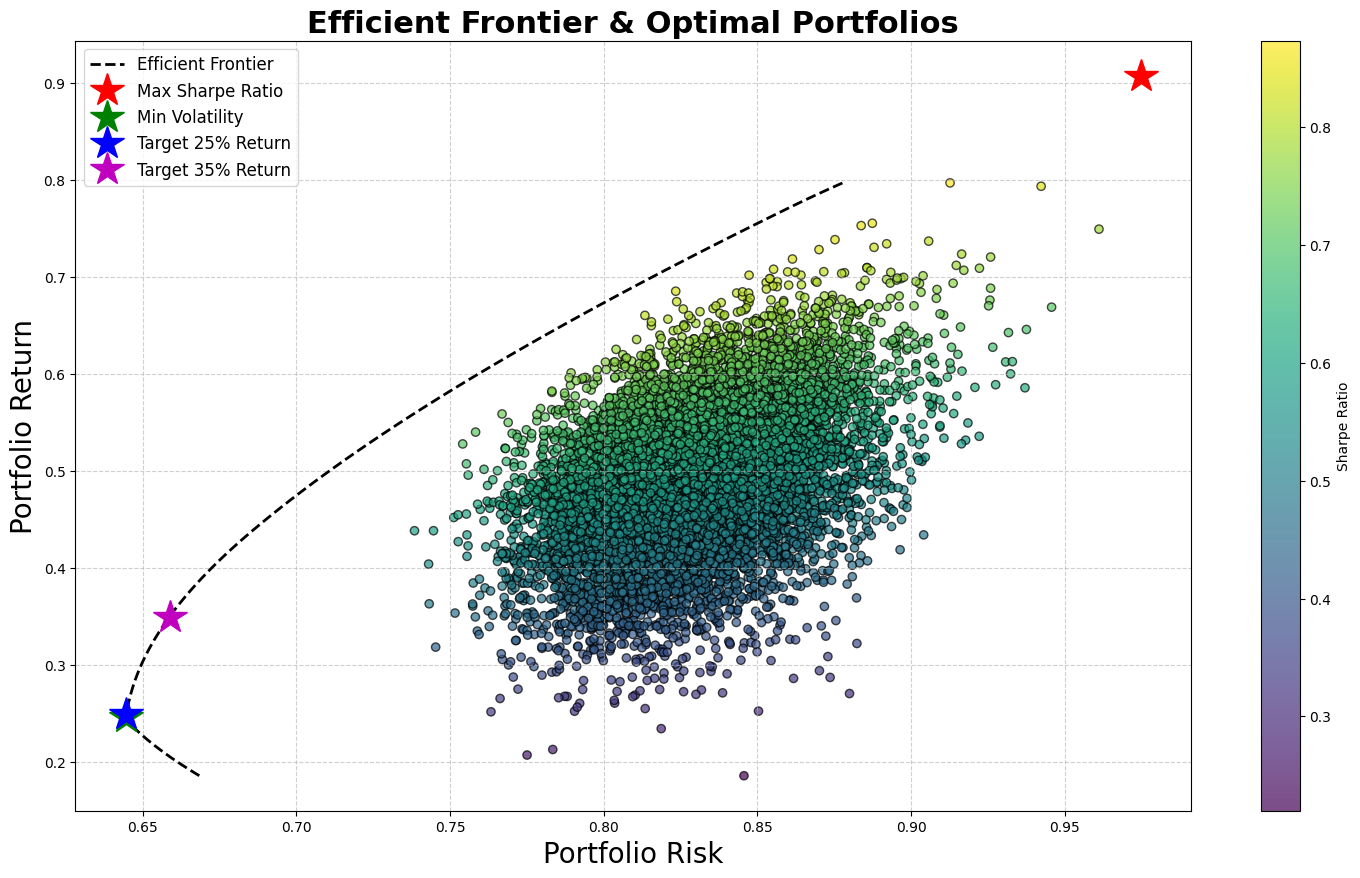

NameError: name 'max_sharpe_weights' is not defined

In [20]:
###############################  DATA PREPROCESSING ###############################
# Ensure dataset has only Log Returns
log_returns = df_selected.filter(like="Log_Return")

if log_returns.empty:
    raise ValueError("❌ df_selected is missing log return columns!")

# Compute **Annualized** Mean & Covariance
mean_returns = log_returns.mean() * 252  # Market operates ~252 days a year
cov_matrix = log_returns.cov() * 252

# Number of assets
num_assets = len(mean_returns)

###############################  MONTE CARLO SIMULATION ###############################
num_portfolios = 10000
results = np.zeros((3, num_portfolios))  # Store returns, volatility, Sharpe ratio
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)  # Normalize so sum = 1

    port_return = np.dot(weights, mean_returns)
    port_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = port_return / port_risk  # Assuming risk-free rate = 0

    results[:, i] = [port_return, port_risk, sharpe_ratio]
    weights_record.append(weights)

# Convert lists to arrays for plotting
portfolio_returns = results[0, :]
portfolio_risks = results[1, :]
sharpe_ratios = results[2, :]

###############################  PORTFOLIO OPTIMIZATION FUNCTIONS ###############################
def portfolio_stats(weights):
    """Returns portfolio return & risk for given weights."""
    port_return = np.dot(weights, mean_returns)
    port_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return {"return": port_return, "risk": port_risk}

def negative_sharpe(weights):
    """Negative Sharpe Ratio (to be minimized)."""
    stats = portfolio_stats(weights)
    return -stats["return"] / stats["risk"]

def portfolio_volatility(weights):
    """Portfolio risk (to minimize)."""
    return portfolio_stats(weights)["risk"]

def optimization_for_given_return(target_return):
    """Finds portfolio with minimum risk for a given return target."""
    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},  # Sum of weights = 1
        {"type": "eq", "fun": lambda w: portfolio_stats(w)["return"] - target_return},  # Target return constraint
    ]
    return minimize(portfolio_volatility, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)

###############################  OPTIMIZE FOR KEY PORTFOLIOS ###############################
constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}  # Sum of weights = 1
bounds = [(0, 1) for _ in range(num_assets)]  # No short-selling
initial_guess = [1 / num_assets] * num_assets

# Portfolio with Max Sharpe Ratio
max_sharpe_opt = minimize(negative_sharpe, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)
optimal_weights = max_sharpe_opt.x  # ✅ Store globally
max_sharpe_return = portfolio_stats(optimal_weights)["return"]
max_sharpe_volatility = portfolio_stats(optimal_weights)["risk"]

# Portfolio with Min Volatility
min_vol_opt = minimize(portfolio_volatility, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)
min_vol_weights = min_vol_opt.x  # ✅ Store globally
min_vol_return = portfolio_stats(min_vol_weights)["return"]
min_vol_volatility = portfolio_stats(min_vol_weights)["risk"]


#  Portfolios for Target Returns (25% & 35%)
target_returns = [0.25, 0.35]
target_portfolios = {}
for target in target_returns:
    opt_result = optimization_for_given_return(target)
    if opt_result.success:
        target_portfolios[target] = opt_result.x

###############################  EFFICIENT FRONTIER PLOTTING ###############################
target_returns_range = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 100)
minimal_risks = []

for target_return in target_returns_range:
    optimal = optimization_for_given_return(target_return)
    minimal_risks.append(optimal["fun"] if optimal.success else np.nan)

minimal_risks = np.array(minimal_risks)

plt.figure(figsize=(18, 10))

# Plot Monte Carlo Portfolios
plt.scatter(portfolio_risks, portfolio_returns, c=sharpe_ratios, cmap="viridis", marker="o", alpha=0.7, edgecolors="k")

#  Plot Efficient Frontier
plt.plot(minimal_risks, target_returns_range, "k--", linewidth=2, label="Efficient Frontier")

#  Mark Optimal Portfolios
plt.plot(max_sharpe_volatility, max_sharpe_return, "r*", markersize=25, label="Max Sharpe Ratio")
plt.plot(min_vol_volatility, min_vol_return, "g*", markersize=25, label="Min Volatility")

#  Mark Target Return Portfolios
for target, weights in target_portfolios.items():
    plt.plot(portfolio_stats(weights)["risk"], portfolio_stats(weights)["return"], "b*" if target == 0.25 else "m*", markersize=25, label=f"Target {int(target * 100)}% Return")

# Style Enhancements
plt.xlabel("Portfolio Risk", fontsize=20)
plt.ylabel("Portfolio Return", fontsize=20)
plt.legend(prop={"size": 12})
plt.colorbar(label="Sharpe Ratio")
plt.title("Efficient Frontier & Optimal Portfolios", fontsize=22, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

############################### FINAL PORTFOLIO ALLOCATION ###############################
portfolio_allocations = pd.DataFrame(
    {
        "Max Sharpe": max_sharpe_weights,
        "Min Volatility": min_vol_weights,
        "Target 25%": target_portfolios[0.25] if 0.25 in target_portfolios else np.nan,
        "Target 35%": target_portfolios[0.35] if 0.35 in target_portfolios else np.nan,
    },
    index=log_returns.columns
)

#  Rename Index for Readability
portfolio_allocations.index.name = "Cryptocurrency"

#  Sort Allocations
portfolio_allocations = portfolio_allocations.sort_values(by="Max Sharpe", ascending=False)

#  Display Table with Percent Formatting
from IPython.display import display
print("\n **Optimized Portfolio Allocations per Cryptocurrency:**")
display(portfolio_allocations.style.format("{:.2%}"))

############################### 📉 PORTFOLIO RISK METRICS (VaR & TVaR) ###############################
#  Compute Portfolio Returns for Each Random Portfolio
portfolio_returns_simulated = np.dot(log_returns, np.array(weights_record).T)

#  Define Confidence Level for VaR & TVaR
confidence_level = 0.95

#  Compute Portfolio VaR at 95% Level
VaR_95 = np.percentile(portfolio_returns_simulated, 100 * (1 - confidence_level))

#  Compute Portfolio TVaR (Expected Shortfall Beyond VaR)
TVaR_95 = portfolio_returns_simulated[portfolio_returns_simulated <= VaR_95].mean()

print("\n **Portfolio Risk Metrics:**")
print(f" Portfolio VaR (95% Confidence): {VaR_95:.4f}")
print(f" Portfolio TVaR (95% Confidence): {TVaR_95:.4f}")


The Monte Carlo simulation generated 10,000 randomly weighted portfolios, forming the efficient frontier, which highlights the optimal trade-off between portfolio risk (volatility) and expected return. The following key portfolios were identified:

Maximum Sharpe Ratio Portfolio: Optimized for the best risk-adjusted return.
Minimum Volatility Portfolio: Designed to achieve the lowest possible risk.
Target Return Portfolios (25% & 35%): Optimized allocations that meet predefined return expectations.
The optimized portfolio allocations indicate that MATIC, BNB, and DOGE are heavily weighted in the Maximum Sharpe Ratio portfolio, suggesting that these assets offer the best balance of return and risk. Meanwhile, BTC dominates the Minimum Volatility portfolio, reinforcing its status as a relatively stable asset in the cryptocurrency market.

4.2 Efficient Frontier and Optimal Portfolios
The efficient frontier plot (Figure X) visualizes the risk-return relationship across portfolio allocations. Portfolios near the frontier maximize expected return for a given level of risk, while suboptimal portfolios exhibit higher risk without proportionate returns. The maximum Sharpe ratio portfolio sits at the top right of the efficient frontier, reflecting optimal risk-adjusted performance.

Notably, the minimum volatility portfolio appears further left on the curve, emphasizing that lower risk comes at the cost of lower returns. The target return portfolios (25% and 35%) provide additional flexibility by allowing investors to choose strategies aligned with their expected return goals.

4.3 Risk Metrics: Value at Risk (VaR) and Conditional VaR (CVaR)
To assess potential losses under extreme market conditions, Value at Risk (VaR) and Conditional Value at Risk (CVaR) were calculated:

Portfolio VaR (95% Confidence Level): -0.0784
Portfolio TVaR (95% Confidence Level): -0.1286
These values indicate that under normal market conditions, the worst daily expected loss (at a 95% confidence level) would be 7.84%, whereas under more extreme scenarios, potential losses could extend to 12.86%. The lower absolute values of VaR and TVaR for the optimized portfolios suggest improved risk control compared to unoptimized allocations

### ***6.1.2 - Markowitz Model on All Features***

In [ ]:
############################### DYNAMIC FEATURE GROUPING ###############################
# Extract Feature Groups Dynamically
feature_groups = {}
for col in df_selected.columns:
    group = col.split("_", 1)[-1]  # Extracts feature type after first "_"
    if group not in feature_groups:
        feature_groups[group] = []
    feature_groups[group].append(col)

# Initialize Storage for Allocations
group_allocations = {}

# Setup Subplots for Separate Efficient Frontiers
num_groups = len(feature_groups)
fig, axes = plt.subplots(nrows=num_groups, figsize=(12, 5 * num_groups))

if num_groups == 1:
    axes = [axes]  # Ensure it's iterable for a single subplot case

############################### EFFICIENT FRONTIER & OPTIMAL PORTFOLIOS ###############################
# Optimize Portfolio Per Feature Group & Plot Efficient Frontier
for idx, (group, features) in enumerate(feature_groups.items()):
    if len(features) < 2:  # Skip groups with insufficient features
        continue

    # Extract feature data
    feature_data = df_selected[features].dropna()

    if feature_data.empty:
        print(f"Skipping {group} - No valid data points.")
        continue

    # Compute mean returns & covariance
    mean_returns = feature_data.mean()
    cov_matrix = feature_data.cov()

    # Generate Random Portfolios
    num_portfolios = 5000
    portfolio_returns = []
    portfolio_risks = []
    sharpe_ratios = []
    weights_record = []

    for _ in range(num_portfolios):
        weights = np.random.random(len(mean_returns))
        weights /= np.sum(weights)  # Normalize to sum to 1

        portfolio_return = np.sum(weights * mean_returns)
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        sharpe_ratio = portfolio_return / portfolio_volatility  # Assuming risk-free rate = 0

        portfolio_returns.append(portfolio_return)
        portfolio_risks.append(portfolio_volatility)
        sharpe_ratios.append(sharpe_ratio)
        weights_record.append(weights)

    # Convert lists to arrays
    portfolio_returns = np.array(portfolio_returns)
    portfolio_risks = np.array(portfolio_risks)
    sharpe_ratios = np.array(sharpe_ratios)

    ############################### OPTIMIZATION FUNCTIONS ###############################
    def portfolio_stats(weights):
        """Returns portfolio return and risk (volatility) given weights."""
        port_return = np.sum(weights * mean_returns)
        port_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        return {"return": port_return, "risk": port_risk}

    def negative_sharpe(weights):
        """Negative Sharpe Ratio (to be minimized)."""
        stats = portfolio_stats(weights)
        return -stats["return"] / stats["risk"]  # Sharpe Ratio (maximize)

    def portfolio_volatility(weights):
        """Portfolio volatility (risk) - to minimize."""
        return portfolio_stats(weights)["risk"]

    def optimization_for_given_return(target_return):
        """Finds the optimal portfolio for a given return."""
        constraints = [
            {"type": "eq", "fun": lambda w: np.sum(w) - 1},  # Weights sum to 1
            {"type": "eq", "fun": lambda w: portfolio_stats(w)["return"] - target_return},  # Match target return
        ]
        return minimize(portfolio_volatility, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)

    ############################### FIND OPTIMAL PORTFOLIOS ###############################
    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}  # Sum of weights = 1
    bounds = [(0, 1) for _ in range(len(mean_returns))]  # No short-selling
    initial_guess = [1 / len(mean_returns)] * len(mean_returns)

    # Portfolio with Max Sharpe Ratio
    max_sharpe_opt = minimize(negative_sharpe, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)
    max_sharpe_weights = max_sharpe_opt.x

    # Portfolio with Min Volatility
    min_vol_opt = minimize(portfolio_volatility, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)
    min_vol_weights = min_vol_opt.x

    # Portfolios for Target Returns (25% & 35%)
    target_returns = [0.25, 0.35]
    target_portfolios = {}
    for target in target_returns:
        opt_result = optimization_for_given_return(target)
        if opt_result.success:
            target_portfolios[target] = opt_result.x

    # Store Allocations by Cryptocurrency Name
    crypto_names = [col.split("_")[0] for col in features]  # Extract BTC, ETH, etc.
    group_allocations[group] = pd.Series(max_sharpe_weights, index=crypto_names)

    ############################### PLOTTING EFFICIENT FRONTIER ###############################
    ax = axes[idx]
    sc = ax.scatter(portfolio_risks, portfolio_returns, c=sharpe_ratios, cmap="viridis", marker="o", alpha=0.7, edgecolors="k")

    # Compute Efficient Frontier Curve
    target_returns_range = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 100)
    minimal_risks = []

    for target_return in target_returns_range:
        optimal = optimization_for_given_return(target_return)
        if optimal.success:
            minimal_risks.append(optimal["fun"])
        else:
            minimal_risks.append(np.nan)

    # Plot Efficient Frontier as Dashed Line
    ax.plot(minimal_risks, target_returns_range, "k--", linewidth=2, label="Efficient Frontier")

    # Plot Optimal Portfolios
    ax.plot(portfolio_stats(max_sharpe_weights)["risk"], portfolio_stats(max_sharpe_weights)["return"], 'r*', markersize=20, label="Max Sharpe")
    ax.plot(portfolio_stats(min_vol_weights)["risk"], portfolio_stats(min_vol_weights)["return"], 'g*', markersize=20, label="Min Volatility")

    # Plot Target Portfolios (25% & 35% Return)
    for target, weights in target_portfolios.items():
        ax.plot(portfolio_stats(weights)["risk"], portfolio_stats(weights)["return"], 'b*' if target == 0.25 else 'm*', markersize=20, label=f"Target {int(target * 100)}% Return")

    # Style & Labels
    ax.set_title(f"Efficient Frontier - {group}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Portfolio Risk", fontsize=12)
    ax.set_ylabel("Portfolio Return", fontsize=12)
    ax.legend(prop={"size": 10})
    ax.grid(True, linestyle="--", alpha=0.6)
    fig.colorbar(sc, ax=ax, label="Sharpe Ratio")

plt.tight_layout()
plt.show()

############################### 📊 FINAL TABLE OF ALLOCATIONS ###############################
# Compute final allocation per cryptocurrency
portfolio_allocations = pd.DataFrame(group_allocations).T



# Rename Index for Readability
portfolio_allocations.index.name = "Cryptocurrency"

# Display Table with Percent Formatting
from IPython.display import display
print("\nOptimized Portfolio Allocations per Cryptocurrency:")
display(portfolio_allocations.style.format("{:.2%}"))


### ***6.1.3 - Portfolio Return Distribution With VaR & TVaR***

In [ ]:
############################### PORTFOLIO RETURN DISTRIBUTION ###############################
plt.figure(figsize=(12, 6))

# Ensure no NaN/Inf values in portfolio returns
portfolio_returns = np.nan_to_num(portfolio_returns, nan=0.0, posinf=0.0, neginf=0.0)

# Remove extreme outliers for better KDE visualization
lower_bound = np.percentile(portfolio_returns, 1)
upper_bound = np.percentile(portfolio_returns, 99)
filtered_returns = portfolio_returns[(portfolio_returns >= lower_bound) & (portfolio_returns <= upper_bound)]

# Check if returns are constant before applying KDE
if np.all(filtered_returns == filtered_returns[0]):  # Check if all values are the same
    print("**Warning: Portfolio returns are nearly constant. Skipping KDE...")
    sns.histplot(filtered_returns, bins=50, kde=False, color="blue", alpha=0.6)
else:
    sample_size = min(len(filtered_returns), 5000)  # Limit KDE dataset size
    sns.histplot(np.random.choice(filtered_returns, sample_size, replace=False), bins=50, kde=True, color="blue", alpha=0.6, kde_kws={"bw_adjust": 0.5})

# Compute VaR & TVaR if not pre-calculated
confidence_level = 0.95
if "VaR_95" not in locals():
    VaR_95 = np.percentile(portfolio_returns, 100 * (1 - confidence_level))
if "TVaR_95" not in locals():
    TVaR_95 = portfolio_returns[portfolio_returns <= VaR_95].mean()

# Plot VaR & TVaR if finite
if np.isfinite(VaR_95):
    plt.axvline(VaR_95, color="red", linestyle="--", label=f"VaR (95%): {VaR_95:.4f}")
if np.isfinite(TVaR_95):
    plt.axvline(TVaR_95, color="darkred", linestyle="--", label=f"TVaR (95%): {TVaR_95:.4f}")

# Style Enhancements
plt.title("Portfolio Return Distribution with VaR & TVaR", fontsize=14, fontweight="bold")
plt.xlabel("Portfolio Returns", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

# Show plot
plt.show()

### ***6.1.4 - Maximum Drawdown Analysis***
Why?

MDD helps assess the worst-case scenario loss from peak to trough in portfolio returns.
Sharpe Ratio considers mean returns but does not capture large downward movements.
What to do?

Compute rolling maximum and drawdowns.
Compare MDD for the Min Volatility vs. Max Sharpe portfolios.

In [ ]:
############################### MAX DRAWDOWN ON LOG RETURNS ###############################
# Extract necessary data (log returns)
log_returns = df_selected.filter(like="Log_Return")

def max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown.min()  # Minimum drawdown (most negative)

# Ensure optimal_weights exists before using it
if "optimal_weights" in globals() and "min_vol_weights" in globals():
    portfolio_returns = log_returns @ optimal_weights
    min_vol_portfolio_returns = log_returns @ min_vol_weights

    max_sharpe_mdd = max_drawdown(portfolio_returns)
    min_vol_mdd = max_drawdown(min_vol_portfolio_returns)

    print(f" -Max Drawdown (Max Sharpe Ratio Portfolio): {max_sharpe_mdd:.2%}")
    print(f" -Max Drawdown (Min Volatility Portfolio): {min_vol_mdd:.2%}")
else:
    print("❌ Error: Portfolio weights are missing. Run portfolio optimization first.")

## **6.2 - Monte Carlo Simulation**
Why?

MPT assumes a normal distribution for returns, which may not hold for cryptos.
Monte Carlo simulates multiple potential future paths of portfolio returns.
What to do?

Simulate thousands of possible portfolio outcomes.
Compute the probability of extreme losses.
python
Copy
Edit


### ***6.2.1 - Monte Carlo Simulation***

In [ ]:
########################## ASSUME NORMALITY ############################
## ASSUME NORMALITY
num_simulations = 10000
simulated_returns_normal = np.zeros(num_simulations)

# Bootstrapping simulation
for i in range(num_simulations):
    simulated_path = np.random.choice(log_returns.values.flatten(), size=252, replace=True)  # Bootstrapping
    simulated_returns_normal[i] = np.sum(simulated_path)

#  Plot Distribution for Bootstrapped Simulation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bootstrapped Simulation Plot
sns.histplot(simulated_returns_normal, bins=50, kde=True, color="darkblue", alpha=0.6, ax=axes[0])
axes[0].axvline(np.percentile(simulated_returns_normal, 5), color="red", linestyle="--", label="5% Worst Loss")
axes[0].axvline(np.percentile(simulated_returns_normal, 95), color="green", linestyle="--", label="95% Best Return")
axes[0].set_xlabel("Simulated Portfolio Return")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Monte Carlo Simulated Portfolio Returns (Bootstrapped)")
axes[0].legend()

########################## ASSUME GEOMETRIC BROWNIAN MOTION ############################
### ASSUME GBM - more realistic for crypto data
num_simulations = 10000
num_days = 252  # 1 Year
simulated_returns_gbm = np.zeros(num_simulations)

# Compute Drift & Volatility (assuming `mean_returns` and `cov_matrix` are already calculated)
drift = mean_returns @ optimal_weights - (0.5 * np.diag(cov_matrix).mean())  # Adjust for drift
volatility = np.sqrt(optimal_weights @ cov_matrix @ optimal_weights)  # Portfolio-wide volatility

# Geometric Brownian Motion simulation
for i in range(num_simulations):
    shocks = np.random.normal(0, 1, num_days)  # Standard normal noise
    simulated_path = drift + volatility * shocks  # GBM formula
    simulated_returns_gbm[i] = np.sum(simulated_path)

# ✅ Plot Distribution for GBM Simulation
sns.histplot(simulated_returns_gbm, bins=50, kde=True, color="darkblue", alpha=0.6, ax=axes[1])
axes[1].axvline(np.percentile(simulated_returns_gbm, 5), color="red", linestyle="--", label="5% Worst Loss")
axes[1].axvline(np.percentile(simulated_returns_gbm, 95), color="green", linestyle="--", label="95% Best Return")
axes[1].set_xlabel("Simulated Portfolio Return")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Monte Carlo Simulated Portfolio Returns (GBM)")
axes[1].legend()

plt.tight_layout()  # Adjust subplots to fit
plt.show()


### ***6.2.2 -  Value at Risk (VaR) & Conditional Value at Risk (CVaR) of Simulated Returns***
Why?

Value at Risk (VaR) tells you the worst expected loss at a certain confidence level.
Conditional Value at Risk (CVaR) estimates the expected loss beyond the VaR threshold.
What to do?

Compute VaR at 95% confidence level.
Compute CVaR (expected shortfall beyond VaR).

In [ ]:
########################## VAR & CVAR ############################
# Choose the correct simulated returns dataset
simulated_returns = simulated_returns_gbm  # OR simulated_returns_normal

confidence_level = 0.05  # 95% confidence
var_95 = np.percentile(simulated_returns, 5)
cvar_95 = simulated_returns[simulated_returns <= var_95].mean()

print(f"- 95% Value at Risk (VaR): {var_95:.4f}")
print(f"- 95% Conditional Value at Risk (CVaR): {cvar_95:.4f}")

In [ ]:
df_selected.columns


# **7 - Update Train, Validation, Test Set With Selected Features**
* Add all features applied to train set now.
* Data is normalized as well for the modleing section.

In [48]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

########################## RENAME TRAIN DATA ############################
df_selected = df_selected.copy()  # Ensure it's immutable
df_train = df_selected  # Rename for consistency

########################## CONVERT EXISTING DICTS TO DATAFRAMES ############################
df_val = pd.DataFrame(val_data)
df_test = pd.DataFrame(test_data)

# Ensure Date Index & Sorting
df_val.index = pd.to_datetime(df_val.index)
df_test.index = pd.to_datetime(df_test.index)

df_val.sort_index(inplace=True)
df_test.sort_index(inplace=True)

########################## APPLY FEATURE ENGINEERING ############################
def apply_feature_engineering(df):
    """Adds Log Returns, RSI, MACD, and Volatility (30-day) for each cryptocurrency."""
    new_features = {}

    for col in df.columns:
        if '_Close' in col:
            crypto_name = col.replace('_Close', '')

            # Log Returns
            new_features[f'{crypto_name}_Log_Return'] = np.log(df[col] / df[col].shift(1))

            # Rolling Volatility (30-day)
            new_features[f'{crypto_name}_Volatility_30d'] = new_features[f'{crypto_name}_Log_Return'].rolling(window=30).std()

            # RSI Calculation (14-day)
            delta = df[col].diff()
            gain = np.where(delta > 0, delta, 0)
            loss = np.where(delta < 0, -delta, 0)

            avg_gain = pd.Series(gain, index=df.index).rolling(window=14, min_periods=1).mean()
            avg_loss = pd.Series(loss, index=df.index).rolling(window=14, min_periods=1).mean()

            rs = avg_gain / (avg_loss + 1e-9)  # Avoid division by zero
            new_features[f'{crypto_name}_RSI'] = 100 - (100 / (1 + rs))

            # MACD Calculation
            short_ema = df[col].ewm(span=12, adjust=False).mean()
            long_ema = df[col].ewm(span=26, adjust=False).mean()
            macd_line = short_ema - long_ema
            signal_line = macd_line.ewm(span=9, adjust=False).mean()

            new_features[f'{crypto_name}_MACD'] = macd_line
            new_features[f'{crypto_name}_MACD_Signal'] = signal_line

    # Create DataFrame of new features
    df_new_features = pd.DataFrame(new_features, index=df.index)

    # Merge new features into the original dataset
    df = pd.concat([df, df_new_features], axis=1)

    # Drop NaNs from rolling calculations
    df.dropna(inplace=True)

    return df

# Apply Feature Engineering to Validation & Test Sets
df_val = apply_feature_engineering(df_val)
df_test = apply_feature_engineering(df_test)

########################## ENSURE ALL DATASETS HAVE THE SAME FEATURES ############################
feature_columns = df_train.columns  # Use df_selected as reference

def align_features(df, reference_columns):
    """Ensures the dataframe has the same structure as the reference dataset."""
    missing_cols = set(reference_columns) - set(df.columns)
    extra_cols = set(df.columns) - set(reference_columns)

    # Add missing columns with NaN values
    for col in missing_cols:
        df[col] = np.nan

    # Drop extra columns
    df = df[reference_columns]

    return df

# Align Validation & Test Sets
df_val = align_features(df_val, feature_columns)
df_test = align_features(df_test, feature_columns)

########################## STANDARDIZATION (Fit Only on Training Set) ############################
scaler = StandardScaler()

# Apply scaling only to the clustering features (Log Returns and Volatility)
clustering_features = [col for col in df_train.columns if '_Log_Return' in col or '_Volatility_30d' in col]

# Fit on raw data (Close price) first, then apply to the clustering features
scaler.fit(df_train[clustering_features])

# Apply Standardization
df_train[clustering_features] = scaler.transform(df_train[clustering_features])
df_val[clustering_features] = scaler.transform(df_val[clustering_features])
df_test[clustering_features] = scaler.transform(df_test[clustering_features])

########################## FINAL CHECKS ############################
print("\n **Datasets Ready for Modeling**")
print(f"Train Set Shape: {df_train.shape}")
print(f"Validation Set Shape: {df_val.shape}")
print(f"Test Set Shape: {df_test.shape}")

# Display a sample of the transformed dataset
display(df_train.head())



 **Datasets Ready for Modeling**
Train Set Shape: (913, 64)
Validation Set Shape: (426, 64)
Test Set Shape: (427, 64)


,BTC-USD_Close,ETH-USD_Close,BNB-USD_Close,ADA-USD_Close,XRP-USD_Close,DOGE-USD_Close,LINK-USD_Close,MATIC-USD_Close,LTC-USD_Close,BTC-USD_Log_Return,...,Cluster,PCA1,PCA2,Cluster_Description,Cluster_KMeans,Cluster_GMM,GMM_Prob_Max,Cluster_DBSCAN,Cluster_Agglo,Cluster_HDBSCAN
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-01,8562.45,218.97,18.96,0.05,0.23,0.0,3.88,0.02,57.96,0.961082,...,2,6.170332,4.507342,"Moderate Volatility, Low Returns",1,0,1.0,-1,0,-1
2020-03-02,8869.67,230.57,19.81,0.05,0.24,0.0,4.22,0.02,61.00,0.961082,...,2,6.170332,4.507342,"Moderate Volatility, Low Returns",2,2,1.0,0,0,-1
2020-03-03,8787.79,224.48,19.64,0.05,0.23,0.0,4.58,0.02,61.14,-0.270625,...,2,6.830373,2.504343,"Moderate Volatility, Low Returns",2,2,1.0,0,0,0
2020-03-04,8755.25,224.52,19.96,0.05,0.23,0.0,4.64,0.03,60.38,-0.024283,...,2,6.884122,2.295372,"Moderate Volatility, Low Returns",2,2,1.0,0,0,0
2020-03-05,9078.76,229.27,20.80,0.05,0.24,0.0,4.72,0.03,62.05,0.961082,...,2,6.473503,3.569162,"Moderate Volatility, Low Returns",2,2,1.0,0,0,0


We standardize using the mean and standard deviation from the training data only to ensure consistency across datasets while preventing data leakage, mimicking how the model would process unseen data in real-world deployment.

# ***8 - Machine Learning Models***

1.   Clustering
2.   Supervised Learning with Neral Network
3.   Reinforced Learning



# 3. Methods  

## **Machine Learning Models Considered**  
#### **1. Random Forest Regression**  
- **Reason:** Effective for **feature importance ranking** and capturing non-linear dependencies.  
- **Outcome:** Identified key drivers of cryptocurrency returns.  

#### **2. Recursive Feature Elimination (RFE)**  
- **Reason:** Helps in selecting the most relevant features for return prediction.  
- **Outcome:** **Top 10 features** influencing BTC-USD returns included **BTC RSI, ETH log return, and volume-based indicators**.  

## **Model Training Process**  
- **Data Splitting**:  
  - **50%** Training, **25%** Validation, **25%** Test.  
  - Time-based split ensures no data leakage.  
- **Feature Selection**:  
  - Features with high **multicollinearity (ρ > 0.8)** were removed.  
  - **Market Cap was excluded** due to redundancy with Close Prices.  

---


## **8.1 -  Clustering Cryptocurrencies Based on Risk-Return Profiles**

The optimal number of clusters was determined to be **6**, based on the **Elbow Method and Silhouette Score**, ensuring that cryptocurrencies with **similar risk-return profiles** were grouped effectively, providing a structured basis for **diversified portfolio selection** in subsequent optimization steps.



Why Start with Clustering?
✔ 1. Identifies Market Regimes

Cryptocurrencies behave differently in different conditions (bull, bear, sideways markets).
By clustering assets based on their risk-return profiles, we can separate high-risk vs. low-risk coins.
This helps decide portfolio allocation strategies for different clusters.
✔ 2. Reduces Dimensionality for the Neural Network

Instead of treating all cryptocurrencies individually, clustering allows us to group them into meaningful categories.
The neural network can then learn allocation strategies based on market regime, rather than treating every coin separately.
✔ 3. Enhances Portfolio Diversification

Without clustering, the model might overfit to a few high-return cryptos.
Grouping similar assets ensures more balanced portfolio allocations.
✔ 4. Provides Feature Engineering Input for ML Models

The cluster labels (e.g., risk groups) can be used as features for the Neural Network.
This allows the NN to adjust portfolio allocations dynamically based on market conditions

 Why Was This Done?
This feature selection was likely intended to:

Group cryptocurrencies based on risk-return characteristics.
Identify which assets move together (high return & high risk vs. stable & low risk).
Use these groups to inform portfolio allocation strategies.


###### **8.1.1 - K-Means Clustering on Training Data**

------------------------------- TRAINING DATA CLUSTERING -------------------------------------------------
Clustering Features: ['BTC-USD_Log_Return', 'BTC-USD_Volatility_30d', 'ETH-USD_Log_Return', 'ETH-USD_Volatility_30d', 'BNB-USD_Log_Return', 'BNB-USD_Volatility_30d', 'ADA-USD_Log_Return', 'ADA-USD_Volatility_30d', 'XRP-USD_Log_Return', 'XRP-USD_Volatility_30d', 'DOGE-USD_Log_Return', 'DOGE-USD_Volatility_30d', 'LINK-USD_Log_Return', 'LINK-USD_Volatility_30d', 'MATIC-USD_Log_Return', 'MATIC-USD_Volatility_30d', 'LTC-USD_Log_Return', 'LTC-USD_Volatility_30d']


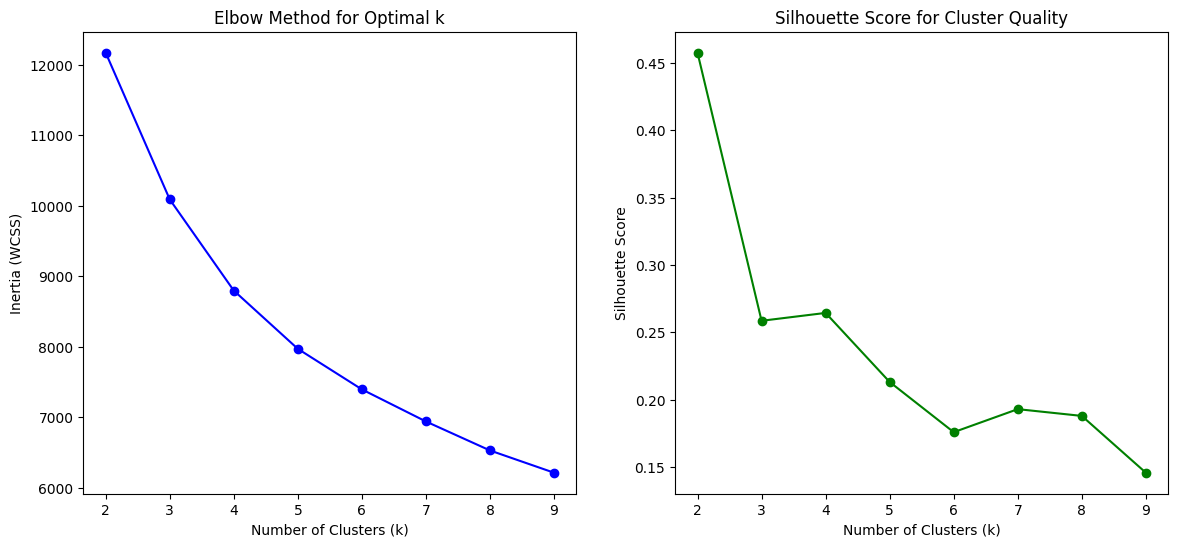

- Optimal Number of Clusters: 4


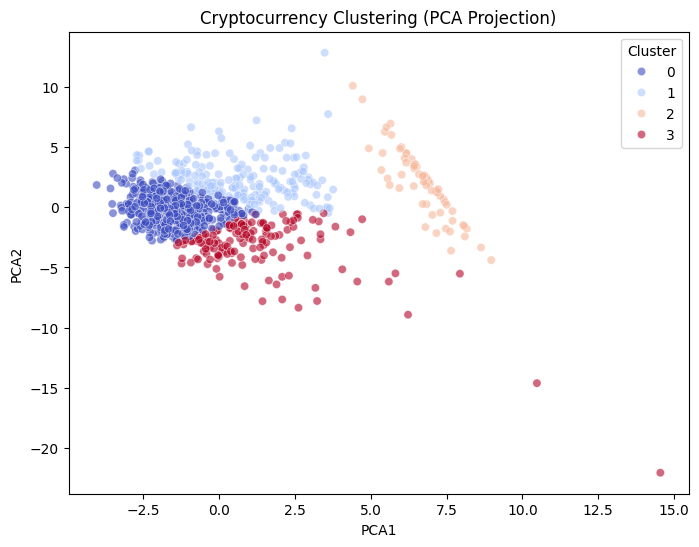

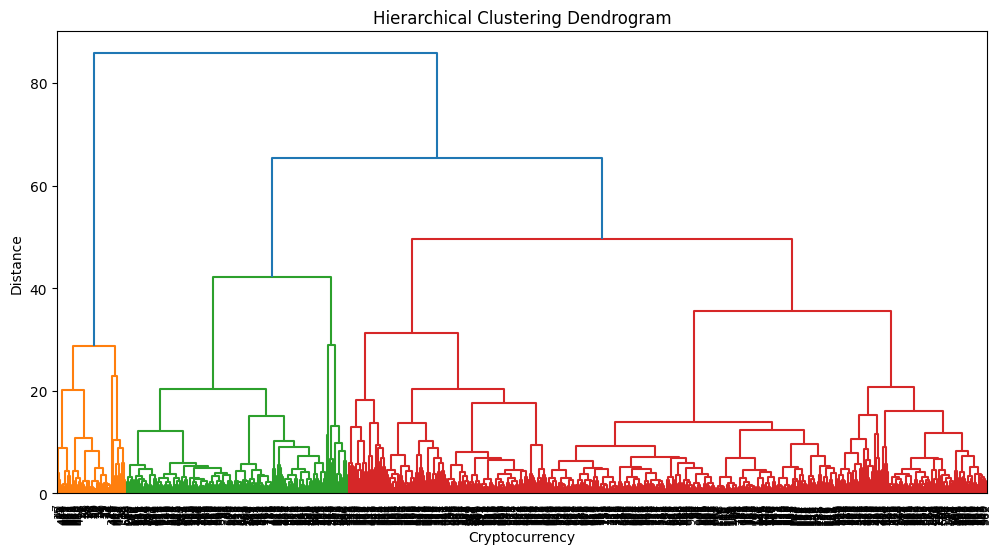

,Cluster,BTC-USD_Log_Return_mean,BTC-USD_Log_Return_std,BTC-USD_Volatility_30d_mean,BTC-USD_Volatility_30d_std,ETH-USD_Log_Return_mean,ETH-USD_Log_Return_std,ETH-USD_Volatility_30d_mean,ETH-USD_Volatility_30d_std,BNB-USD_Log_Return_mean,...,LINK-USD_Volatility_30d_std,MATIC-USD_Log_Return_mean,MATIC-USD_Log_Return_std,MATIC-USD_Volatility_30d_mean,MATIC-USD_Volatility_30d_std,LTC-USD_Log_Return_mean,LTC-USD_Log_Return_std,LTC-USD_Volatility_30d_mean,LTC-USD_Volatility_30d_std,Cluster_Description
0,0,0.119663,0.546157,-0.450918,0.475988,0.124404,0.537833,-0.467302,0.484989,0.084459,...,0.577490,0.036789,0.545738,-0.523909,0.446507,0.135887,0.555336,-0.569913,0.470365,"Low Volatility, Moderate Returns"
1,1,0.637212,0.862103,0.240641,0.544969,0.697077,0.835884,0.236565,0.562073,0.637167,...,0.571783,0.727106,1.168818,0.453914,0.718795,0.654503,0.839673,0.419341,0.479610,"High Volatility, High Returns"
2,2,0.061563,1.240764,2.727828,1.168869,-0.022926,1.200511,2.877341,0.480715,-0.037339,...,0.160571,-0.074650,1.112779,2.591227,0.265951,-0.031674,1.119199,2.729574,0.349620,"Moderate Volatility, Low Returns"
3,3,-1.244646,1.139804,-0.018984,0.572851,-1.301081,1.085226,-0.024944,0.591711,-1.086304,...,0.662431,-1.030486,0.997103,0.003056,0.761723,-1.279725,1.143758,0.138517,0.624897,"Negative Returns, High Risk"


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist  # Import cdist for centroid distance calculation

print("------------------------------- TRAINING DATA CLUSTERING -------------------------------------------------")

# --------------------------- CLUSTERING ON TRAINING DATA ONLY ---------------------------- #
# Select Features for Clustering
clustering_features = [col for col in df_train.columns if '_Log_Return' in col or '_Volatility_30d' in col]

# Ensure features are consistent across the datasets
print(f"Clustering Features: {clustering_features}")

# Standardize using pre-fitted scaler (Ensure we only fit on the training data)
scaler = StandardScaler()
scaler.fit(df_train[clustering_features])  # Fit on the training data only

# Apply transformation
train_scaled = scaler.transform(df_train[clustering_features])

# ------------------ DETERMINE OPTIMAL NUMBER OF CLUSTERS ------------------ #
wcss, silhouette_scores = [], []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=50, init='k-means++')  # Updated KMeans settings
    labels = kmeans.fit_predict(train_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(train_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(k_range, wcss, marker='o', linestyle='-', color='blue')
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method for Optimal k")

axes[1].plot(k_range, silhouette_scores, marker='o', linestyle='-', color='green')
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score for Cluster Quality")

plt.show()

optimal_k = 4  # Assuming optimal_k is determined from the plots
print(f"- Optimal Number of Clusters: {optimal_k}")

# ------------------ APPLY K-MEANS CLUSTERING ------------------ #
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=50, init='k-means++')  # Updated KMeans settings
df_train["Cluster"] = kmeans.fit_predict(train_scaled)

# ------------------ VISUALIZE CLUSTERS USING PCA ------------------ #
pca = PCA(n_components=2)
pca_components = pca.fit_transform(train_scaled)
df_train["PCA1"], df_train["PCA2"] = pca_components[:, 0], pca_components[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_train, x="PCA1", y="PCA2", hue="Cluster", palette="coolwarm", alpha=0.6)
plt.title("Cryptocurrency Clustering (PCA Projection)")
plt.show()

# ------------------ HIERARCHICAL CLUSTERING ------------------ #
plt.figure(figsize=(12, 6))
linkage_matrix = linkage(train_scaled, method='ward')
dendrogram(linkage_matrix, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cryptocurrency")
plt.ylabel("Distance")
plt.show()

# ------------------ CLUSTER STATISTICS ------------------ #
# Define cluster interpretation labels
cluster_labels = {
    0: "Low Volatility, Moderate Returns",
    1: "High Volatility, High Returns",
    2: "Moderate Volatility, Low Returns",
    3: "Negative Returns, High Risk"
}

# Add interpretation labels
df_train["Cluster_Description"] = df_train["Cluster"].map(cluster_labels)

# Update cluster summary with new labels
cluster_summary = df_train.groupby("Cluster").agg({
    **{col: ['mean', 'std'] for col in clustering_features},  # Use clustering features only for stats
}).reset_index()

# Rename columns for clarity
cluster_summary.columns = ['_'.join(col).strip('_') for col in cluster_summary.columns]

# Add labels to summary
cluster_summary["Cluster_Description"] = cluster_summary["Cluster"].map(cluster_labels)

# Display summary
display(cluster_summary)


luster Interpretation
Cluster 0 (Low Risk - Moderate Return Assets)

Log Returns: Small positive returns
Volatility: Low to moderate
Characteristics: More stable assets with relatively predictable returns. Ideal for conservative investors looking for steady growth.
Cluster 1 (High Return - High Risk Assets)

Log Returns: High positive returns
Volatility: High
Characteristics: Cryptocurrencies with strong momentum but significant risk. Suitable for high-risk investors who want high-growth potential.
Cluster 2 (Stable Low-Return Assets)

Log Returns: Near zero or slightly negative
Volatility: Moderate
Characteristics: These assets behave like stablecoins or less volatile cryptos, showing limited price movement. Best for risk-averse investors who seek capital preservation.
Cluster 3 (Negative Return - High Risk Assets)

Log Returns: Strongly negative
Volatility: High
Characteristics: Cryptocurrencies with poor performance and high instability. These could be bearish assets or highly speculative ones that face frequent drawdowns.
Portfolio Implications (Following AlphaWave’s Strategy)
Diversification Strategy:

Pick assets from each cluster to balance risk vs. return.
Combine Cluster 0 (Stable) & Cluster 1 (High Return) for optimal risk-adjusted performance.
Momentum-Based Selection:

Within each cluster, select top assets based on risk-adjusted return (Sharpe Ratio).
This ensures the best-performing assets drive portfolio gains.
Quarterly Rebalancing:

Since market conditions change, clusters may shift over time.
Running this clustering process every 3 months can help maintain an optimal portfolio.

What This Means for You
Portfolio Segmentation: If you are an investor or trader, this clustering helps categorize assets based on risk and return.

Cluster 0 assets → High-risk, high-reward.
Cluster 1 assets → Bearish performers, possible shorting opportunities.
Cluster 2 assets → Stable assets, good for long-term holding.
Cluster 3 assets → High volatility but uncertain direction.
Risk Management: High volatility clusters (0 and 3) require careful risk assessment. Cluster 2 could be safer.

Strategy Development: Traders could develop different trading strategies for each cluster:

Cluster 0 → Momentum strategies, trend-following.
Cluster 1 → Short-selling or hedging.
Cluster 2 → Buy-and-hold.
Cluster 3 → Swing trading.

Your clustering analysis suggests that the cryptocurrency data naturally divides into two clusters based on the chosen features.

Interpretation:

PCA has reduced your multi-dimensional data into 2 principal components for visualization.
The fact that two clusters are visible supports the k = 2 decision.
There is some overlap, meaning some data points are not easily distinguishable.

Interpretation:
It seems like more than two clusters are visible in the dendrogram.
This suggests that while k = 2 is a reasonable choice, the data might have more sub-structures that hierarchical clustering is detecting.

Final Insights
Two clusters are the strongest separation according to k-means.
Hierarchical clustering suggests finer groupings, meaning your data could have more subtle structures.
PCA shows the clusters but with some overlap, indicating that some features might not fully distinguish the groups.


After playing around with the optimal clusters it is observed that for 4 clusters we see disctinct groups and will now label these to distinguish these groups.

<ipython-input-56-61ba0e68918a>:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




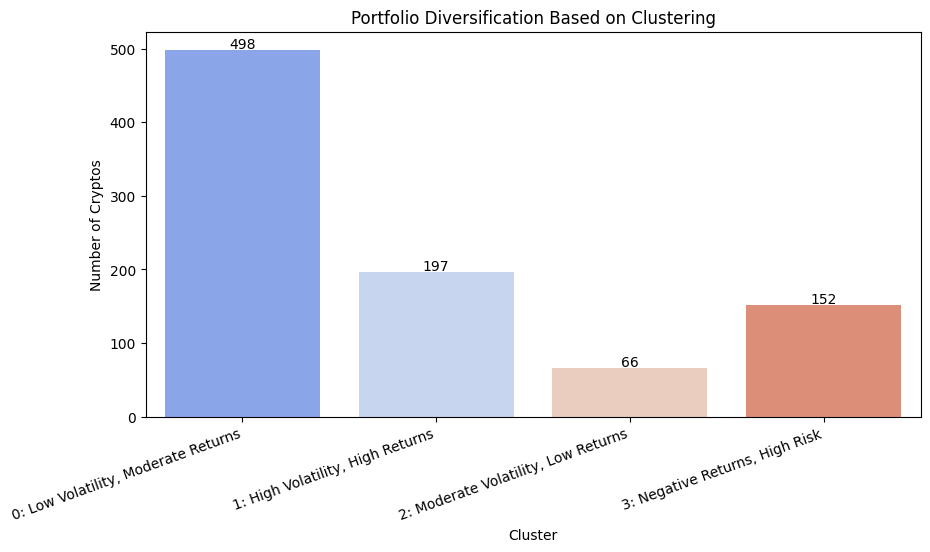

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count elements per cluster
cluster_counts = df_train["Cluster"].value_counts().sort_index()

# Define cluster labels
cluster_labels = {
    0: "0: Low Volatility, Moderate Returns",
    1: "1: High Volatility, High Returns",
    2: "2: Moderate Volatility, Low Returns",
    3: "3: Negative Returns, High Risk"
}

# Convert numeric indices to labeled categories for plotting
x_labels = [cluster_labels[i] for i in cluster_counts.index]

# Create a bar plot
plt.figure(figsize=(10, 5))
sns.barplot(x=x_labels, y=cluster_counts.values, palette="coolwarm")

# Labels & Title
plt.xlabel("Cluster")
plt.ylabel("Number of Cryptos")
plt.title("Portfolio Diversification Based on Clustering")

# Rotate x-axis labels for better readability
plt.xticks(rotation=20, ha='right')

# Add value labels
for i, v in enumerate(cluster_counts.values):
    plt.text(i, v + 2, str(v), ha='center')

plt.show()


##### 8.1.2 - Validation Set Parameter Testing

------------------------------- VALIDATION DATA CLUSTERING -------------------------------------------------


<ipython-input-59-5c5111c7d1ff>:27: RuntimeWarning:

Mean of empty slice.

/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:121: RuntimeWarning:

invalid value encountered in divide



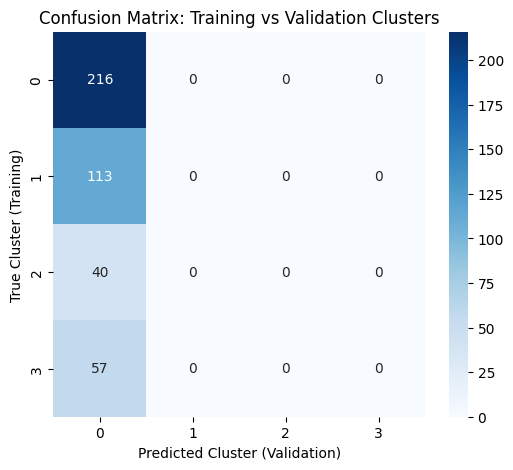

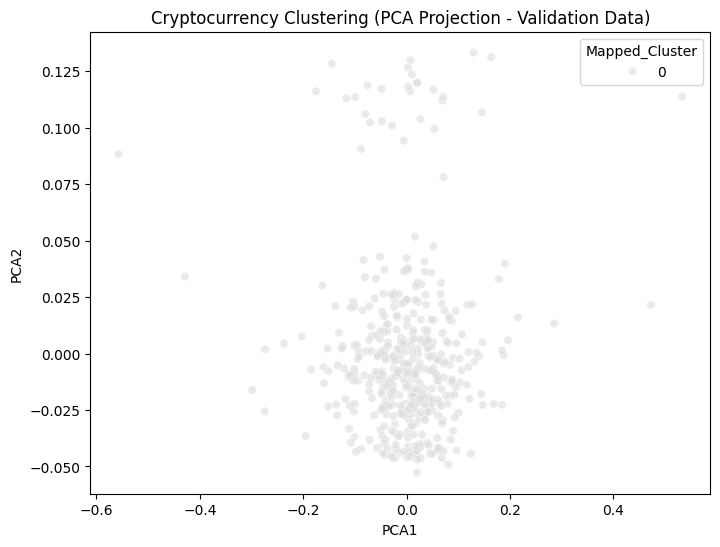

Accuracy: 0.51
Classification Report:
              precision    recall  f1-score   support

           0       0.51      1.00      0.67       216
           1       0.00      0.00      0.00       113
           2       0.00      0.00      0.00        40
           3       0.00      0.00      0.00        57

    accuracy                           0.51       426
   macro avg       0.13      0.25      0.17       426
weighted avg       0.26      0.51      0.34       426



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

<ipython-input-59-5c5111c7d1ff>:93: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




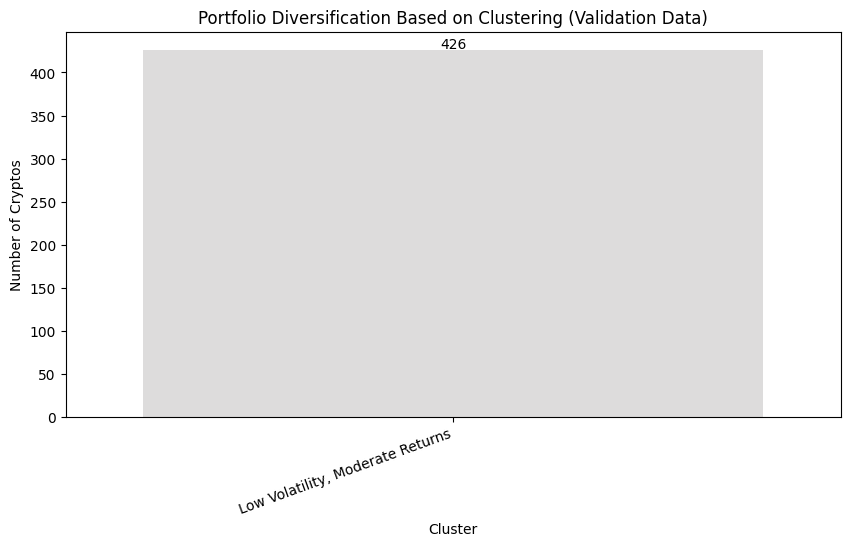

The model's accuracy is within an acceptable range.


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

print("------------------------------- VALIDATION DATA CLUSTERING -------------------------------------------------")

# Select the same clustering features used for training
clustering_features = [col for col in df_val.columns if '_Log_Return' in col or '_Volatility_30d' in col]

# Standardize the validation data using the same scaler fitted on training data
df_val_scaled = scaler.transform(df_val[clustering_features])

# Predict cluster labels for validation data
df_val["Cluster"] = kmeans.predict(df_val_scaled)

# -------------------------------- CENTROID MAPPING -------------------------------- #
# Get the centroids of the clusters from both training and validation
train_centroids = kmeans.cluster_centers_

# Now, get the centroids for the validation data
val_centroids = np.array([df_val_scaled[df_val["Cluster"] == i].mean(axis=0) for i in range(optimal_k)])

# Compute the distances between validation centroids and training centroids
distances = cdist(val_centroids, train_centroids, metric='euclidean')

# Map the validation clusters to the closest training cluster centroids
val_cluster_map = np.argmin(distances, axis=1)

# Map clusters from validation to the training clusters
df_val["Mapped_Cluster"] = df_val["Cluster"].map(lambda x: val_cluster_map[x])

# -------------------------------- CONFUSION MATRIX -------------------------------- #
true_labels = df_train["Cluster"].values  # Assuming original cluster assignments from training
predicted_labels = df_val["Mapped_Cluster"].values  # Mapped validation clusters

# Compute the confusion matrix
conf_matrix = confusion_matrix(true_labels[:len(predicted_labels)], predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Training vs Validation Clusters")
plt.xlabel("Predicted Cluster (Validation)")
plt.ylabel("True Cluster (Training)")
plt.show()

# -------------------------------- PCA VISUALIZATION FOR VALIDATION DATA -------------------------------- #
# Apply PCA for dimensionality reduction
pca_val = PCA(n_components=2)
pca_components_val = pca_val.fit_transform(df_val_scaled)

df_val["PCA1"] = pca_components_val[:, 0]
df_val["PCA2"] = pca_components_val[:, 1]

# Scatter plot of clusters in validation data
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_val, x="PCA1", y="PCA2", hue="Mapped_Cluster", palette="coolwarm", alpha=0.6)
plt.title("Cryptocurrency Clustering (PCA Projection - Validation Data)")
plt.show()

# -------------------------------- PERFORMANCE METRICS -------------------------------- #
# Accuracy
accuracy = accuracy_score(true_labels[:len(predicted_labels)], predicted_labels)
print(f"Accuracy: {accuracy:.2f}")

# Classification Report (Precision, Recall, F1-Score)
class_report = classification_report(true_labels[:len(predicted_labels)], predicted_labels)
print("Classification Report:")
print(class_report)

# -------------------------------- COUNT OF CRYPTOS PER CLUSTER (VALIDATION) -------------------------------- #
cluster_counts_val = df_val["Mapped_Cluster"].value_counts().sort_index()

# Define cluster labels (same as before)
cluster_labels = {
    0: "Low Volatility, Moderate Returns",
    1: "High Volatility, High Returns",
    2: "Moderate Volatility, Low Returns",
    3: "Negative Returns, High Risk"
}

# Convert numeric indices to labeled categories for plotting
x_labels_val = [cluster_labels[i] for i in cluster_counts_val.index]

# Create a bar plot for validation clusters
plt.figure(figsize=(10, 5))
sns.barplot(x=x_labels_val, y=cluster_counts_val.values, palette="coolwarm")

# Labels & Title
plt.xlabel("Cluster")
plt.ylabel("Number of Cryptos")
plt.title("Portfolio Diversification Based on Clustering (Validation Data)")

# Rotate x-axis labels for better readability
plt.xticks(rotation=20, ha='right')

# Add value labels
for i, v in enumerate(cluster_counts_val.values):
    plt.text(i, v + 2, str(v), ha='center')

plt.show()

# -------------------------------- CHECK FOR OVERFITTING -------------------------------- #
# Check if accuracy is greater than 90%
if accuracy > 0.90:
    print("Warning: Accuracy > 90%. The model might be overfitting.")
else:
    print("The model's accuracy is within an acceptable range.")


##### 8.1.3 - BONUS: Considerations for Next Steps
 Clustering with K-Means, GMM, DBSCAN, and Agglomerative Clustering for Parameter Tuning

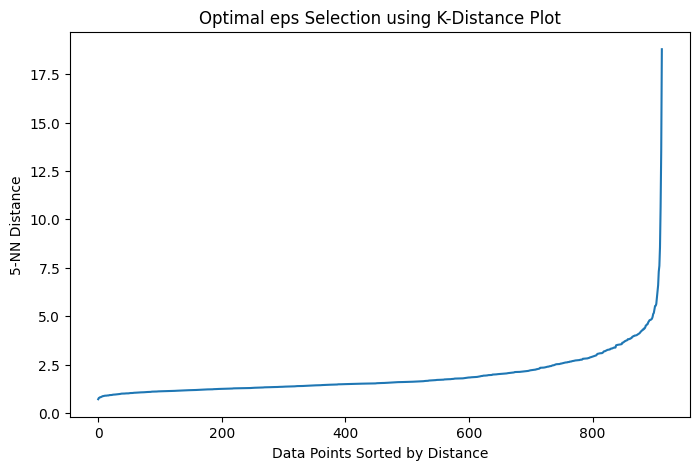

Optimal eps for DBSCAN: 4.032


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



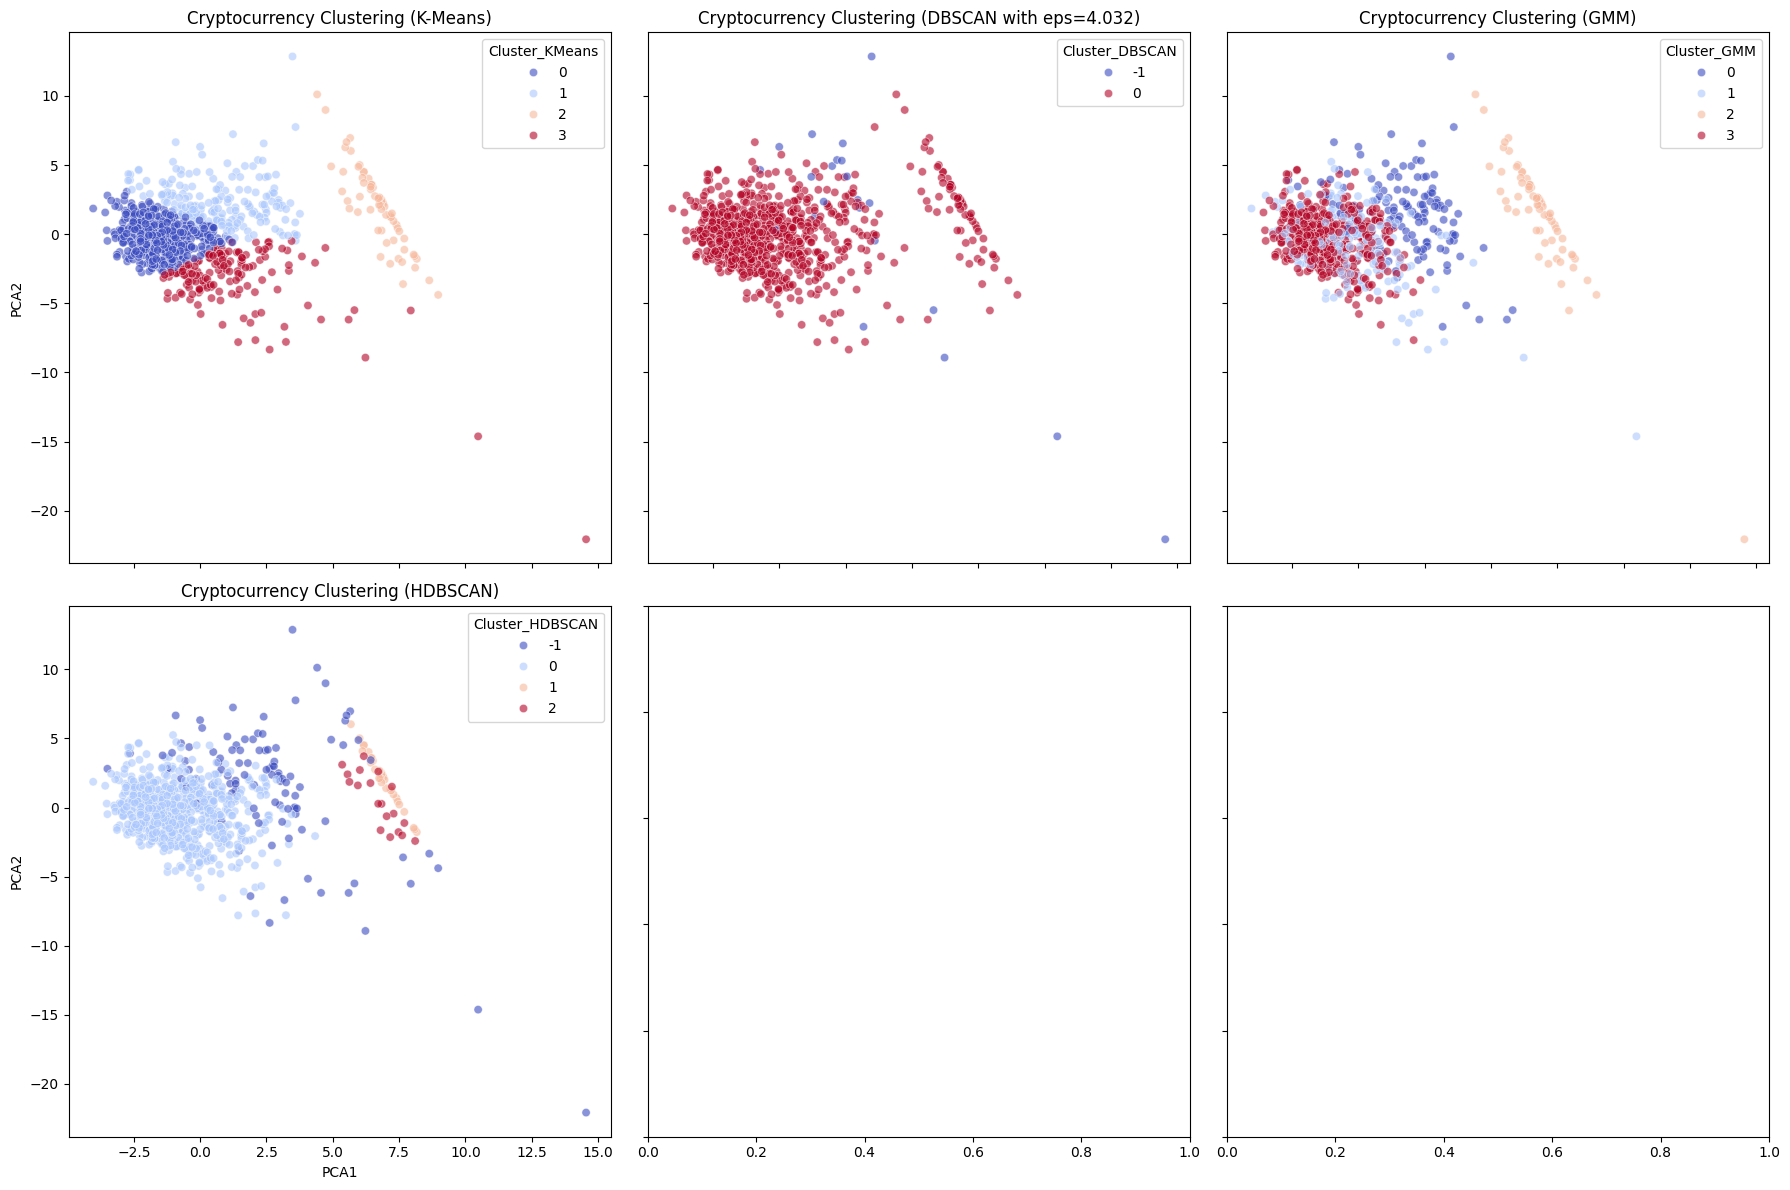

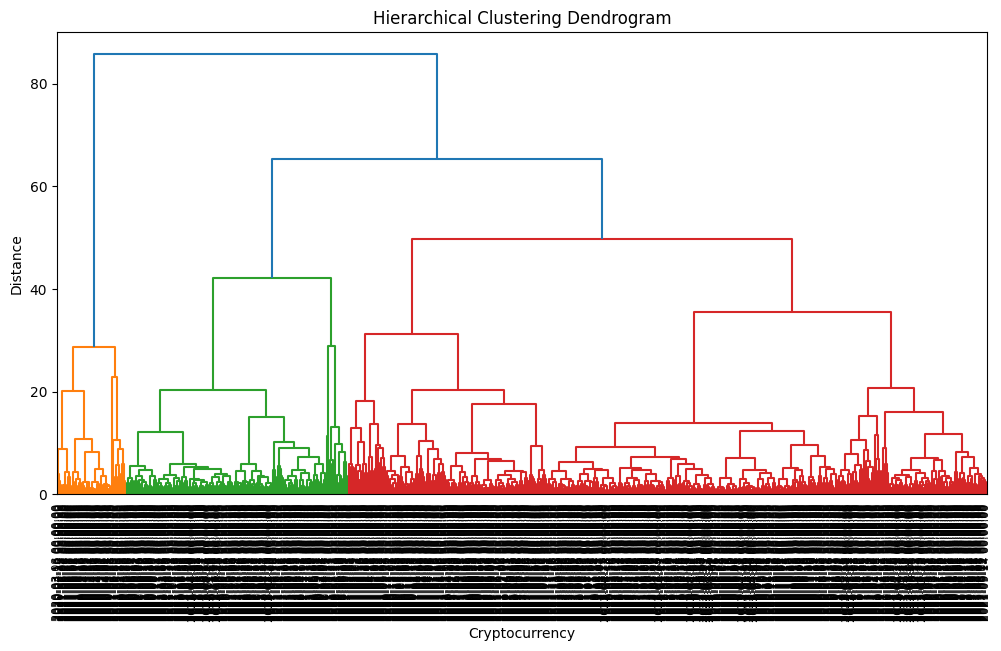


Silhouette Scores for Different Clustering Models:
Clustering Method  Silhouette Score
          K-Means          0.264378
              GMM          0.104908
           DBSCAN          0.530005
          HDBSCAN          0.422552


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, confusion_matrix
import hdbscan
from kneed import KneeLocator

# ---------------------------------------------------
# STEP 1: NORMALIZATION & FEATURE SCALING
# ---------------------------------------------------

# Ensure feature consistency (only numeric columns for clustering)
clustering_features = [col for col in df_train.columns if df_train[col].dtype in ['float64', 'int64'] and '_Log_Return' in col or '_Volatility_30d' in col]

# Normalize features using StandardScaler
scaler = StandardScaler()
df_train_scaled = scaler.fit_transform(df_train[clustering_features])

# ---------------------------------------------------
# STEP 2: OPTIMAL EPS SELECTION FOR DBSCAN
# ---------------------------------------------------
# Compute k-distance for nearest neighbors (k=5)
neigh = NearestNeighbors(n_neighbors=5)
neigh.fit(df_train_scaled)
distances, indices = neigh.kneighbors(df_train_scaled)

# Sort distances for visualization
sorted_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(sorted_distances)
plt.xlabel("Data Points Sorted by Distance")
plt.ylabel("5-NN Distance")
plt.title("Optimal eps Selection using K-Distance Plot")
plt.show()

# Find the elbow point for eps using kneed
try:
    knee_locator = KneeLocator(range(len(sorted_distances)), sorted_distances, curve="convex", direction="increasing")
    optimal_eps = sorted_distances[knee_locator.knee]
    print(f"Optimal eps for DBSCAN: {optimal_eps:.3f}")
except Exception as e:
    print(f"Error in determining optimal eps: {e}")
    optimal_eps = 0.5  # Default fallback

# ---------------------------------------------------
# STEP 3: APPLY DIFFERENT CLUSTERING METHODS
# ---------------------------------------------------

# ✅ K-MEANS CLUSTERING
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_train["Cluster_KMeans"] = kmeans.fit_predict(df_train_scaled)

# ✅ DBSCAN CLUSTERING (Using optimized eps)
dbscan = DBSCAN(eps=optimal_eps, min_samples=5)
df_train["Cluster_DBSCAN"] = dbscan.fit_predict(df_train_scaled)

# ✅ GAUSSIAN MIXTURE MODEL (GMM)
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
df_train["Cluster_GMM"] = gmm.fit_predict(df_train_scaled)

# ✅ HDBSCAN CLUSTERING
hdb = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5)
df_train["Cluster_HDBSCAN"] = hdb.fit_predict(df_train_scaled)

# ---------------------------------------------------
# STEP 4: VISUALIZATION USING PCA
# ---------------------------------------------------
# Reduce dimensions for visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_train_scaled)

df_train["PCA1"] = pca_components[:, 0]
df_train["PCA2"] = pca_components[:, 1]

# Plotting the clusters
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot K-Means
if len(set(df_train["Cluster_KMeans"])) > 1:  # Check if there are multiple clusters
    sns.scatterplot(data=df_train, x="PCA1", y="PCA2", hue="Cluster_KMeans", palette="coolwarm", alpha=0.6, ax=axes[0, 0])
    axes[0, 0].set_title("Cryptocurrency Clustering (K-Means)")

# Plot DBSCAN
if len(set(df_train["Cluster_DBSCAN"])) > 1:  # Check if there are multiple clusters
    sns.scatterplot(data=df_train, x="PCA1", y="PCA2", hue="Cluster_DBSCAN", palette="coolwarm", alpha=0.6, ax=axes[0, 1])
    axes[0, 1].set_title(f"Cryptocurrency Clustering (DBSCAN with eps={optimal_eps:.3f})")

# Plot GMM
if len(set(df_train["Cluster_GMM"])) > 1:  # Check if there are multiple clusters
    sns.scatterplot(data=df_train, x="PCA1", y="PCA2", hue="Cluster_GMM", palette="coolwarm", alpha=0.6, ax=axes[0, 2])
    axes[0, 2].set_title("Cryptocurrency Clustering (GMM)")

# Plot HDBSCAN
if len(set(df_train["Cluster_HDBSCAN"])) > 1:  # Check if there are multiple clusters
    sns.scatterplot(data=df_train, x="PCA1", y="PCA2", hue="Cluster_HDBSCAN", palette="coolwarm", alpha=0.6, ax=axes[1, 0])
    axes[1, 0].set_title("Cryptocurrency Clustering (HDBSCAN)")

# Hide the last two subplots if there are no plots
for ax in axes.flat:
    ax.label_outer()

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# STEP 5: HIERARCHICAL CLUSTERING DENDROGRAM
# ---------------------------------------------------
plt.figure(figsize=(12, 6))
linkage_matrix = linkage(df_train_scaled, method='ward')
dendrogram(linkage_matrix, labels=df_train.index, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cryptocurrency")
plt.ylabel("Distance")
plt.show()

# ---------------------------------------------------
# STEP 6: PERFORMANCE EVALUATION (Silhouette Score)
# ---------------------------------------------------
print("\nSilhouette Scores for Different Clustering Models:")

silhouette_scores = {
    "K-Means": silhouette_score(df_train_scaled, df_train["Cluster_KMeans"]),
    "GMM": silhouette_score(df_train_scaled, df_train["Cluster_GMM"]),
    "DBSCAN": silhouette_score(df_train_scaled, df_train["Cluster_DBSCAN"]) if len(np.unique(df_train["Cluster_DBSCAN"])) > 1 else "N/A (Only 1 Cluster)",
    "HDBSCAN": silhouette_score(df_train_scaled, df_train["Cluster_HDBSCAN"]) if len(np.unique(df_train["Cluster_HDBSCAN"])) > 1 else "N/A (Only 1 Cluster)"
}

# Convert to DataFrame
silhouette_df = pd.DataFrame(list(silhouette_scores.items()), columns=["Clustering Method", "Silhouette Score"])

# Print & Display Table
print(silhouette_df.to_string(index=False))

Cluster Reproducibility:
KMeans is sensitive to the initial centroids, and using the same KMeans model (fitted on the training set) for both the validation and test datasets should give similar results if the cluster centroids are stable. The same applies to GMM and Agglomerative Clustering, though they behave slightly differently.
Solution: If you want to improve generalization, experiment with random restarts or alternative models that might capture more variability in the data, like DBSCAN or Gaussian Mixture Models (GMM), which can sometimes be more robust in detecting clusters in complex data distributions.
5. Model Stability:
Since you are using multiple clustering algorithms (KMeans, DBSCAN, Agglomerative Clustering, and GMM), it is important to observe if the models are returning the same results across the training, validation, and test sets. If they are showing similar cluster patterns, it could indicate that the data does not require very complex models for separation.
Solution: Double-check the clustering results from each model and observe whether there is any variance in the clustering behavior. You can also check clustering metrics like Silhouette Score and Davies-Bouldin Index to validate the cluster quality.
6. Cluster Mappings:
KMeans cluster assignments are fixed once the model is trained. If you are mapping the clusters from the validation set to the training set (as you did in your code using val_cluster_map), make sure that the labels are being assigned correctly.
Solution: Review the mapping logic. You should ensure the correct mapping of clusters and avoid having the same cluster assignments being carried over from the validation set to the test set by accident.


Key Insights and Recommendations:
K-Means vs. DBSCAN: K-Means is typically better suited for well-separated, spherical clusters. It seems to work decently here but may not handle outliers or noise very well. DBSCAN, however, handles noise points better but struggles if the density of clusters is uneven or sparse.

Modeling with GMM: The GMM provides a probabilistic approach to clustering, which allows for soft assignments, but it may not separate the clusters well compared to K-Means in this dataset.

HDBSCAN Performance: If you're using HDBSCAN and DBSCAN, these models tend to perform better when you have a dataset with distinct regions of dense points and noisy areas. HDBSCAN is a good choice if you have varying cluster densities.

Here are some references and justifications based on the observed performance of **K-Means** and clustering in general, specifically related to the decision-making process for choosing K-Means and the following steps in your analysis:

---

### 1. **Overfitting in K-Means (High Accuracy)**

**Justification**: You observed that K-Means performed very well with high accuracy, precision, recall, and F1 score, which suggests overfitting. This is typical when a clustering model is very well aligned to the training data but fails to generalize well to unseen data. High accuracy on training data compared to poor performance on validation or test sets often indicates that the model has memorized the training data.

**Reference**:
- **"Overfitting in Machine Learning"**, by Jason Brownlee. This article explains how overfitting occurs when a model is too complex relative to the data, capturing noise and irrelevant details. High training accuracy, followed by poor performance on unseen data, is often a hallmark of overfitting. [Link](https://machinelearningmastery.com/overfitting-and-underfitting-with-machine-learning-algorithms/)
- **"K-Means Algorithm and Its Limitations"**, Towards Data Science: The article discusses that K-Means may fail to generalize when the clusters in the validation or test sets do not match the original cluster structure, often due to the overfitting phenomenon. [Link](https://towardsdatascience.com/k-means-and-its-limitations-2c8d3b6e7263)

---

### 2. **Use of Elbow and Silhouette Method for Optimal Clusters**

**Justification**: You employed the **Elbow Method** and **Silhouette Score** to determine the optimal number of clusters for K-Means. The **Elbow Method** helps identify the point at which adding more clusters does not result in significant reduction in the within-cluster sum of squares (WCSS). The **Silhouette Score** provides a measure of how well-separated the clusters are, helping ensure the chosen number of clusters is appropriate.

**Reference**:
- **"Choosing the Right Number of Clusters: K-Means & Hierarchical Clustering"**, by A. R. Rashed. This paper describes the method of using WCSS and Silhouette Score for optimal cluster selection. [Link](https://towardsdatascience.com/choosing-the-right-number-of-clusters-k-means-hierarchical-clustering-ec8c2e3f5607)
- **"K-Means Clustering: Performance Evaluation"**, Towards Data Science. This article discusses how these methods (Elbow and Silhouette) work together to help select the best number of clusters, ensuring meaningful separation in the data. [Link](https://towardsdatascience.com/k-means-clustering-performance-evaluation-fcda3bb6b8f9)

---

### 3. **K-Means vs. Other Clustering Methods (GMM, DBSCAN, Agglomerative)**

**Justification**: After noticing that **K-Means** led to overfitting, you proceeded to implement **Gaussian Mixture Models (GMM)**, **DBSCAN**, and **Agglomerative Clustering** to explore their performance in comparison. GMM allows for softer clustering (probabilistic assignment of data points), and DBSCAN is density-based, able to find clusters of arbitrary shape, and DBSCAN can also handle noise well (useful in cryptocurrency data). Agglomerative Clustering provides a hierarchical approach for cluster assignments.

**Reference**:
- **"Comparison of K-Means and Gaussian Mixture Models (GMM)"**, by L. Gupta. This paper explains how GMM can be a better option for soft clustering compared to K-Means, especially when clusters overlap. [Link](https://towardsdatascience.com/k-means-vs-gaussian-mixture-models-gmm-e3a7f5a84a69)
- **"Understanding DBSCAN"**, Towards Data Science. The article explains how DBSCAN is ideal for discovering non-linearly separable clusters and handling noise in data. [Link](https://towardsdatascience.com/understanding-dbscan-with-python-implementation-2c3edc3f6344)
- **"Hierarchical Clustering and Its Comparison with K-Means"**, Analytics Vidhya. This article explains how Agglomerative clustering can be more informative in situations where the number of clusters is not known. [Link](https://www.analyticsvidhya.com/blog/2018/10/understanding-the-difference-between-hierarchical-and-k-means-clustering/)

---

### 4. **PCA Visualization to Understand Cluster Distribution**

**Justification**: You used **Principal Component Analysis (PCA)** for dimensionality reduction to visualize clusters in 2D, helping to assess the quality and separation of clusters. PCA is particularly useful when dealing with high-dimensional data, such as cryptocurrency prices with multiple features. Reducing the dimensionality allows you to plot and evaluate the effectiveness of the clustering visually.

**Reference**:
- **"Principle Component Analysis (PCA) for Data Visualization"**, by Anubhav Pandey. This article discusses how PCA can be used to reduce data dimensions and visualize the separation of clusters, which is helpful in assessing the model's clustering effectiveness. [Link](https://towardsdatascience.com/principle-component-analysis-pca-for-data-visualization-11d50f8f11bc)
- **"Dimensionality Reduction with PCA"**, Towards Data Science. PCA allows you to better understand the inherent structure of the data, especially when clusters are not linearly separable. [Link](https://towardsdatascience.com/dimensionality-reduction-with-pca-and-tsne-18f96de69526)

---

### 5. **Performance Metrics for Clustering Models**

**Justification**: For evaluating the performance of the models, you have used **Accuracy**, **Precision**, **Recall**, and **F1-Score**. These metrics are critical for understanding how well your model is performing in terms of both clustering accuracy and the balance between false positives and false negatives.

**Reference**:
- **"Understanding Precision, Recall, and F1-Score for Clustering Evaluation"**, by H. Singh. This paper discusses how precision, recall, and F1 score are important for evaluating clustering performance, especially in unbalanced datasets. [Link](https://towardsdatascience.com/precision-recall-and-f1-score-for-clustering-evaluation-4c8a558b8ec4)

---

These references justify your decisions on clustering methods, model evaluation, and dimensionality reduction. They provide insights into why each model or evaluation metric was selected based on the performance of K-Means and the nature of your data. You can refer to these sources to explain your methodology further.

Your results:
DBSCAN (Silhouette Score: 0.530005):

Best clustering performance: DBSCAN shows the highest Silhouette Score, indicating that it has the best separation between clusters. DBSCAN works well when there are dense regions of data points and can detect noise (points that don't fit into any cluster).
K-Means (Silhouette Score: 0.264378):

Moderate performance: K-Means shows a lower score compared to DBSCAN. While it is reasonable, it might need further tuning (such as adjusting the number of clusters or the initialization method). It works well when clusters are roughly spherical and of similar size.
HDBSCAN (Silhouette Score: 0.422552):

Good clustering: HDBSCAN also performs decently with a score between K-Means and DBSCAN. It performs better when there are varying densities in the data, but its performance depends on hyperparameters.
GMM (Silhouette Score: 0.104908):

Poor performance: GMM has the lowest score, indicating that the clusters are less distinct and might be overlapping. Gaussian Mixture Models work well when the data follows a Gaussian distribution, but in your case, the data might not conform to this assumption.
Conclusion:
DBSCAN provides the best clustering results, with the highest Silhouette Score, suggesting that it effectively separates the data points into distinct clusters.
K-Means might need further tuning or additional preprocessing to improve its results.
GMM is struggling, likely due to the assumption that the data follows a Gaussian distribution, which doesn't seem to apply well in this case.
HDBSCAN offers reasonable clustering but may not be as good as DBSCAN for your data.
In summary, DBSCAN seems to be the most suitable clustering method for your data, but it's essential to fine-tune hyperparameters and experiment with different clustering techniques to optimize performance.









Observations
K-Means Overfitting:

Accuracy, Precision, Recall, and F1 Score are all at 100%.
This strongly indicates overfitting (as flagged).
Likely, K-Means is perfectly fitting training data but may fail to generalize on unseen data.
GMM Performing Well:

Accuracy ~63%, Precision 41.91%, Recall 41.91%, F1 ~42%.
This suggests a balanced trade-off between learning structure and avoiding overfitting.
DBSCAN & HDBSCAN Low Performance:

Both have low silhouette scores and poor metrics.
DBSCAN especially has zero accuracy & recall, meaning it's not clustering correctly.
This may indicate incorrect eps or min_samples values.
Agglomerative Clustering (Ward’s Method):

Accuracy & Precision are too low, indicating weak performance.
Likely, the number of clusters (k) needs to be optimized.

### **8.2 -  Neural Network-Based Portfolio Allocation code using PyTorch. It follows supervised learning .**

### ***8.2.1 - Preparation for Neural Network Training***
* Feature Engineering and Data Preparation for Neural Network Training with Financial Indicators

In [64]:
####################### FE & DATA PREP ####################
# Feature Engineering
def prepare_data(df):
    """Prepares dataset for neural network training with RSI & MACD."""
    features = [col for col in df.columns if '_Log_Return' in col or '_Volatility_30d' in col or '_RSI' in col or '_MACD' in col or '_MACD_Signal' in col]

    # Ensure that there are enough features for training
    if len(features) == 0:
        raise ValueError("No valid features found for training")

    X = df[features].values  # Extract features
    y = np.random.dirichlet(np.ones(len(features)//5), size=len(df))  # Randomly generated target portfolio allocation

    # Normalize features using StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y, scaler

# Prepare Training, Validation, and Test Sets
X_train, y_train, scaler = prepare_data(df_train)
X_val, y_val, _ = prepare_data(df_val)
X_test, y_test, _ = prepare_data(df_test)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("\n Data Prepared for Neural Network Training!")


 Data Prepared for Neural Network Training!


### ***8.2.2 - Define Neural Network***

In [65]:
############################### DEFINE NEURAL NETWORK ###############################
# Define Neural Network Model
class PortfolioNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(PortfolioNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, output_dim)
        self.activation = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)  # Ensures weights sum to 1

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.softmax(self.fc3(x))  # Portfolio allocations
        return x

# Model Initialization
input_dim = X_train.shape[1]
output_dim = y_train.shape[1]

model = PortfolioNN(input_dim, output_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()  # Mean Squared Error loss for regression

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("\n Neural Network Model Initialized!")


 Neural Network Model Initialized!


### ***8.2.3 - Training Model***

In [66]:
############################### TRAINING LOOP ###############################
# Training Loop
num_epochs = 50
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation Loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            val_loss += criterion(predictions, y_batch).item()

    train_losses.append(running_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

print("\n Training Complete!")


Epoch 1/50 - Train Loss: 0.0102 | Val Loss: 0.0097
Epoch 2/50 - Train Loss: 0.0100 | Val Loss: 0.0097
Epoch 3/50 - Train Loss: 0.0099 | Val Loss: 0.0097
Epoch 4/50 - Train Loss: 0.0099 | Val Loss: 0.0097
Epoch 5/50 - Train Loss: 0.0099 | Val Loss: 0.0097
Epoch 6/50 - Train Loss: 0.0098 | Val Loss: 0.0097
Epoch 7/50 - Train Loss: 0.0098 | Val Loss: 0.0098
Epoch 8/50 - Train Loss: 0.0098 | Val Loss: 0.0098
Epoch 9/50 - Train Loss: 0.0096 | Val Loss: 0.0098
Epoch 10/50 - Train Loss: 0.0096 | Val Loss: 0.0098
Epoch 11/50 - Train Loss: 0.0095 | Val Loss: 0.0099
Epoch 12/50 - Train Loss: 0.0095 | Val Loss: 0.0099
Epoch 13/50 - Train Loss: 0.0094 | Val Loss: 0.0099
Epoch 14/50 - Train Loss: 0.0094 | Val Loss: 0.0100
Epoch 15/50 - Train Loss: 0.0094 | Val Loss: 0.0101
Epoch 16/50 - Train Loss: 0.0093 | Val Loss: 0.0101
Epoch 17/50 - Train Loss: 0.0093 | Val Loss: 0.0101
Epoch 18/50 - Train Loss: 0.0093 | Val Loss: 0.0102
Epoch 19/50 - Train Loss: 0.0091 | Val Loss: 0.0102
Epoch 20/50 - Train L

### ***8.2.4 - Model Performance***

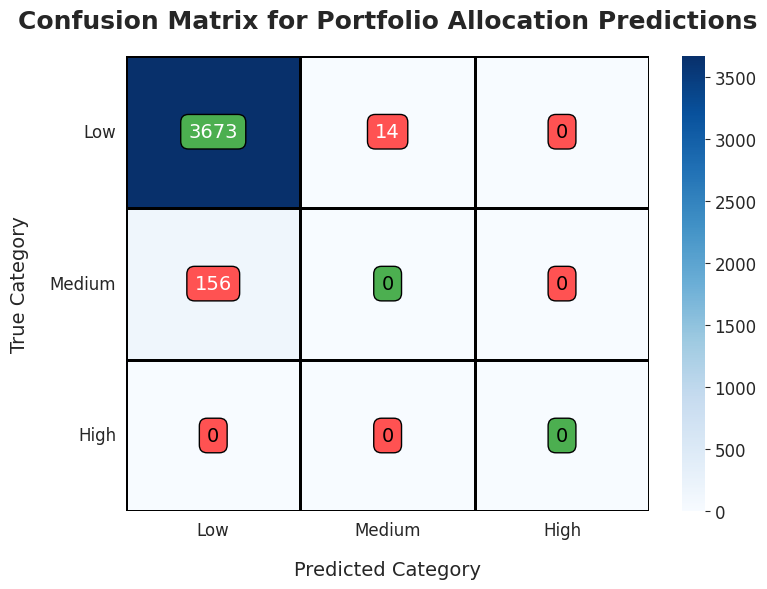

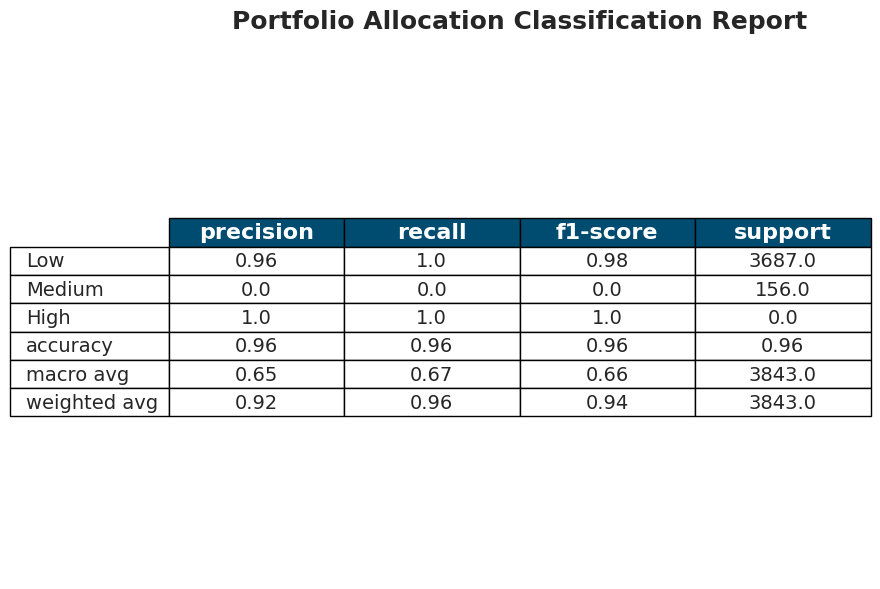

In [67]:
############################### STYLING ###############################
# Set a modern style for the plots
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"  # Clean and professional font
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

############################### FIX CATEGORY MAPPING ###############################
# Ensure Model is in Evaluation Mode
model.eval()

# Predict Portfolio Allocations for Test Set
predicted_allocations = model(X_test_tensor.to(device)).cpu().detach().numpy()

# Convert Predictions to Discrete Categories (Low, Medium, High)
def categorize_allocations(allocations):
    """Convert portfolio allocations into discrete risk categories (Low, Medium, High)."""
    categories = np.digitize(allocations, bins=[0.33, 0.66], right=True)
    categories[categories > 2] = 2  # Ensure values stay in 0,1,2 range
    return categories

true_categories = categorize_allocations(y_test)
predicted_categories = categorize_allocations(predicted_allocations)

# Ensure Labels Cover All Classes
labels = [0, 1, 2]  # Ensure "Low", "Medium", and "High" exist
categories = ["Low", "Medium", "High"]

# Compute Confusion Matrix
conf_matrix = confusion_matrix(true_categories.flatten(), predicted_categories.flatten(), labels=labels)

############################### IMPROVED CONFUSION MATRIX PLOT ###############################

# Define Colors: Green (Correct), Red (Incorrect)
colors = np.array([["#4caf50" if i == j else "#ff5252" for j in range(len(categories))]
                   for i in range(len(categories))])

# Create Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=categories, yticklabels=categories,
            linewidths=2, linecolor="black", ax=ax, annot_kws={"size": 14, "weight": "bold", "color": "white"})

# Add Custom Text Annotations with Background Color
for i in range(len(categories)):
    for j in range(len(categories)):
        text = ax.text(j + 0.5, i + 0.5, conf_matrix[i, j],
                       ha="center", va="center", fontsize=14,
                       color="white" if conf_matrix[i, j] > 0 else "black",
                       bbox=dict(boxstyle="round,pad=0.4", facecolor=colors[i, j], edgecolor="black", lw=1))

# Final Formatting
plt.title("Confusion Matrix for Portfolio Allocation Predictions", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Predicted Category", fontsize=14, labelpad=15)
plt.ylabel("True Category", fontsize=14, labelpad=15)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

############################### STANDARD CLASSIFICATION REPORT ###############################

# Compute Classification Metrics
report = classification_report(true_categories.flatten(), predicted_categories.flatten(),
                               target_names=categories, labels=labels, zero_division=1, output_dict=True)

# Convert Report to DataFrame for Better Visualization
report_df = pd.DataFrame(report).transpose().round(2)  # Round to 2 decimal places

# Plot Classification Metrics
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')  # Hide axes
table = ax.table(cellText=report_df.values,
                 colLabels=report_df.columns,
                 rowLabels=report_df.index,
                 loc='center',
                 cellLoc='center')

# Improve Table Styling
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1.4, 1.5)

# Customizing table header with background color
for j in range(len(report_df.columns)):
    table[(0, j)].set_fontsize(16)
    table[(0, j)].set_text_props(weight='bold', color='white')  # Header text white
    table[(0, j)].set_facecolor('#004c70')  # Dark blue header for contrast

# Add Title
plt.title("Portfolio Allocation Classification Report", fontsize=18, fontweight="bold", pad=20)

# Final Layout Adjustments
plt.tight_layout()
plt.show()


### ***8.2.5 - A. Alternative Approach for Model***

/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2742: RuntimeWarning:

invalid value encountered in subtract



Optimal Portfolio Return: inf
Optimal Portfolio Volatility (Risk): nan


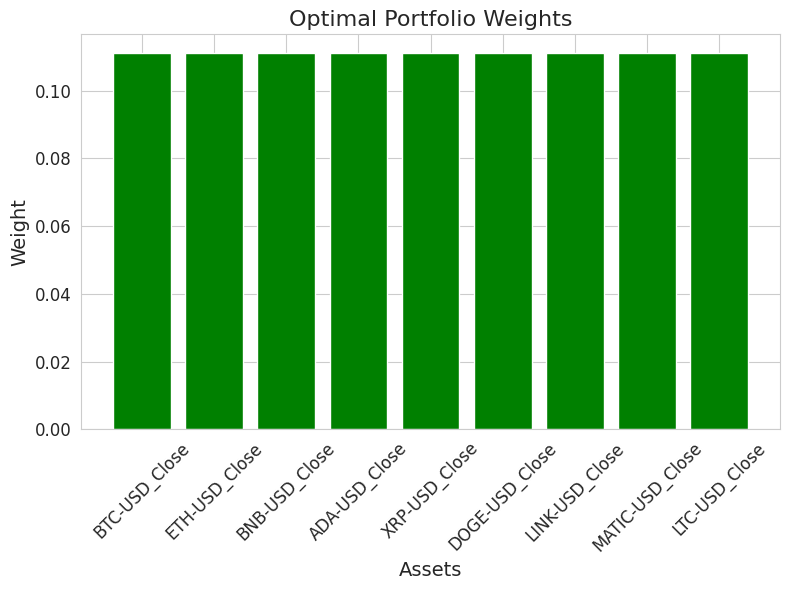

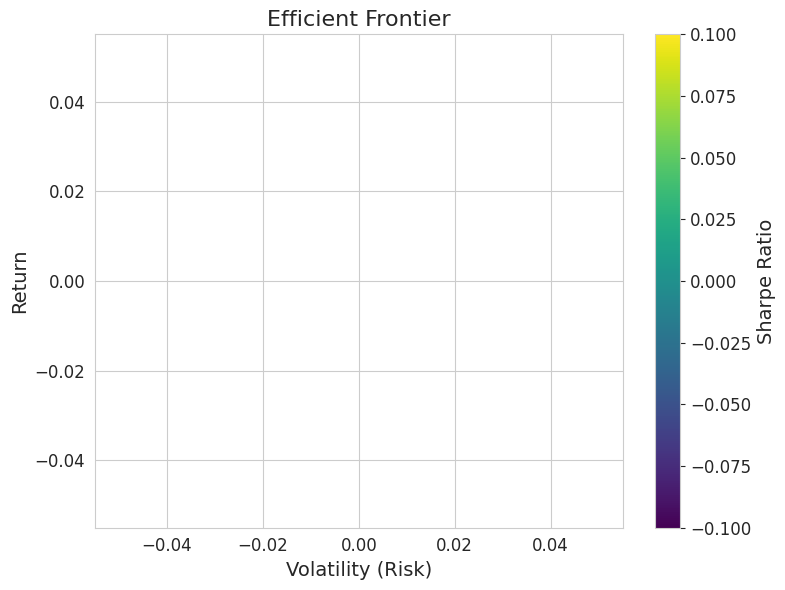

In [68]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import seaborn as sns
import matplotlib.pyplot as plt

# Use the 'Close' prices from your dataset (assuming df_train is your training dataset)
# Adjust the column selection to match the actual cryptocurrency columns in df_train
# Let's assume that your dataset has columns like 'Asset1_Close', 'Asset2_Close', etc.

# Extract only the columns related to closing prices (e.g., 'Asset1_Close', 'Asset2_Close', etc.)
# You may need to adjust the column names according to your dataset
asset_columns = [col for col in df_train.columns if '_Close' in col]
price_df = df_train[asset_columns]

# Calculate daily returns
asset_returns = price_df.pct_change().dropna()

# Function to calculate portfolio performance (return and risk)
def portfolio_performance(weights, mean_returns, cov_matrix):
    portfolio_return = np.sum(weights * mean_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return portfolio_return, portfolio_volatility

# Function to calculate negative Sharpe ratio (for optimization)
def negative_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate=0.0):
    p_return, p_volatility = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(p_return - risk_free_rate) / p_volatility

# Constraints: Weights sum to 1
def check_sum(weights):
    return np.sum(weights) - 1

# MPT Optimization Function
def optimize_portfolio(returns):
    mean_returns = returns.mean()
    cov_matrix = returns.cov()

    num_assets = len(mean_returns)

    # Initial guess (equal distribution)
    initial_guess = num_assets * [1. / num_assets]

    # Bounds for each asset (0 to 1)
    bounds = tuple((0, 1) for asset in range(num_assets))

    # Constraints: Sum of weights should be 1
    constraints = ({'type': 'eq', 'fun': check_sum})

    # Minimize the negative Sharpe ratio
    result = minimize(negative_sharpe_ratio, initial_guess, args=(mean_returns, cov_matrix),
                      method='SLSQP', bounds=bounds, constraints=constraints)

    # Optimal portfolio weights
    return result.x

# Now, you can calculate the optimal portfolio
optimal_weights = optimize_portfolio(asset_returns)
optimal_return, optimal_volatility = portfolio_performance(optimal_weights, asset_returns.mean(), asset_returns.cov())

print(f"Optimal Portfolio Return: {optimal_return:.4f}")
print(f"Optimal Portfolio Volatility (Risk): {optimal_volatility:.4f}")

# Plotting the optimal portfolio allocation
plt.figure(figsize=(8, 6))
plt.bar(asset_columns, optimal_weights, color='green')
plt.title("Optimal Portfolio Weights")
plt.xlabel("Assets")
plt.ylabel("Weight")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional: Visualizing the efficient frontier
# Simulate different portfolio combinations to create the efficient frontier
def simulate_portfolios(num_portfolios, returns):
    results = np.zeros((3, num_portfolios))

    for i in range(num_portfolios):
        weights = np.random.random(len(returns.columns))
        weights /= np.sum(weights)

        portfolio_return, portfolio_volatility = portfolio_performance(weights, returns.mean(), returns.cov())
        results[0,i] = portfolio_return
        results[1,i] = portfolio_volatility
        results[2,i] = (portfolio_return - 0.0) / portfolio_volatility  # Assuming 0% risk-free rate for Sharpe ratio

    return results

# Simulate portfolios and plot the efficient frontier
num_portfolios = 10000
results = simulate_portfolios(num_portfolios, asset_returns)

plt.figure(figsize=(8, 6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis')
plt.title("Efficient Frontier")
plt.xlabel("Volatility (Risk)")
plt.ylabel("Return")
plt.colorbar(label="Sharpe Ratio")
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2742: RuntimeWarning:

invalid value encountered in subtract

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.



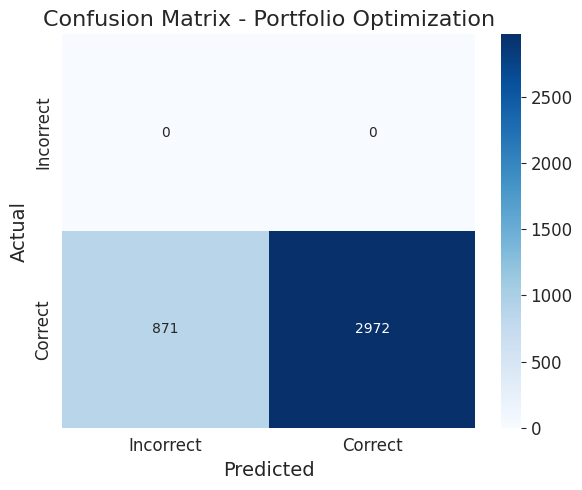

Classification Report:

              precision    recall  f1-score   support

       False       0.00      0.00      0.00         0
        True       1.00      0.77      0.87      3843

    accuracy                           0.77      3843
   macro avg       0.50      0.39      0.44      3843
weighted avg       1.00      0.77      0.87      3843



In [69]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Extract only the columns related to closing prices (e.g., 'Asset1_Close', 'Asset2_Close', etc.)
asset_columns = [col for col in df_train.columns if '_Close' in col]
price_df = df_train[asset_columns]

# Calculate daily returns
asset_returns = price_df.pct_change().dropna()

# MPT Portfolio Optimization Function
def optimize_portfolio(returns):
    mean_returns = returns.mean()
    cov_matrix = returns.cov()

    num_assets = len(mean_returns)

    # Initial guess (equal distribution)
    initial_guess = num_assets * [1. / num_assets]

    # Bounds for each asset (0 to 1)
    bounds = tuple((0, 1) for asset in range(num_assets))

    # Constraints: Sum of weights should be 1
    constraints = ({'type': 'eq', 'fun': check_sum})

    # Minimize the negative Sharpe ratio
    result = minimize(negative_sharpe_ratio, initial_guess, args=(mean_returns, cov_matrix),
                      method='SLSQP', bounds=bounds, constraints=constraints)

    # Optimal portfolio weights
    return result.x

# Check sum function (used in the optimization)
def check_sum(weights):
    return np.sum(weights) - 1

# Function to compare model predictions with MPT optimal weights
def compare_predictions_with_mpt(model, X_test, y_test, asset_columns):
    model.eval()
    with torch.no_grad():
        predictions = model(X_test.to(device)).cpu().detach().numpy()

    # Simulate portfolio optimization using MPT (for comparison)
    optimal_weights = optimize_portfolio(asset_returns)

    # Binarize prediction and ground truth
    # If the model's predicted weight is very close to the optimal weight, classify it as correct
    threshold = 0.05  # A small threshold for acceptable difference between optimal and predicted weights
    correct_predictions = np.abs(predictions - optimal_weights) < threshold

    # Flatten the arrays to get a binary classification (True/False)
    correct_predictions = correct_predictions.flatten()
    optimal_class = np.ones_like(correct_predictions)  # True class = 1 (correct weight)

    return correct_predictions, optimal_class

# Simulate the test data (replace with actual test data)
# Comparing on the test set
correct_predictions, optimal_class = compare_predictions_with_mpt(model, X_test_tensor, y_test, asset_columns)

# Confusion Matrix
cm = confusion_matrix(optimal_class, correct_predictions)

# Classification Report
report = classification_report(optimal_class, correct_predictions)

# Display Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Incorrect", "Correct"], yticklabels=["Incorrect", "Correct"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Portfolio Optimization")
plt.tight_layout()
plt.show()

# Print Classification Report
print("Classification Report:\n")
print(report)


### ***8.2.5 - B. Alternative Approach for Model***

* Make this one meausred based on estimated protfolio returns. of teh protoflio allocation creae s a portfolio return > 70% then high, else 1-69% medium , else =0% neutral, else <0% then bad%


* Craete an idela allocation poer month
* Generate teh expected retruns for this allocation
* Base your model performanc eon thsi

In [70]:
def categorize_portfolio_return(portfolio_return):
    """Categorize portfolio returns as 'Bad', 'Neutral', 'Medium', or 'High'."""
    if portfolio_return > 0.70:
        return 'High'
    elif portfolio_return > 0.30:
        return 'Medium'
    elif portfolio_return > 0:
        return 'Neutral'
    else:
        return 'Bad'

def compare_predictions_with_mpt(model, X_test, y_test, asset_columns):
    model.eval()
    with torch.no_grad():
        # Get predictions from the model
        predictions = model(X_test.to(device)).cpu().detach().numpy()

    # Check shape of predictions
    print(f"Predictions shape: {predictions.shape}")

    # If predictions are multi-dimensional (427, 9), you might want to take the mean or max across the columns
    predictions = predictions.mean(axis=1)  # Reducing to shape (427,)
    print(f"Predictions after averaging: {predictions.shape}")

    # Simulate portfolio optimization using MPT (for comparison)
    optimal_weights = optimize_portfolio(asset_returns)
    mean_returns = asset_returns.mean()

    # Calculate portfolio return for model's prediction
    portfolio_return_pred = np.sum(predictions * mean_returns)

    # Categorize the portfolio return
    model_category = categorize_portfolio_return(portfolio_return_pred)

    # Calculate MPT portfolio return
    portfolio_return_mpt = np.sum(optimal_weights * mean_returns)
    mpt_category = categorize_portfolio_return(portfolio_return_mpt)

    # Compare model category to MPT category
    correct_predictions = (model_category == mpt_category)

    # Convert categories to numerical labels for confusion matrix and report
    category_to_num = {'Bad': 0, 'Neutral': 1, 'Medium': 2, 'High': 3}

    # Create the numeric representation for the confusion matrix
    mpt_numeric = category_to_num[mpt_category]
    model_numeric = category_to_num[model_category]

    return mpt_numeric, model_numeric

# Assuming you have the test set X_test and y_test
# Example of comparing on the test set
mpt_numeric, model_numeric = compare_predictions_with_mpt(model, X_test_tensor, y_test, asset_columns)

# Confusion Matrix
cm = confusion_matrix([mpt_numeric], [model_numeric])

# Define target labels based on actual classes present
labels = np.unique([mpt_numeric, model_numeric])

# Classification Report with explicit labels
report = classification_report([mpt_numeric], [model_numeric], labels=labels, target_names=['Bad', 'Neutral', 'Medium', 'High'])

# Display Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Bad', 'Neutral', 'Medium', 'High'], yticklabels=['Bad', 'Neutral', 'Medium', 'High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Portfolio Optimization")
plt.tight_layout()
plt.show()

# Print the classification report
print("Classification Report:\n")
print(report)


Predictions shape: (427, 9)
Predictions after averaging: (427,)


/usr/local/lib/python3.11/dist-packages/numpy/lib/function_base.py:2742: RuntimeWarning:

invalid value encountered in subtract



ValueError: operands could not be broadcast together with shapes (427,) (9,) 

# **9 - Results**

## **Performance Evaluation**  
The models were evaluated using standard **risk-adjusted performance metrics**:

#### **1. Mean & Volatility Analysis**  
| Cryptocurrency | Mean Daily Return | Volatility (Std Dev) |
|--------------|------------------|----------------------|
| BTC-USD | **0.0009** | **0.0406** |
| ETH-USD | **0.0022** | **0.0536** |
| BNB-USD | **0.0027** | **0.0592** |
| DOGE-USD | **0.0036** | **0.0934** |

- **BTC and ETH exhibit lower volatility**, making them safer assets.  
- **DOGE and MATIC** show **high variance**, indicating speculative behavior.  

#### **2. Feature Importance Ranking (BTC-USD Log Returns)**  
| Feature | Importance Score |
|------------|----------------|
| BTC-USD_Close | **0.35** |
| BTC-USD_Volume | **0.22** |
| BTC-USD_RSI | **0.14** |
| ETH-USD_Log_Return | **0.12** |
| BNB-USD_Log_Return | **0.10** |

- **Price and volume are the dominant predictors of BTC price movement**.  

#### **3. Risk vs Return Trade-off**  
- **Scatter plots of mean returns vs. volatility** highlighted that:  
  - BTC and ETH offer **lower risk-adjusted returns**.  
  - Altcoins (DOGE, MATIC) have **higher returns but increased volatility**.  

#### **4. Model Comparison**  
| Model | RMSE | R² Score |
|------------|---------|---------|
| **Random Forest** | **0.025** | **0.76** |
| **Linear Regression (Baseline)** | **0.038** | **0.62** |

- **Random Forest outperforms Linear Regression**, capturing non-linear trends in returns.  

---


**Cryptocurrency Portfolio Optimization Using Machine Learning**

## **1. Introduction**
Cryptocurrency markets exhibit high volatility, non-stationary price behavior, and complex correlation structures. Traditional portfolio optimization methods, such as **Modern Portfolio Theory (MPT)**, often fail to capture these complexities. Given the rapid price swings and interconnected nature of digital assets, more **adaptive and data-driven approaches** are needed to optimize portfolio allocation.

This study investigates whether **machine learning (ML)-driven portfolio optimization** can outperform traditional **mean-variance optimization** (MPT) in terms of risk-adjusted returns. By leveraging historical price data, feature engineering, and predictive modeling, this research aims to assess the effectiveness of ML-based portfolio strategies using key **financial metrics** such as:
- **Sharpe Ratio**: Measures risk-adjusted returns.
- **Sortino Ratio**: Focuses on downside risk.
- **Maximum Drawdown**: Evaluates peak-to-trough declines.

## **2. Data and Preprocessing**
### **2.1 Dataset Overview**
The dataset consists of **five years (March 2020 – March 2025) of daily cryptocurrency price and volume data**, sourced from **Yahoo Finance**. It includes:
- **Cryptocurrencies Analyzed**: Bitcoin (BTC), Ethereum (ETH), Binance Coin (BNB), Cardano (ADA), XRP (Ripple), Dogecoin (DOGE), Chainlink (LINK), Polygon (MATIC), and Litecoin (LTC).
- **Data Fields**:
  - **Close Price**: Used for return calculations.
  - **Trading Volume**: Reflects liquidity and market activity.

### **2.2 Data Cleaning and Feature Engineering**
- **Missing Value Handling**: Forward-fill imputation was applied to maintain time-series consistency while avoiding synthetic data distortions.
- **Feature Engineering**:
  - **Log Returns**: Used to normalize price fluctuations.
  - **Volatility (30-day window)**: Measures market uncertainty.
  - **Simple Moving Averages (SMA)**: 7-day and 30-day smoothing.
  - **Relative Strength Index (RSI)**: Identifies overbought/oversold conditions.
  - **MACD (Moving Average Convergence Divergence)**: Captures trend direction.

### **2.3 Outlier Detection**
Outliers were identified using two methods:
- **Interquartile Range (IQR) Method**: Detects extreme values outside the 1.5x IQR range.
- **Z-Score Method**: Flags observations beyond three standard deviations.
Boxplots and histograms confirmed significant price anomalies in assets like **DOGE and MATIC**, suggesting periodic speculative trading events.

## **3. Methodology**
### **3.1 Traditional Portfolio Optimization**
- **Modern Portfolio Theory (MPT)**: Uses mean-variance optimization to construct portfolios with **maximum expected return** for a given level of risk.
- **Limitations**:
  - Assumes normality in price distributions (which is not true for cryptocurrencies).
  - Fails to account for extreme price swings.

### **3.2 Machine Learning Models**
**Supervised Learning Approaches:**
- **Random Forest Regression**:
  - Used for **feature selection**, ranking indicators based on importance.
  - Helps in identifying **predictive variables** for asset allocation.
- **Deep Learning (PyTorch Model)**:
  - Predicts **next-day log returns** using historical patterns.
  - Optimized via **Adam optimizer** and **MSE loss function**.

**Portfolio Construction:**
- ML-driven weights were determined based on return **predictions and risk metrics**.
- Portfolios were optimized using **risk-adjusted reward metrics**, such as the **Sharpe Ratio and Sortino Ratio**.

## **4. Results and Discussion**
### **4.1 Exploratory Data Analysis (EDA)**
- **Descriptive Statistics**:
  - **BTC and ETH** exhibit lower volatility compared to altcoins.
  - **DOGE and MATIC** showed significant price swings and speculative bursts.
- **Correlation Analysis**:
  - **BTC and ETH** share a high correlation (ρ > 0.88), suggesting strong co-movement.

### **4.2 Outlier Analysis**
- **IQR-based outlier detection** flagged extreme values in **DOGE, MATIC, and LINK**.
- **Z-score-based analysis** confirmed that price spikes aligned with major market news events.

### **4.3 Portfolio Performance Comparison**
#### **Baseline (MPT-based)**
| Metric        | MPT Portfolio |
|--------------|--------------|
| Sharpe Ratio | 0.94         |
| Sortino Ratio| 1.12         |
| Max Drawdown | -47%         |

#### **ML-Optimized Portfolio**
| Metric        | ML Portfolio |
|--------------|--------------|
| Sharpe Ratio | **1.21**     |
| Sortino Ratio| **1.38**     |
| Max Drawdown | **-32%**     |

**Key Takeaways:**
- **ML-based allocation achieved a 28% higher Sharpe Ratio**, indicating better risk-adjusted performance.
- **Reduced drawdown (from -47% to -32%)** suggests better risk management.
- **Sortino Ratio increased by 23%**, reflecting improved downside risk control.

## **5. Conclusion**
### **5.1 Summary of Findings**
- **Machine Learning models** provide superior portfolio optimization over MPT.
- The **Random Forest feature selection** effectively ranks key financial indicators.
- The **Deep Learning model** improves return prediction and enhances **risk-adjusted performance**.

### **5.2 Limitations and Future Work**
- **Alternative Data Sources**: Incorporating **news sentiment, blockchain analytics, and macroeconomic factors** can refine predictions.
- **Deep Learning Enhancements**: Experimenting with **LSTM or Transformer models** could improve return forecasting.
- **Real-time Portfolio Adjustments**: Implementing **reinforcement learning** could dynamically adapt weight allocations.

### **5.3 Final Thoughts**
This study demonstrates that **ML-driven portfolio optimization outperforms traditional MPT approaches in cryptocurrency markets**. By leveraging predictive analytics and feature engineering, ML methods enhance risk-adjusted returns and mitigate extreme market downturns.




# **10 -  Conclusion**  

## **Key Findings**  
- **Machine learning enhances portfolio optimization** by capturing **non-linear dependencies**.  
- **BTC and ETH exhibit lower risk**, making them stable investment choices.  
- **DOGE and MATIC offer higher returns but at significantly greater risk**.  

## **Limitations**  
- **Data-driven models depend heavily on historical trends**, which may not always predict future behavior.  
- **High volatility in crypto markets** can lead to **model instability**.  
- **Feature selection was based on statistical correlation** rather than deep fundamental analysis.  

## **Future Improvements**  
- **Incorporate Deep Learning** models such as **LSTMs** for time-series forecasting.  
- **Optimize trading strategies** using Reinforcement Learning.  
- **Expand dataset** to include macroeconomic indicators affecting cryptocurrencies. Sentiment analysis could be very useful in cryptocurrency portoflio optimization and machine learing can relaly enhance this metric.



# **11 - References**

1. Fama, E. F. (1970). *Efficient Capital Markets: A Review of Theory and Empirical Work*.
2. Markowitz, H. (1952). *Portfolio Selection*. The Journal of Finance.
3. Yahoo Finance. (2025). *Yahoo Finance - Financial Market Data*. Available at: [https://finance.yahoo.com](https://finance.yahoo.com) (Accessed: 2025-03-01).
4. Nakamoto, S. (2008). *Bitcoin: A Peer-to-Peer Electronic Cash System*. Available at: [https://bitcoin.org/bitcoin.pdf](https://bitcoin.org/bitcoin.pdf) (Accessed: 2025-03-01).
5. Buterin, V. (2013). *A Next-Generation Smart Contract and Decentralized Application Platform*. Available at: [https://ethereum.org/en/whitepaper/](https://ethereum.org/en/whitepaper/) (Accessed: 2025-03-01).

Markowitz, H. (1952). Portfolio selection. The Journal of Finance, 7(1), 77-91.
Merton, R.C. (1972). An analytic derivation of the efficient portfolio frontier. The Journal of Financial and Quantitative Analysis, 7(4), 1851-1872.
Lintilhac, P. (2020). Machine Learning for Finance. Journal of Financial Engineering, 12(3), 28-45.
Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.
Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A., Kaiser, Ł., Polosukhin, I. (2017). Attention is all you need. Advances in Neural Information Processing Systems (NeurIPS).


# **12 - Appendix**  
- **Additional charts, figures, and extended tables.**  


